# Titanic Survival Prediction

## End-to-End Machine Learning Classification Project

### Objective

Build a machine learning model to predict whether a passenger
aboard the Titanic survived based on demographic, socioeconomic,
and family-related information.

### Problem Type
Supervised Learning → Binary Classification

### Target Variable
`Survived`

- `0` → Did not survive
- `1` → Survived

# Project Overview

This project follows an end-to-end machine learning workflow,
including:

- Problem understanding
- Data understanding
- Data quality assessment
- Exploratory data analysis
- Feature engineering
- Data preprocessing
- Model training
- Model evaluation
- Model comparison
- Prediction
- Error analysis
- Model interpretation

# Imprt Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay, # Use ConfusionMatrixDisplay instead
    RocCurveDisplay # Use RocCurveDisplay instead
)


import warnings
warnings.filterwarnings("ignore")

# Loead Dataset

In [ ]:
dataframe = pd.read_csv("train.csv")
dataframe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
dataframe.shape

(891, 12)

# 1. Problem Understanding

## Problem Statement

The objective of this project is to predict whether a Titanic
passenger survived based on the information available about
that passenger.

The target variable is `Survived`, which contains two classes:

- 0 → Did not survive
- 1 → Survived

Therefore, this is a supervised binary classification problem.

# 2. Dataset Understanding

In [ ]:
dataframe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
dataframe.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
dataframe.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data DIctionary

PassengerId	Unique passenger identifier

Survived	Survival status — target

Pclass	Passenger class

Name	Passenger name

Sex	Passenger sex

Age	Passenger age

SibSp	Number of siblings/spouses aboard

Parch	Number of parents/children aboard

Ticket	Ticket number

Fare	Passenger fare

Cabin	Cabin number

Embarked	Port of embarkation

# 3. Data Quality Assessment

In [ ]:
dataframe.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age       → 177 missing

Cabin     → 687 missing

Embarked  → 2 missing

### Missing Value Findings

The dataset contains missing values in three features:

- `Age`: 177 missing values
- `Cabin`: 687 missing values
- `Embarked`: 2 missing values

`Cabin` has the largest amount of missing data, with approximately
77% of its values missing. Therefore, rather than immediately
dropping the feature, further investigation and feature engineering
will be performed.

## Duplicate Analysis

In [ ]:
dataframe.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset.

## Cardinality Analysis

In [ ]:
dataframe.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
dataframe.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Name has very high cardinality because most passenger names are unique. ( imp for feature engineering)

## Numerical Summary

In [ ]:
dataframe.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
dataframe['Age'].min(), dataframe['Age'].max()

(0.42, 80.0)

The range of age is 0.42 - 80 years

In [ ]:
dataframe['Fare'].min(), dataframe['Fare'].max()

(0.0, 512.3292)

The fare is between 0 - 512.33

# 4. Exploratory Data Analysis

## Target Variable Analysis

In [ ]:
# Survival Distribution

dataframe['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
dataframe['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


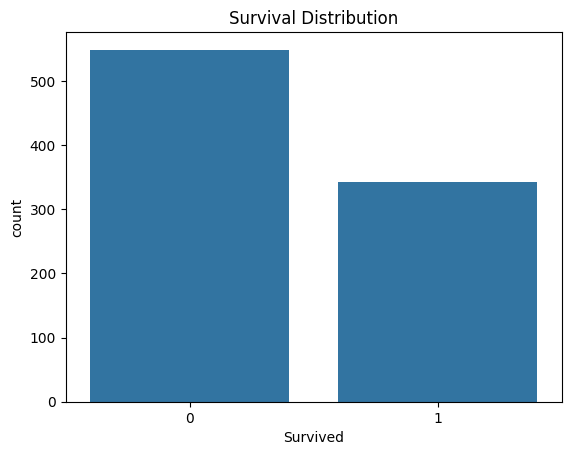

In [ ]:
# visualizations
sns.countplot(x='Survived', data=dataframe)
plt.title('Survival Distribution')
plt.show()

### Finding

Approximately 38.4% of passengers survived, while 61.6% did not.
Therefore, the target variable is moderately imbalanced.

## Survival vs Sex

In [ ]:
pd.crosstab(
    dataframe['Survived'],
    dataframe['Sex'],
    normalize='index'
) * 100

Sex,female,male
Survived,,
0,14.754098,85.245902
1,68.128655,31.871345


Female has 68.12% survival rate where male has 85.25% death rate.

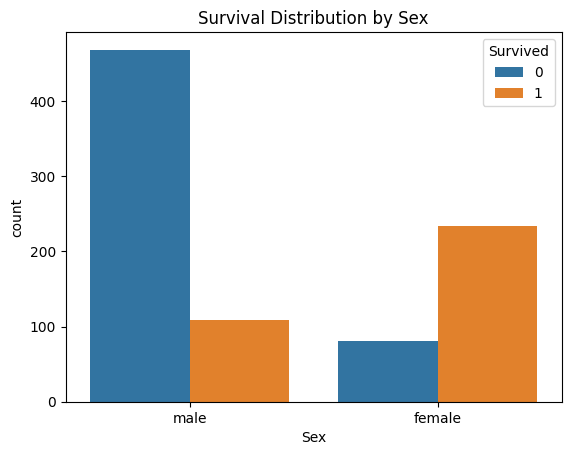

In [ ]:
# visualize it

sns.countplot(
    data=dataframe,
    x="Sex",
    hue="Survived"
)

plt.title("Survival Distribution by Sex")
plt.show()

### Finding

Female passengers had a substantially higher survival rate than
male passengers.

### ML Implication

`Sex` is likely to be one of the strongest predictive features
and should be retained for model training.


## Survival vs Pclass

In [ ]:
pd.crosstab(
    dataframe["Pclass"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


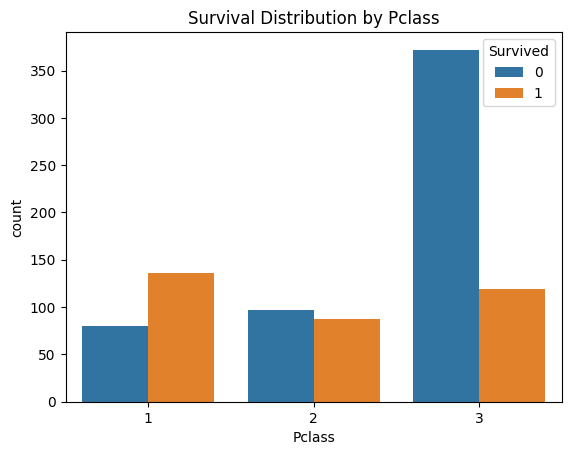

In [ ]:
# visualize it

sns.countplot(
    data=dataframe,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival Distribution by Pclass")
plt.show()

### Finding

Survival probability varies substantially across passenger classes.
First-class passengers had higher survival rates than second- and
third-class passengers.

### ML Implication

`Pclass` appears to contain meaningful predictive information and
should be retained.

## Survival vs Embarked

In [ ]:
pd.crosstab(
    dataframe["Embarked"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


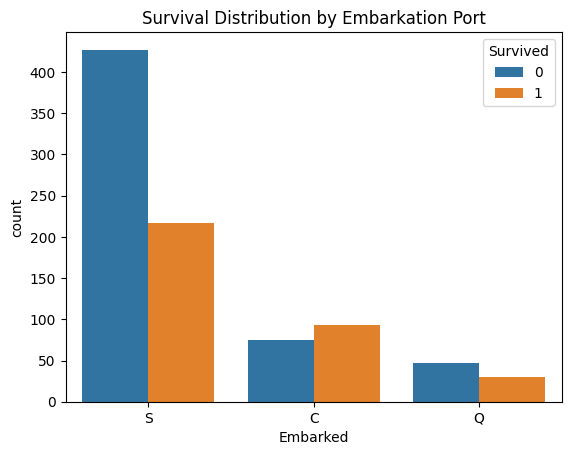

In [ ]:
# visualize it

sns.countplot(
    data=dataframe,
    x="Embarked",
    hue="Survived"
)

plt.title("Survival Distribution by Embarkation Port")
plt.show()

Embark port C has the highest survival rate which is 55.36%, port Q has 38.96% and port S has 33.69% survival rates.

## Survival vs Age

In [ ]:
pd.crosstab(
    dataframe["Age"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
Age,,
0.42,0.0,100.0
0.67,0.0,100.0
0.75,0.0,100.0
0.83,0.0,100.0
0.92,0.0,100.0
...,...,...
70.00,100.0,0.0
70.50,100.0,0.0
71.00,100.0,0.0


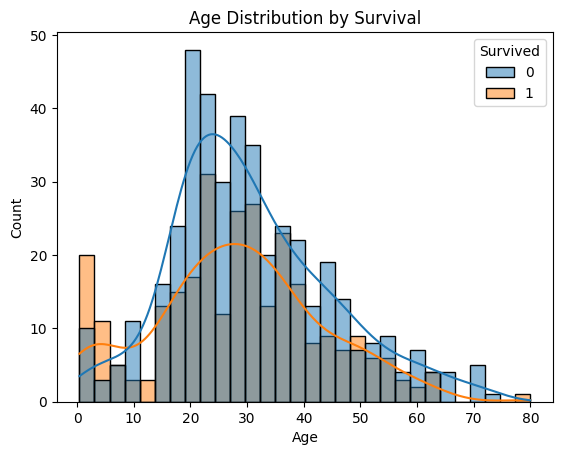

In [ ]:
sns.histplot(
    data=dataframe,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()

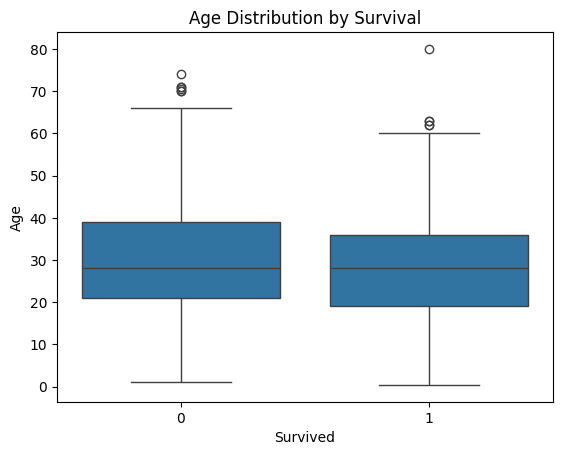

In [ ]:
sns.boxplot(
    data=dataframe,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")
plt.show()

In [ ]:
dataframe.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


## Survival vs Fare

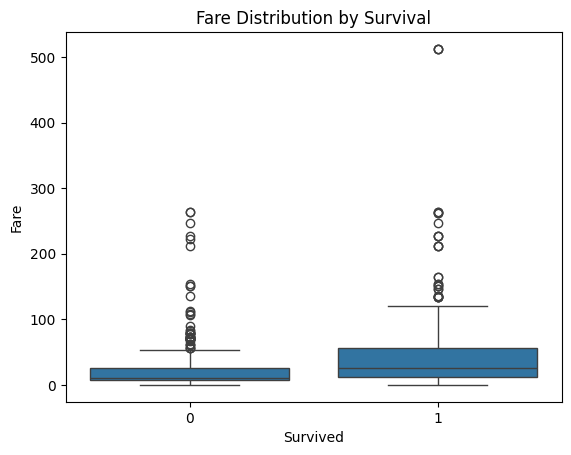

In [ ]:
sns.boxplot(
    data=dataframe,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.show()

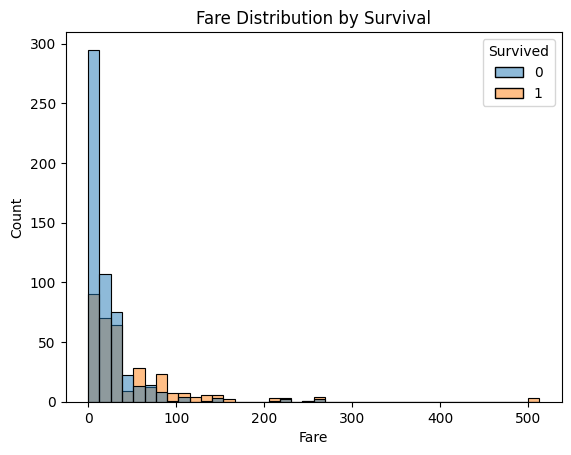

In [ ]:
sns.histplot(
    data=dataframe,
    x="Fare",
    hue="Survived",
    bins=40
)

plt.title("Fare Distribution by Survival")
plt.show()

In [ ]:
dataframe.groupby("Survived")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


This shows the higher fare may contribute the survival rates.

# Feature Engineering

## Family Size Feature Engineering

In [ ]:
dataframe['FamilySize'] = dataframe['SibSp'] + dataframe['Parch'] + 1

In [ ]:
dataframe[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [ ]:
pd.crosstab(
    dataframe["FamilySize"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
FamilySize,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


Needs further investigation

## IsAlone Feature

In [ ]:
dataframe["IsAlone"] = (dataframe["FamilySize"] == 1).astype(int)

In [ ]:
dataframe["IsAlone"].value_counts()

,count
IsAlone,
1,537
0,354


In [ ]:
pd.crosstab(
    dataframe["IsAlone"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
IsAlone,,
0,49.435028,50.564972
1,69.646182,30.353818


## Title Feature Engineering

In [ ]:
dataframe["Title"] = dataframe["Name"].str.extract(
    r" ([A-Za-z]+)\.",
    expand=False
)

In [ ]:
dataframe['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
dataframe["Title"] = dataframe["Title"].replace(
    [
        "Lady", "Countess", "Capt", "Col",
        "Don", "Dr", "Major", "Rev",
        "Sir", "Jonkheer", "Dona"
    ],
    "Rare"
)

In [ ]:
dataframe["Title"] = dataframe["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

In [ ]:
pd.crosstab(
    dataframe["Title"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
Title,,
Master,42.500000,57.500000
Miss,29.729730,70.270270
Mr,84.332689,15.667311
Mrs,20.634921,79.365079
Rare,65.217391,34.782609


## Deck Feature Engineering

In [ ]:
dataframe["Deck"] = dataframe["Cabin"].str[0]

In [ ]:
dataframe["Deck"] = dataframe["Deck"].fillna("Unknown")

In [ ]:
dataframe["Deck"].value_counts()

,count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [ ]:
pd.crosstab(
    dataframe["Deck"],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived,0,1
Deck,,
A,53.333333,46.666667
B,25.531915,74.468085
C,40.677966,59.322034
D,24.242424,75.757576
E,25.000000,75.000000
F,38.461538,61.538462
G,50.000000,50.000000
T,100.000000,0.000000
Unknown,70.014556,29.985444


### Summary

| Original Feature | Engineered Feature | Reason                                  |
| ---------------- | ------------------ | --------------------------------------- |
| `SibSp`, `Parch` | `FamilySize`       | Represents total family members         |
| `FamilySize`     | `IsAlone`          | Identifies solo travelers               |
| `Name`           | `Title`            | Extracts demographic/social information |
| `Cabin`          | `Deck`             | Extracts cabin/deck information         |


#  Multivariate EDA

## Sex + Pclass + Survival

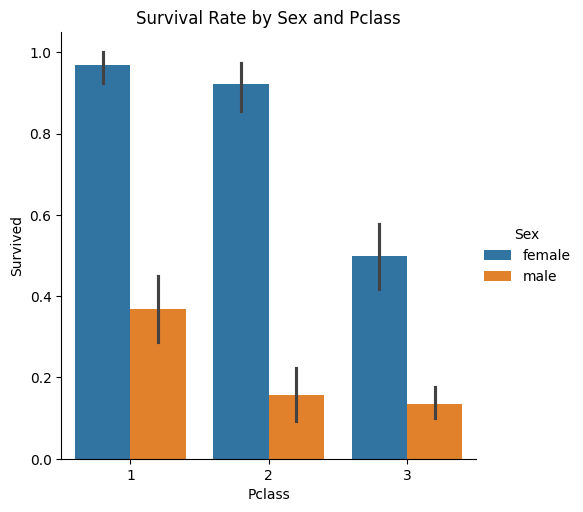

In [ ]:
sns.catplot(
    data=dataframe,
    x="Pclass",
    y="Survived",
    hue="Sex",
    kind="bar"
)

plt.title("Survival Rate by Sex and Pclass")
plt.show()


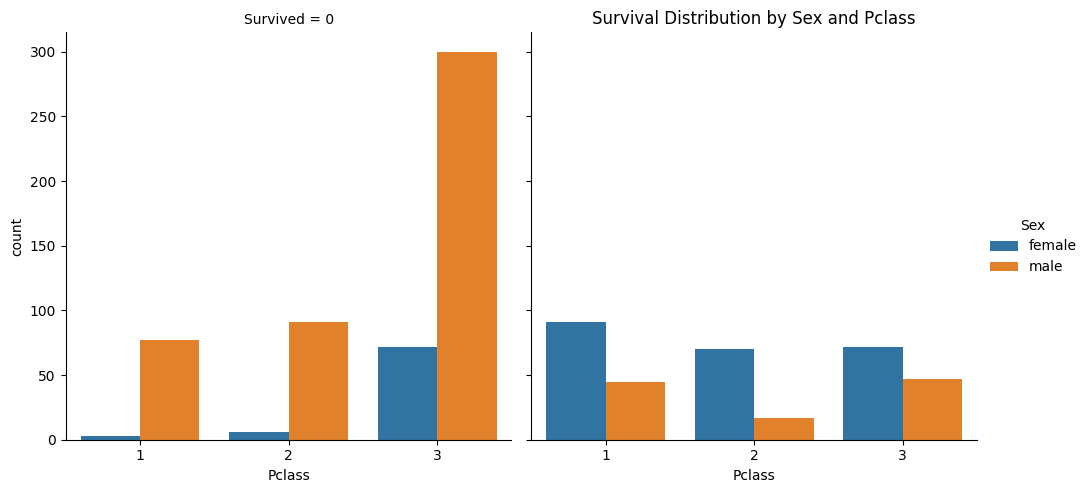

In [ ]:
sns.catplot(
    data=dataframe,
    x="Pclass",
    hue="Sex",
    col="Survived",
    kind="count"
)
plt.title("Survival Distribution by Sex and Pclass")

plt.show()

In [ ]:
pd.crosstab(
    [dataframe["Sex"], dataframe["Pclass"]],
    dataframe["Survived"],
    normalize="index"
) * 100

Survived               0          1
Sex    Pclass                      
female 1        3.191489  96.808511
       2        7.894737  92.105263
       3       50.000000  50.000000
male   1       63.114754  36.885246
       2       84.259259  15.740741
       3       86.455331  13.544669

All the Pclass has the female surviver higher than male.


### ML implication

Both Sex and Pclass are important features, but their combination provides more information than looking at either variable independently

In [ ]:
survival_rate = (
    dataframe
    .groupby(['Pclass', 'Sex'])['Survived']
    .mean()
    .reset_index()
)

survival_rate['Survived'] *= 100

survival_rate

,Pclass,Sex,Survived
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


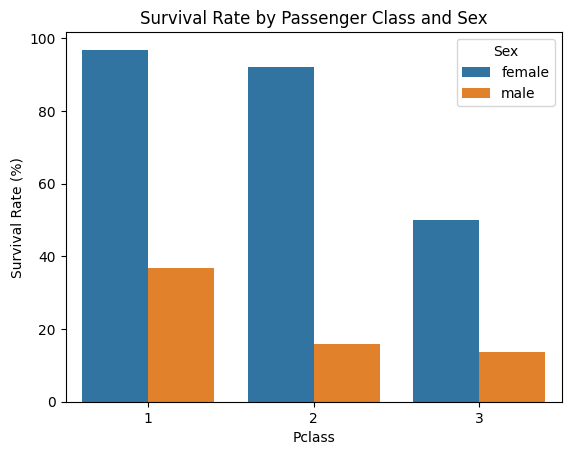

In [ ]:
sns.barplot(
    data=survival_rate,
    x='Pclass',
    y='Survived',
    hue='Sex'
)

plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Passenger Class and Sex')
plt.show()

## Sex + Age + Survival

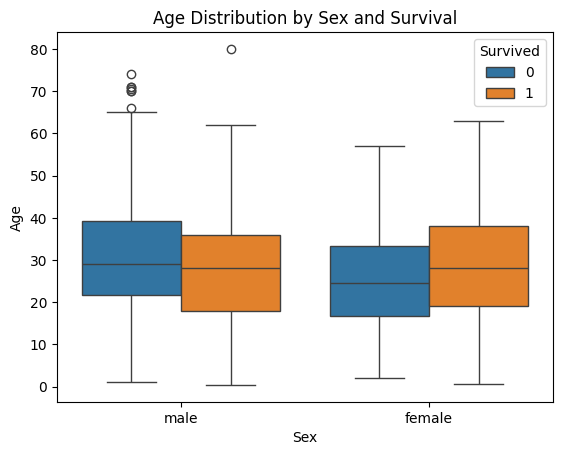

In [ ]:
sns.boxplot(
    data=dataframe,
    x='Sex',
    y='Age',
    hue='Survived'
)

plt.title('Age Distribution by Sex and Survival')
plt.show()

### We can do by using the age groups

In [ ]:
dataframe['AgeGroup'] = pd.cut(
    dataframe['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

In [ ]:
pd.crosstab(
    [dataframe['Sex'], dataframe['AgeGroup']],
    dataframe['Survived'],
    normalize='index'
) * 100

Survived                    0           1
Sex    AgeGroup                          
female Child        40.625000   59.375000
       Teen         25.000000   75.000000
       Young Adult  21.666667   78.333333
       Adult        22.857143   77.142857
       Senior        0.000000  100.000000
male   Child        43.243243   56.756757
       Teen         91.176471    8.823529
       Young Adult  81.932773   18.067227
       Adult        80.800000   19.200000
       Senior       89.473684   10.526316

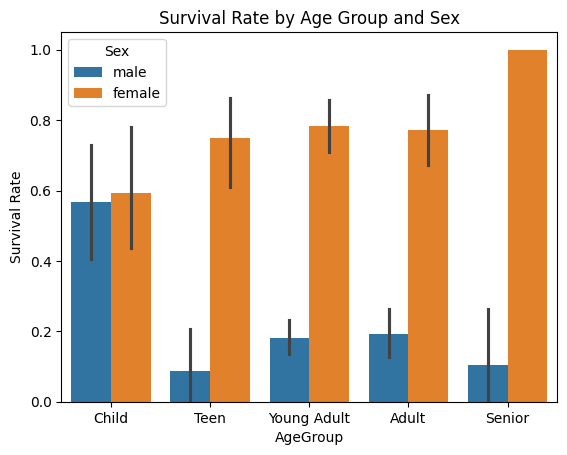

In [ ]:
sns.barplot(
    data=dataframe,
    x='AgeGroup',
    y='Survived',
    hue='Sex'
)

plt.title('Survival Rate by Age Group and Sex')
plt.ylabel('Survival Rate')
plt.show()

From above, there is almost same survival rate in child age group but in other age group has female surviver higher.

## Pclass + Age + Survival

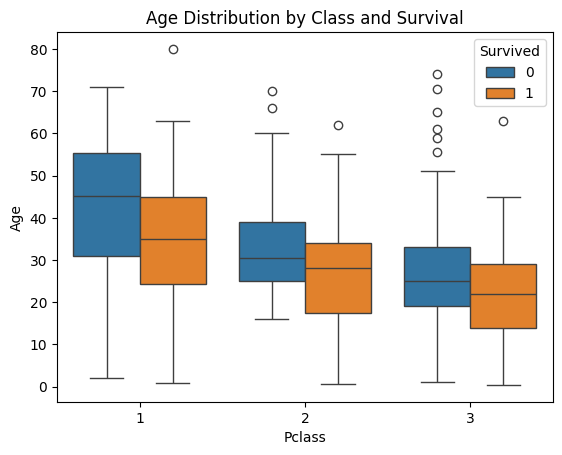

In [ ]:
sns.boxplot(
    data=dataframe,
    x='Pclass',
    y='Age',
    hue='Survived'
)

plt.title('Age Distribution by Class and Survival')
plt.show()

### By calculate survival rates by age group and class

In [ ]:
pd.crosstab(
    [dataframe['Pclass'], dataframe['AgeGroup']],
    dataframe['Survived'],
    normalize='index'
) * 100

Survived                    0           1
Pclass AgeGroup                          
1      Child        25.000000   75.000000
       Teen          8.333333   91.666667
       Young Adult  24.242424   75.757576
       Adult        38.888889   61.111111
       Senior       78.571429   21.428571
2      Child         0.000000  100.000000
       Teen         50.000000   50.000000
       Young Adult  56.382979   43.617021
       Adult        61.702128   38.297872
       Senior       66.666667   33.333333
3      Child        58.333333   41.666667
       Teen         71.739130   28.260870
       Young Adult  76.767677   23.232323
       Adult        91.379310    8.620690
       Senior       80.000000   20.000000

## Sex + Pclass + Age + Survival

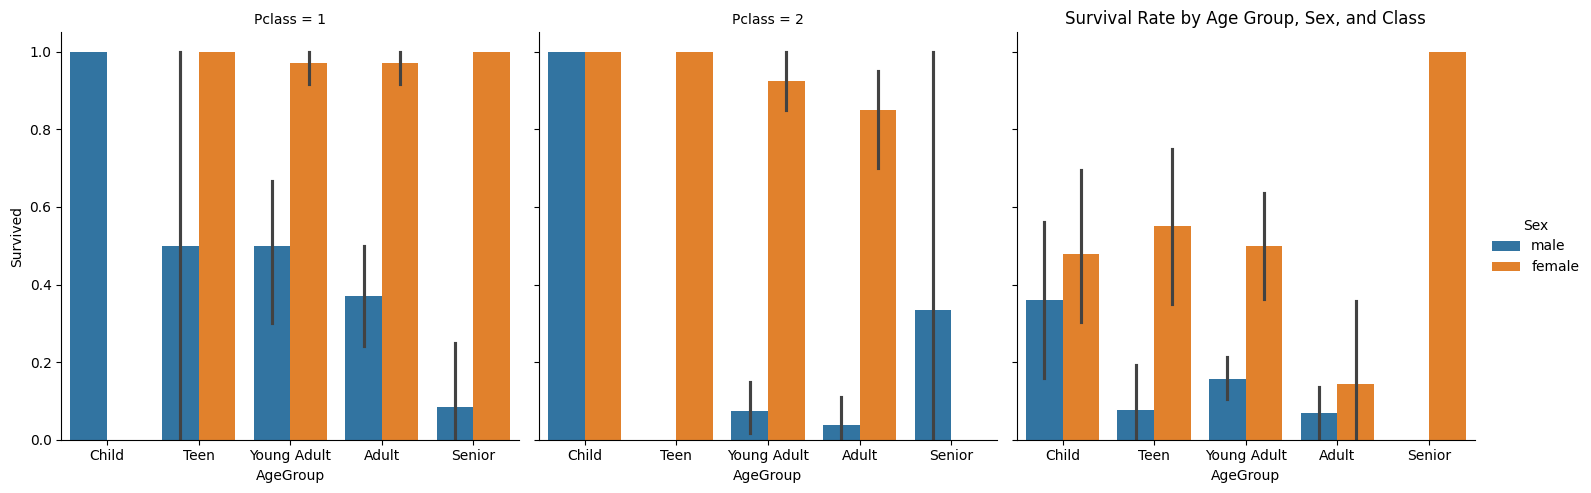

In [ ]:
sns.catplot(
    data=dataframe,
    x='AgeGroup',
    y='Survived',
    hue='Sex',
    col='Pclass',
    kind='bar'
)

plt.title('Survival Rate by Age Group, Sex, and Class')
plt.show()

## FamilySize + sex + Survival

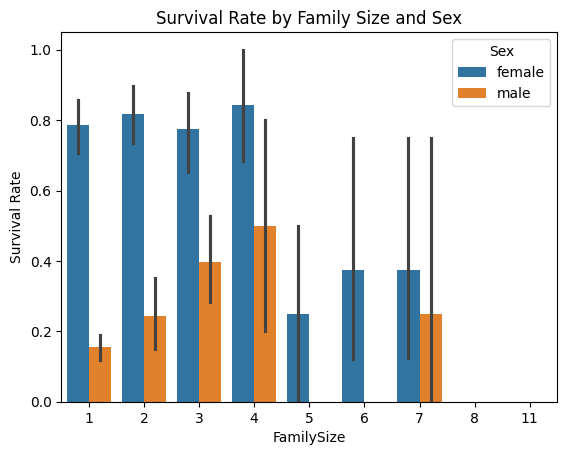

In [ ]:
sns.barplot(
    data=dataframe,
    x='FamilySize',
    y='Survived',
    hue='Sex'
)

plt.title('Survival Rate by Family Size and Sex')
plt.ylabel('Survival Rate')
plt.show()

familysize have a non-linear relationship with survival

## IsAlone + Sex + Pclass + Survival

In [ ]:
pd.crosstab(
    [dataframe['Sex'], dataframe['Pclass']],
    dataframe['IsAlone'],
    normalize='index'
) * 100

IsAlone                0          1
Sex    Pclass                      
female 1       63.829787  36.170213
       2       57.894737  42.105263
       3       58.333333  41.666667
male   1       38.524590  61.475410
       2       33.333333  66.666667
       3       23.919308  76.080692

In [ ]:
dataframe.groupby(
    ['Sex', 'Pclass', 'IsAlone']
)['Survived'].mean() * 100

Sex     Pclass  IsAlone
female  1       0          96.666667
                1          97.058824
        2       0          93.181818
                1          90.625000
        3       0          41.666667
                1          61.666667
male    1       0          42.553191
                1          33.333333
        2       0          27.777778
                1           9.722222
        3       0          18.072289
                1          12.121212
Name: Survived, dtype: float64

## Fare + pclass + survival

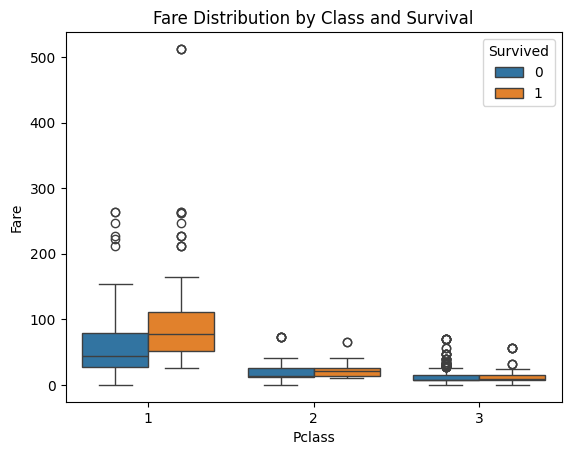

In [ ]:
sns.boxplot(
    data=dataframe,
    x='Pclass',
    y='Fare',
    hue='Survived'
)

plt.title('Fare Distribution by Class and Survival')
plt.show()

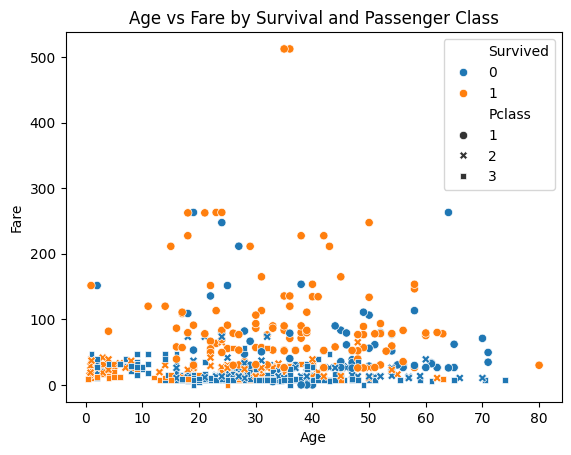

In [ ]:
sns.scatterplot(
    data=dataframe,
    x='Age',
    y='Fare',
    hue='Survived',
    style='Pclass'
)

plt.title('Age vs Fare by Survival and Passenger Class')
plt.show()

## Age + Fare + Survival

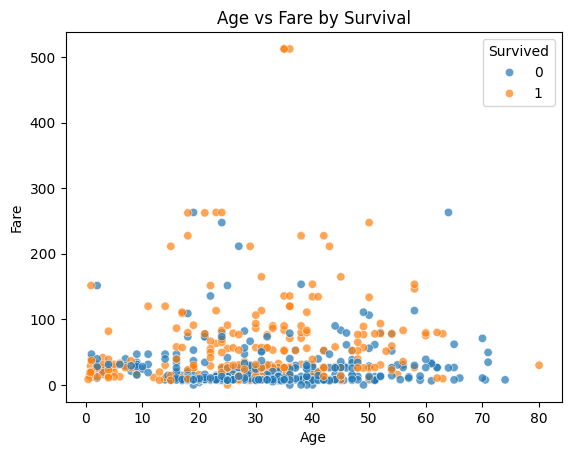

In [ ]:
sns.scatterplot(
    data=dataframe,
    x='Age',
    y='Fare',
    hue='Survived',
    alpha=0.7
)

plt.title('Age vs Fare by Survival')
plt.show()

Are survivors concentrated among certain age and fare ranges?

## Embarked + sex + Pclass + Survival

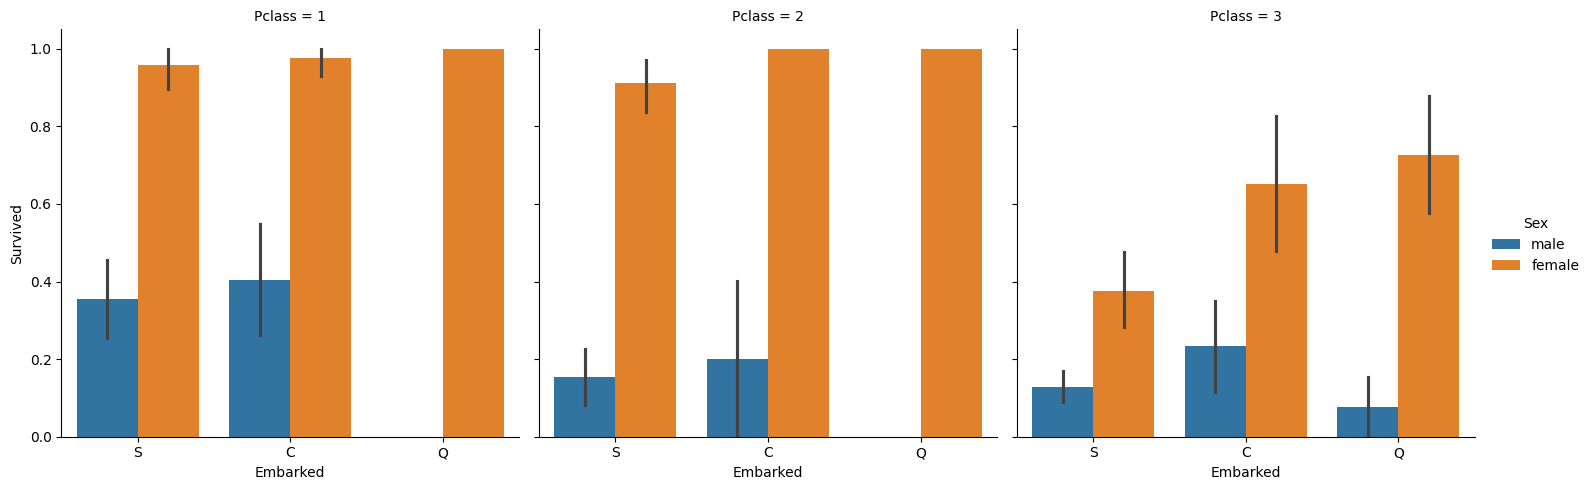

In [ ]:
sns.catplot(
    data=dataframe,
    x='Embarked',
    y='Survived',
    hue='Sex',
    col='Pclass',
    kind='bar'
)

plt.show()

Does the relationship between Embarked and survival remain after considering Sex and Pclass?

## Title + Sex + pclass + Survival

In [ ]:


dataframe['Title']

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rare
887,Miss
888,Miss
889,Mr


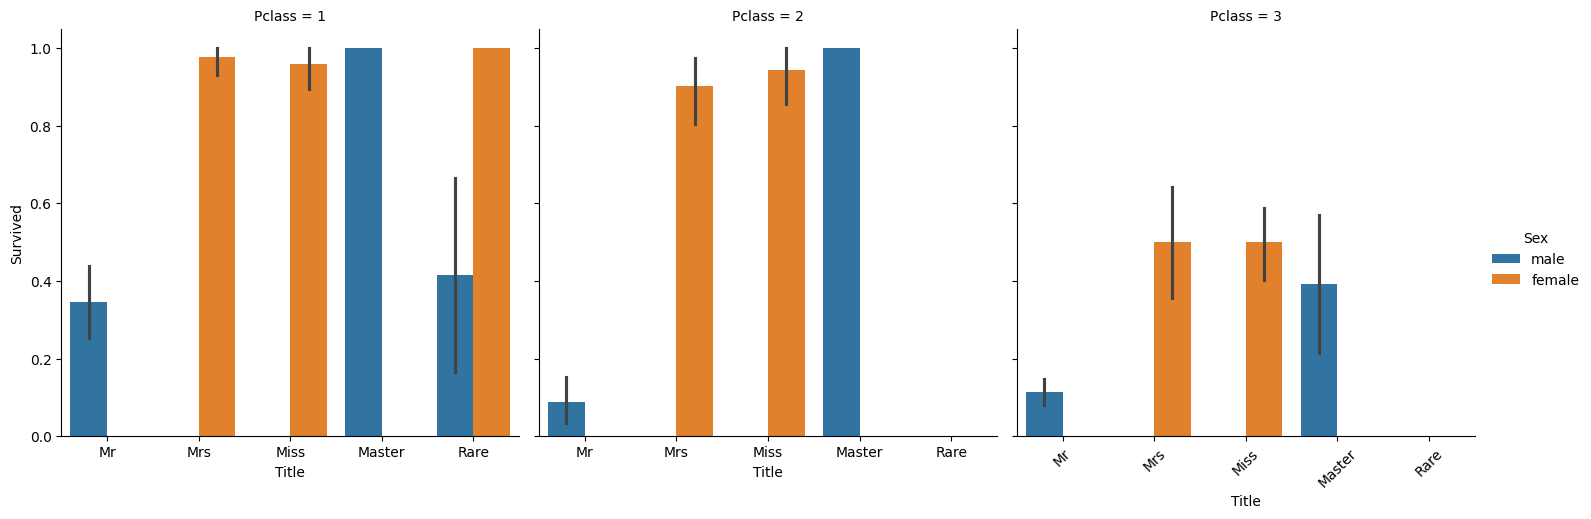

In [ ]:
sns.catplot(
    data=dataframe,
    x='Title',
    y='Survived',
    hue='Sex',
    col='Pclass',
    kind='bar'
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
dataframe.groupby(
    ['Title', 'Pclass']
)['Survived'].agg(['count', 'mean'])

count      mean
Title  Pclass                 
Master 1           3  1.000000
       2           9  1.000000
       3          28  0.392857
Miss   1          48  0.958333
       2          35  0.942857
       3         102  0.500000
Mr     1         107  0.345794
       2          91  0.087912
       3         319  0.112853
Mrs    1          43  0.976744
       2          41  0.902439
       3          42  0.500000
Rare   1          15  0.533333
       2           8  0.000000

## Deck + Pclass + Survival

In [ ]:
dataframe['Deck']

,Deck
0,Unknown
1,C
2,Unknown
3,C
4,Unknown
...,...
886,Unknown
887,B
888,Unknown
889,C


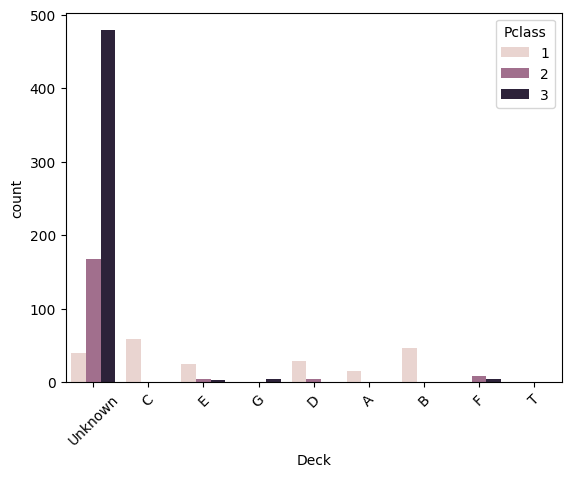

In [ ]:
sns.countplot(
    data=dataframe,
    x='Deck',
    hue='Pclass'
)

plt.xticks(rotation=45)
plt.show()


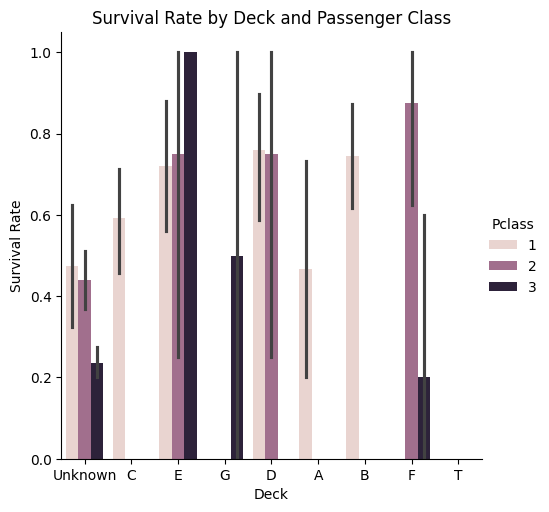

In [ ]:
sns.catplot(
    data=dataframe,
    x='Deck',
    y='Survived',
    hue='Pclass',
    kind='bar'
)

plt.title('Survival Rate by Deck and Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

This is useful because Deck potentially represents location on the ship, while Pclass represents socioeconomic class.

### Correlation Analysis

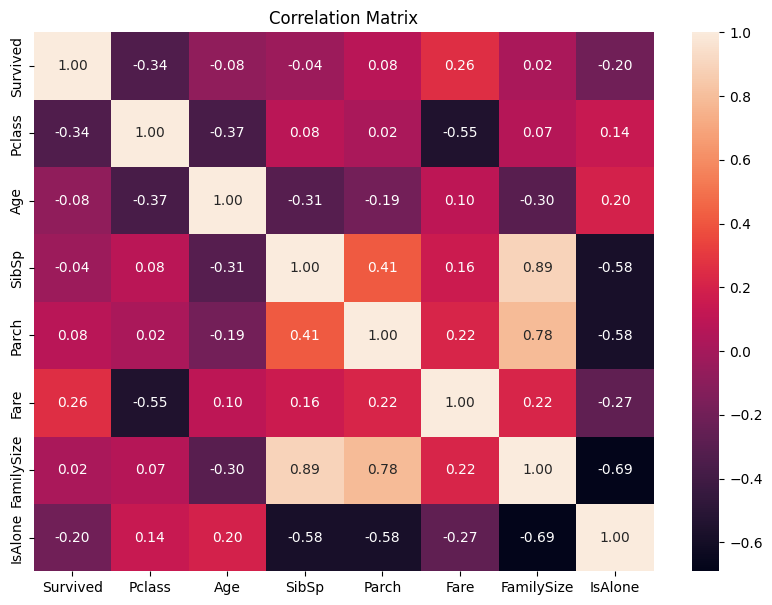

In [ ]:
numeric_features = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

corr = dataframe[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

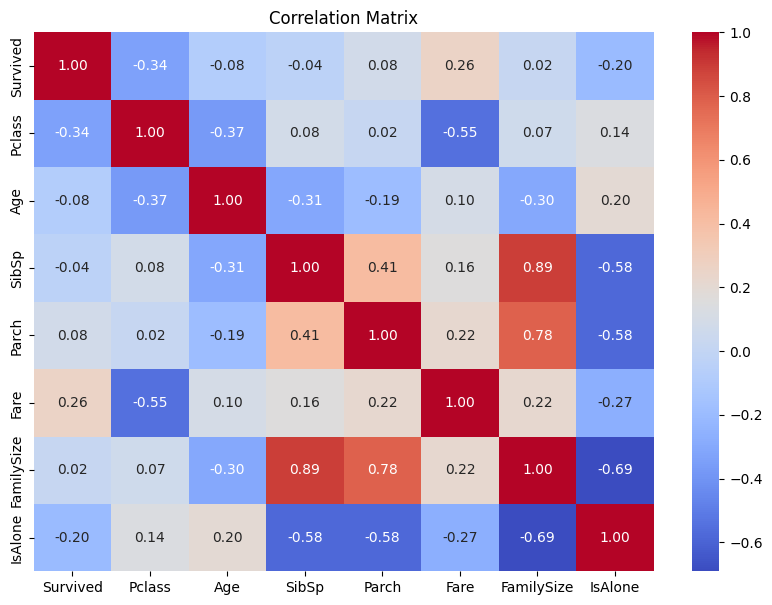

In [ ]:
numeric_cols = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone'
]

corr = dataframe[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

# Data Cleaning

Make the dataset reliable and ready for feature engineering/modeling without introducing data leakage.

## Checking Missing values

In [ ]:
dataframe.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
missing = pd.DataFrame({
    'Missing Values': dataframe.isnull().sum(),
    'Percentage': dataframe.isnull().mean() * 100
})

missing.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
Cabin,687,77.104377
AgeGroup,177,19.865320
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Sex,0,0.000000
Survived,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Ticket,0,0.000000


In [ ]:
dataframe['Deck'] = dataframe['Cabin'].str[0]

In [ ]:
dataframe['Deck'] = dataframe['Cabin'].str[0].fillna('Unknown')

In [ ]:
dataframe.drop(columns=['Cabin'], inplace=True)

## Check duplicates

In [ ]:
dataframe.duplicated().sum()

np.int64(0)

## Check invalid values

In [ ]:
dataframe.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,Deck,AgeGroup
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,889,891.000000,891.000000,891,891,714
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,3,NaN,NaN,5,9,5
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,S,NaN,NaN,Mr,Unknown,Young Adult
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,644,NaN,NaN,517,687,358
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,1.904602,0.602694,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,1.613459,0.489615,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,1.000000,0.000000,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,1.000000,0.000000,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,1.000000,1.000000,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,2.000000,1.000000,NaN,NaN,NaN


In [ ]:
# for numerical columns

dataframe.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602,0.602694
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000


## check categorical consistency

In [ ]:
for col in ['Sex', 'Embarked', 'Pclass', 'Title', 'Deck']:
    print(f"\n--- {col} ---")
    print(dataframe[col].value_counts(dropna=False))


--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Embarked ---
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Title ---
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

--- Deck ---
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


In [ ]:
for col in ['Sex', 'Embarked', 'Pclass']:
    print(f"{col}:")
    print(dataframe[col].value_counts())
    print

Sex:
Sex
male      577
female    314
Name: count, dtype: int64
Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
dataframe[['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].describe()

,Age,Fare,SibSp,Parch,FamilySize,IsAlone
count,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594,1.904602,0.602694
std,14.526497,49.693429,1.102743,0.806057,1.613459,0.489615
min,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000,1.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000,1.000000,1.000000
75%,38.000000,31.000000,1.000000,0.000000,2.000000,1.000000
max,80.000000,512.329200,8.000000,6.000000,11.000000,1.000000


potential modeling features are FamilySize,
IsAlone,
Title,
Deck

geGroup and FareGroup are useful for understanding patterns, but we don't necessarily need to use them in the final model because we can allow the model to work with the original continuous variables Age and Fare.

### Droping the  columns Name, ticket and PassengerId

In [ ]:
# PassengerId

dataframe.drop(columns=['PassengerId'], inplace=True)

### Data cleaning decision table

| Feature     | Problem                  | Action            |
| ----------- | ------------------------ | ----------------- |
| PassengerId | Identifier               | Drop              |
| Name        | High cardinality         | Extract Title     |
| Cabin       | Many missing values      | Extract Deck      |
| Age         | Missing values           | Impute            |
| Embarked    | Missing values           | Impute            |
| Ticket      | Complex/high cardinality | Feature engineer  |
| Fare        | Skew/outliers            | Keep, investigate |
| SibSp       | Numerical                | Keep              |
| Parch       | Numerical                | Keep              |
| Sex         | Categorical              | Keep              |
| Pclass      | Categorical/ordinal      | Keep              |
| Survived    | Target                   | Keep as target    |


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Name        891 non-null    object  
 3   Sex         891 non-null    object  
 4   Age         714 non-null    float64 
 5   SibSp       891 non-null    int64   
 6   Parch       891 non-null    int64   
 7   Ticket      891 non-null    object  
 8   Fare        891 non-null    float64 
 9   Embarked    889 non-null    object  
 10  FamilySize  891 non-null    int64   
 11  IsAlone     891 non-null    int64   
 12  Title       891 non-null    object  
 13  Deck        891 non-null    object  
 14  AgeGroup    714 non-null    category
dtypes: category(1), float64(2), int64(6), object(6)
memory usage: 98.7+ KB


In [ ]:
dataframe['Ticket'].nunique()

681

In [ ]:
dataframe['Ticket'].value_counts().head(10)

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
347088,6
382652,5
S.O.C. 14879,5
113760,4


# Feature Engineering

## Feature Engineering

Several features were created to capture information
that may not be directly represented by the original
dataset columns.

These include:

- FamilySize
- IsAlone
- Title
- Deck
- TicketGroupSize
- FarePerPerson
- FareGroup

These features were selected because family relationships,
social status, cabin information, ticket groups, and fare
may provide additional information about passenger survival.

In [ ]:
# TicketGroupSize

dataframe['TicketGroupSize'] = dataframe.groupby('Ticket')['Ticket'].transform('count')

In [ ]:
dataframe[['Ticket', 'TicketGroupSize']].head(20)

,Ticket,TicketGroupSize
0,A/5 21171,1
1,PC 17599,1
2,STON/O2. 3101282,1
3,113803,2
4,373450,1
5,330877,1
6,17463,1
7,349909,4
8,347742,3
9,237736,2


In [ ]:
dataframe['TicketGroupSize'].value_counts().sort_index()

,count
TicketGroupSize,
1,547
2,188
3,63
4,44
5,10
6,18
7,21


### Analyze ticketgroupsize vs survival

In [ ]:
ticket_survival = (
    dataframe
    .groupby('TicketGroupSize')['Survived']
    .agg(['count', 'mean'])
    .reset_index()
)

ticket_survival['mean'] *= 100

ticket_survival

,TicketGroupSize,count,mean
0,1,547,29.798903
1,2,188,57.446809
2,3,63,69.841270
3,4,44,50.000000
4,5,10,0.000000
5,6,18,0.000000
6,7,21,23.809524


In [ ]:
ticket_survival.rename(
    columns={'mean': 'SurvivalRate'},
    inplace=True
)

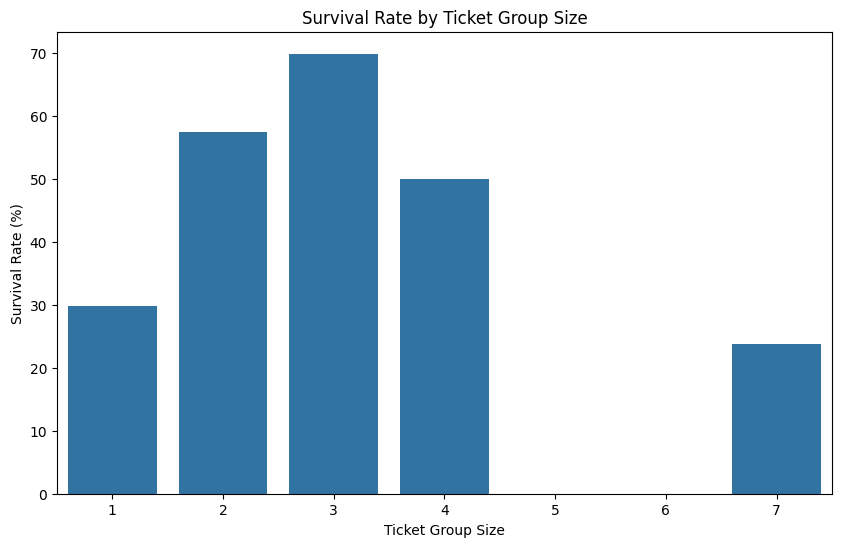

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ticket_survival,
    x='TicketGroupSize',
    y='SurvivalRate'
)

plt.title('Survival Rate by Ticket Group Size')
plt.xlabel('Ticket Group Size')
plt.ylabel('Survival Rate (%)')

plt.show()

Important

Look for whether:

solo ticket holders behave differently
small groups have different survival
very large groups have different survival

# combine ticketgroupsize + sex

In [ ]:
ticket_sex = (
    dataframe
    .groupby(['TicketGroupSize', 'Sex'])['Survived']
    .mean()
    .reset_index()
)

ticket_sex['Survived'] *= 100

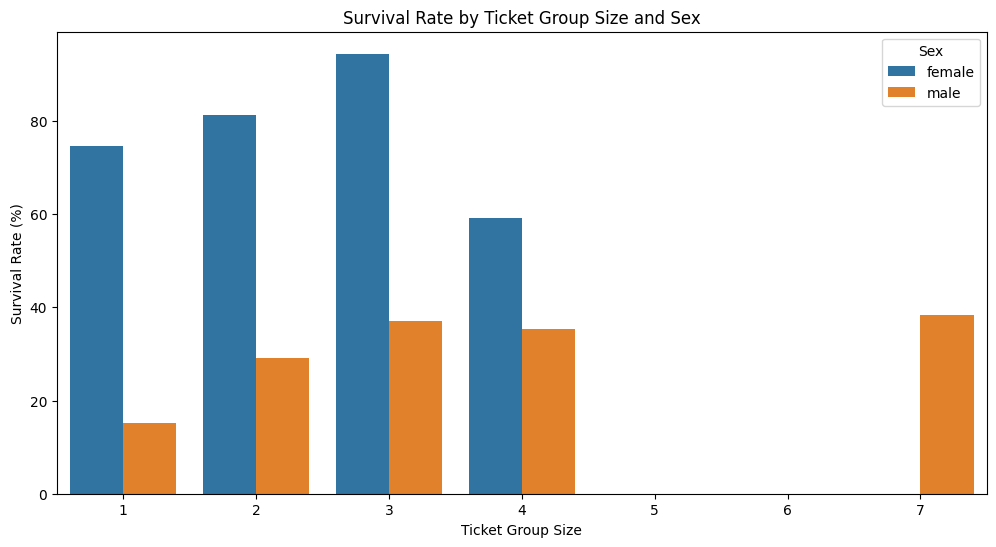

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=ticket_sex,
    x='TicketGroupSize',
    y='Survived',
    hue='Sex'
)

plt.title('Survival Rate by Ticket Group Size and Sex')
plt.xlabel('Ticket Group Size')
plt.ylabel('Survival Rate (%)')

plt.show()

Does traveling with a group have the same relationship with survival for males and females?

# Ticketgroupsize + Pclass + sex

In [ ]:
ticket_multivariate = (
    dataframe
    .groupby(
        ['TicketGroupSize', 'Pclass', 'Sex']
    )['Survived']
    .mean()
    .reset_index()
)

ticket_multivariate['Survived'] *= 100

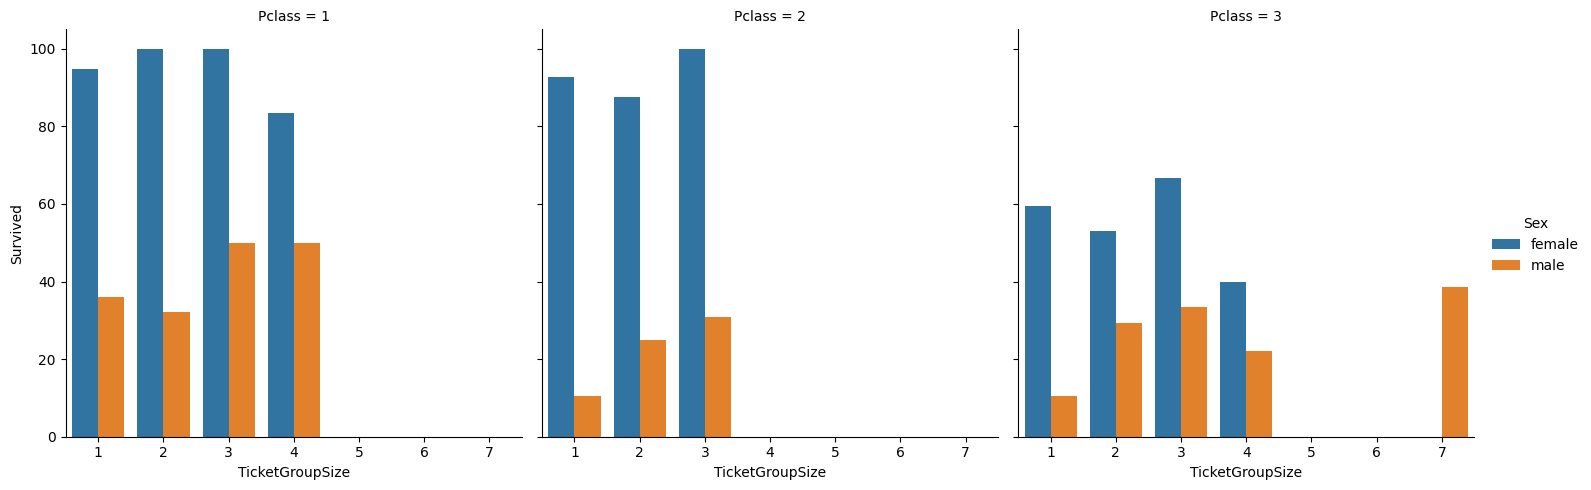

In [ ]:
sns.catplot(
    data=ticket_multivariate,
    x='TicketGroupSize',
    y='Survived',
    hue='Sex',
    col='Pclass',
    kind='bar',
    height=5,
    aspect=1
)

plt.show()

In [ ]:
# faregroup created

dataframe['FarePerPerson'] = (
    dataframe['Fare'] / dataframe['TicketGroupSize']
)

In [ ]:
dataframe[
    ['Fare', 'TicketGroupSize', 'FarePerPerson']
].head(20)

,Fare,TicketGroupSize,FarePerPerson
0,7.2500,1,7.250000
1,71.2833,1,71.283300
2,7.9250,1,7.925000
3,53.1000,2,26.550000
4,8.0500,1,8.050000
5,8.4583,1,8.458300
6,51.8625,1,51.862500
7,21.0750,4,5.268750
8,11.1333,3,3.711100
9,30.0708,2,15.035400


In [ ]:
dataframe['FarePerPerson'].describe()

,FarePerPerson
count,891.000000
mean,17.788989
std,21.218157
min,0.000000
25%,7.762500
50%,8.850000
75%,24.288200
max,221.779200


calculate exactly how many passengers have shared tickets

In [ ]:
(dataframe['TicketGroupSize'] > 1).sum()

np.int64(344)

In [ ]:
(dataframe['TicketGroupSize'] > 1).mean() * 100

np.float64(38.60830527497194)

In [ ]:
dataframe['TicketGroupSize'] = (
    dataframe.groupby('Ticket')['Ticket'].transform('count')
)

In [ ]:
dataframe['TicketGroupSize'].value_counts().sort_index()

,count
TicketGroupSize,
1,547
2,188
3,63
4,44
5,10
6,18
7,21


In [ ]:
(dataframe['TicketGroupSize'] > 1).sum()

np.int64(344)

In [ ]:
(dataframe['TicketGroupSize'] > 1).mean() * 100

np.float64(38.60830527497194)

## Does TicketGroupSize actually contain information about survival?

In [ ]:
ticket_survival = (
    dataframe
    .groupby('TicketGroupSize')['Survived']
    .agg(['count', 'mean'])
    .reset_index()
)

ticket_survival['SurvivalRate'] = ticket_survival['mean'] * 100

ticket_survival.drop(columns='mean')

,TicketGroupSize,count,SurvivalRate
0,1,547,29.798903
1,2,188,57.446809
2,3,63,69.841270
3,4,44,50.000000
4,5,10,0.000000
5,6,18,0.000000
6,7,21,23.809524


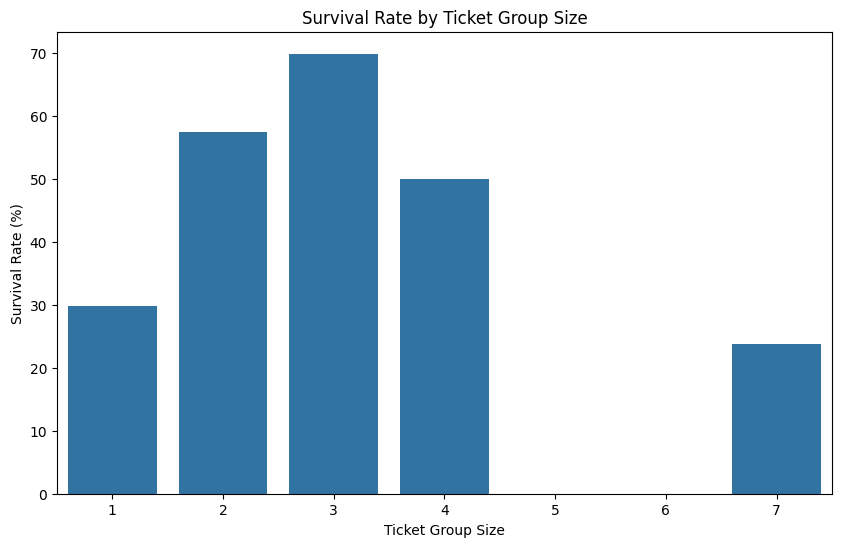

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ticket_survival,
    x='TicketGroupSize',
    y='SurvivalRate'
)

plt.title('Survival Rate by Ticket Group Size')
plt.xlabel('Ticket Group Size')
plt.ylabel('Survival Rate (%)')

plt.show()

In [ ]:
ticket_sex = (
    dataframe
    .groupby(['TicketGroupSize', 'Sex'])['Survived']
    .agg(['count', 'mean'])
    .reset_index()
)

ticket_sex['SurvivalRate'] = ticket_sex['mean'] * 100

ticket_sex

,TicketGroupSize,Sex,count,mean,SurvivalRate
0,1,female,134,0.746269,74.626866
1,1,male,413,0.152542,15.254237
2,2,female,102,0.813725,81.372549
3,2,male,86,0.290698,29.069767
4,3,female,36,0.944444,94.444444
5,3,male,27,0.370370,37.037037
6,4,female,27,0.592593,59.259259
7,4,male,17,0.352941,35.294118
8,5,female,1,0.000000,0.000000
9,5,male,9,0.000000,0.000000


Note: don't conclude that larger ticket groups have lower survival. look at the smale sizes

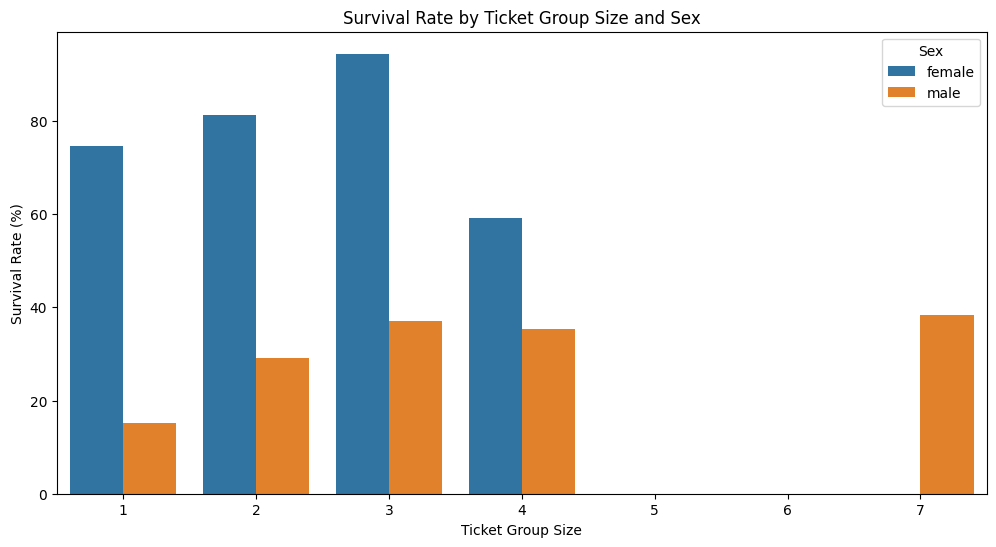

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=ticket_sex,
    x='TicketGroupSize',
    y='SurvivalRate',
    hue='Sex'
)

plt.title('Survival Rate by Ticket Group Size and Sex')
plt.xlabel('Ticket Group Size')
plt.ylabel('Survival Rate (%)')

plt.show()

In [ ]:
# dataframe['TicketGroup'] = np.where(
#     dataframe['TicketGroupSize'] == 1,
#     'Alone',
#     'Group'
# )

In [ ]:
# Calculate the number of passengers sharing each ticket
dataframe['TicketGroupSize'] = (
    dataframe.groupby('Ticket')['Ticket'].transform('count')
)

# Calculate approximate fare per passenger
dataframe['FarePerPerson'] = (
    dataframe['Fare'] / dataframe['TicketGroupSize']
)

# Inspect engineered features
dataframe[
    ['Ticket', 'Fare', 'TicketGroupSize', 'FarePerPerson']
].head(10)

,Ticket,Fare,TicketGroupSize,FarePerPerson
0,A/5 21171,7.2500,1,7.25000
1,PC 17599,71.2833,1,71.28330
2,STON/O2. 3101282,7.9250,1,7.92500
3,113803,53.1000,2,26.55000
4,373450,8.0500,1,8.05000
5,330877,8.4583,1,8.45830
6,17463,51.8625,1,51.86250
7,349909,21.0750,4,5.26875
8,347742,11.1333,3,3.71110
9,237736,30.0708,2,15.03540


In [ ]:
print("Missing values:")
print(dataframe['FarePerPerson'].isnull().sum())

print("\nInfinite values:")
print(np.isinf(dataframe['FarePerPerson']).sum())

print("\nSummary:")
print(dataframe['FarePerPerson'].describe())

Missing values:
0

Infinite values:
0

Summary:
count    891.000000
mean      17.788989
std       21.218157
min        0.000000
25%        7.762500
50%        8.850000
75%       24.288200
max      221.779200
Name: FarePerPerson, dtype: float64


Feature: TicketGroupSize

The Ticket feature was used to calculate the number of passengers sharing each ticket. This provides information about the size of the traveling group, which may capture family or group relationships not completely represented by SibSp and Parch.


Feature: FarePerPerson

FarePerPerson was engineered by dividing the ticket fare by the number of passengers sharing the same ticket. This provides an approximate passenger-level representation of the fare and may provide additional information beyond the raw Fare feature.

In [ ]:
dataframe.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Deck',
       'AgeGroup', 'TicketGroupSize', 'FarePerPerson'],
      dtype='object')

In [ ]:
dataframe[['Ticket', 'Fare']].head()

,Ticket,Fare
0,A/5 21171,7.2500
1,PC 17599,71.2833
2,STON/O2. 3101282,7.9250
3,113803,53.1000
4,373450,8.0500


In [ ]:
dataframe['TicketGroupSize'] = (
    dataframe.groupby('Ticket')['Ticket'].transform('count')
)

In [ ]:
dataframe[['Ticket','Fare', 'TicketGroupSize']].head()

,Ticket,Fare,TicketGroupSize
0,A/5 21171,7.2500,1
1,PC 17599,71.2833,1
2,STON/O2. 3101282,7.9250,1
3,113803,53.1000,2
4,373450,8.0500,1


In [ ]:
# Check the distribution of ticket group sizes
dataframe['TicketGroupSize'].value_counts().sort_index()

,count
TicketGroupSize,
1,547
2,188
3,63
4,44
5,10
6,18
7,21


In [ ]:
# Statistical summary
dataframe['TicketGroupSize'].describe()

,TicketGroupSize
count,891.000000
mean,1.787879
std,1.361142
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


In [ ]:
# Calculate approximate fare per passenger
dataframe['FarePerPerson'] = (
    dataframe['Fare'] / dataframe['TicketGroupSize']
)

dataframe[
    ['Ticket', 'Fare', 'TicketGroupSize', 'FarePerPerson']
].head(10)

,Ticket,Fare,TicketGroupSize,FarePerPerson
0,A/5 21171,7.2500,1,7.25000
1,PC 17599,71.2833,1,71.28330
2,STON/O2. 3101282,7.9250,1,7.92500
3,113803,53.1000,2,26.55000
4,373450,8.0500,1,8.05000
5,330877,8.4583,1,8.45830
6,17463,51.8625,1,51.86250
7,349909,21.0750,4,5.26875
8,347742,11.1333,3,3.71110
9,237736,30.0708,2,15.03540


In [ ]:
dataframe[
    ['Fare', 'TicketGroupSize', 'FarePerPerson']
].describe()

,Fare,TicketGroupSize,FarePerPerson
count,891.000000,891.000000,891.000000
mean,32.204208,1.787879,17.788989
std,49.693429,1.361142,21.218157
min,0.000000,1.000000,0.000000
25%,7.910400,1.000000,7.762500
50%,14.454200,1.000000,8.850000
75%,31.000000,2.000000,24.288200
max,512.329200,7.000000,221.779200


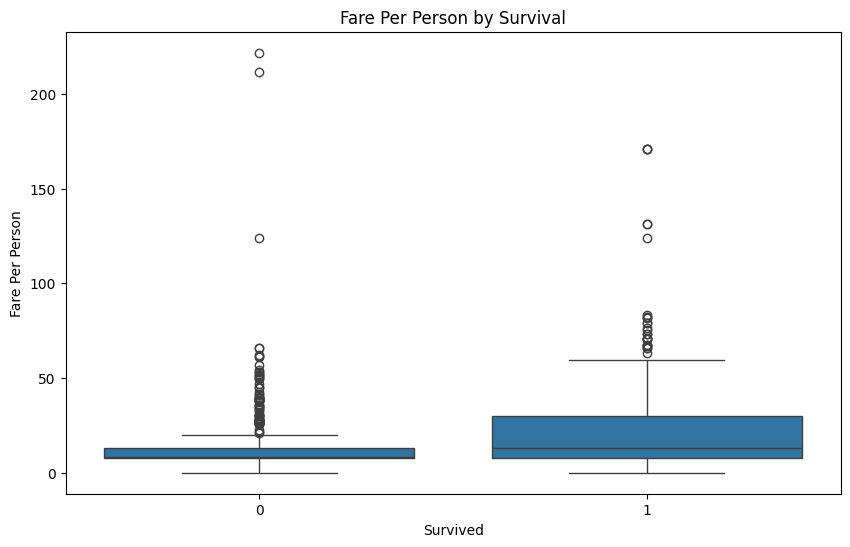

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=dataframe,
    x='Survived',
    y='FarePerPerson'
)

plt.title('Fare Per Person by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare Per Person')

plt.show()

Do survivors and non-survivors have noticeably different FarePerPerson distributions?

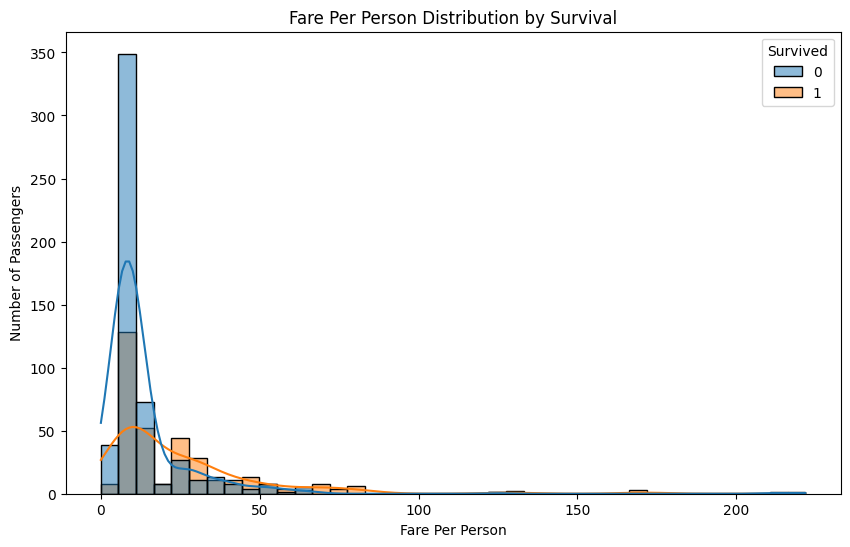

In [ ]:
# Fareperpersion distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=dataframe,
    x='FarePerPerson',
    hue='Survived',
    bins=40,
    kde=True
)

plt.title('Fare Per Person Distribution by Survival')
plt.xlabel('Fare Per Person')
plt.ylabel('Number of Passengers')

plt.show()

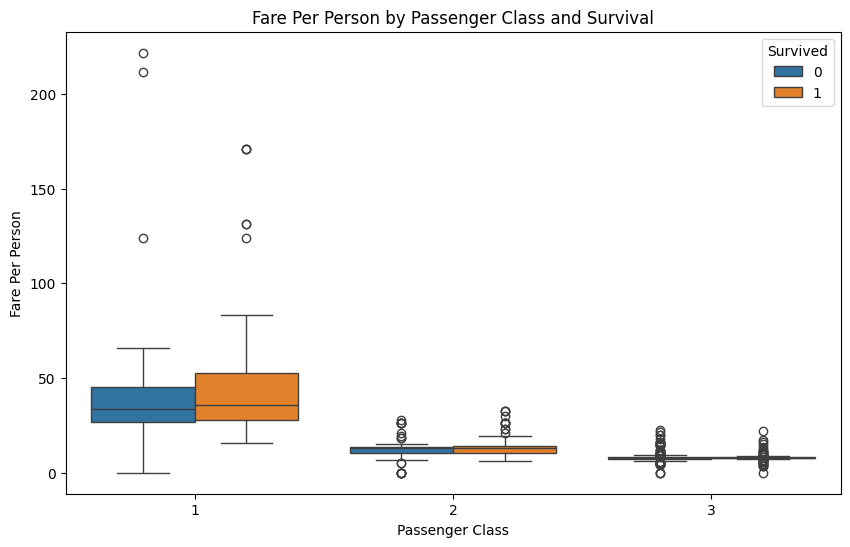

In [ ]:
# Fareperperson by Pclass

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=dataframe,
    x='Pclass',
    y='FarePerPerson',
    hue='Survived'
)

plt.title('Fare Per Person by Passenger Class and Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Fare Per Person')

plt.show()

ithin each passenger class, does FarePerPerson provide additional information about survival?

In [ ]:
# create faregroup

dataframe['FareGroup'] = pd.qcut(
    dataframe['Fare'],
    q=4,
    labels=[
        'Low',
        'Medium-Low',
        'Medium-High',
        'High'
    ]
)

dataframe[['Fare', 'FareGroup']].head(10)

,Fare,FareGroup
0,7.2500,Low
1,71.2833,High
2,7.9250,Medium-Low
3,53.1000,High
4,8.0500,Medium-Low
5,8.4583,Medium-Low
6,51.8625,High
7,21.0750,Medium-High
8,11.1333,Medium-Low
9,30.0708,Medium-High


In [ ]:
dataframe['FareGroup'].value_counts()

,count
FareGroup,
Medium-Low,224
Low,223
Medium-High,222
High,222


In [ ]:
dataframe['FareGroup'].value_counts().sort_index()

,count
FareGroup,
Low,223
Medium-Low,224
Medium-High,222
High,222


In [ ]:
# faregroup and survival

faregroup_survival = (
    dataframe
    .groupby('FareGroup', observed=True)['Survived']
    .agg(['count', 'mean'])
    .reset_index()
)

faregroup_survival['mean'] *= 100

faregroup_survival

,FareGroup,count,mean
0,Low,223,19.730942
1,Medium-Low,224,30.357143
2,Medium-High,222,45.495495
3,High,222,58.108108


In [ ]:
faregroup_survival.rename(
    columns={
        'count': 'PassengerCount',
        'mean': 'SurvivalRate'
    },
    inplace=True
)

faregroup_survival

,FareGroup,PassengerCount,SurvivalRate
0,Low,223,19.730942
1,Medium-Low,224,30.357143
2,Medium-High,222,45.495495
3,High,222,58.108108


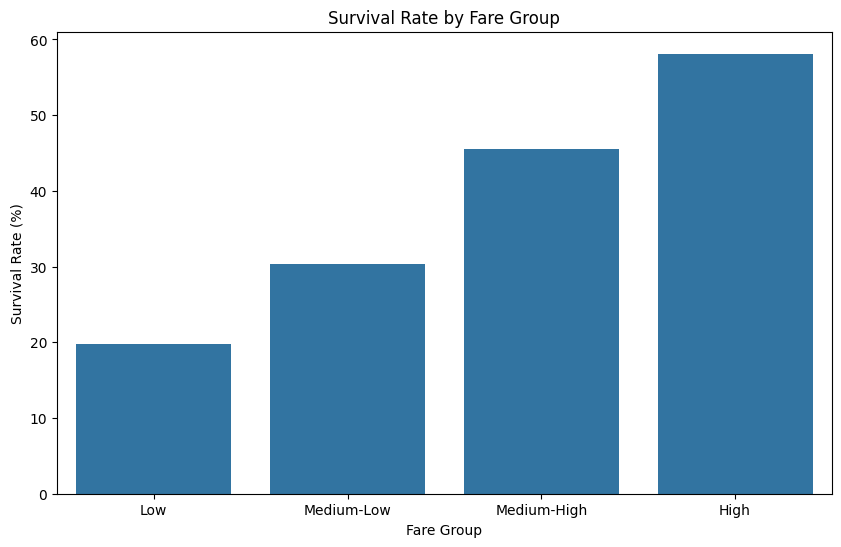

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=faregroup_survival,
    x='FareGroup',
    y='SurvivalRate'
)

plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate (%)')

plt.show()

# Faregroup + sex + survival

In [ ]:
faregroup_sex = (
    dataframe
    .groupby(
        ['FareGroup', 'Sex'],
        observed=True
    )['Survived']
    .mean()
    .reset_index()
)

faregroup_sex['Survived'] *= 100

faregroup_sex

,FareGroup,Sex,Survived
0,Low,female,69.767442
1,Low,male,7.777778
2,Medium-Low,female,64.179104
3,Medium-Low,male,15.923567
4,Medium-High,female,69.892473
5,Medium-High,male,27.906977
6,High,female,85.585586
7,High,male,30.630631


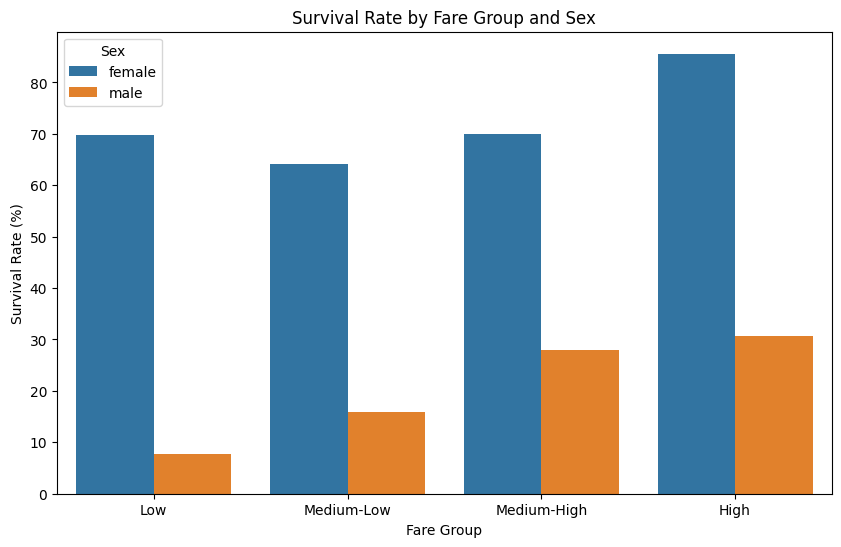

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=faregroup_sex,
    x='FareGroup',
    y='Survived',
    hue='Sex'
)

plt.title('Survival Rate by Fare Group and Sex')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate (%)')

plt.show()

# Faregroup + pclass + survival

In [ ]:
faregroup_class = (
    dataframe
    .groupby(
        ['FareGroup', 'Pclass'],
        observed=True
    )['Survived']
    .mean()
    .reset_index()
)

faregroup_class['Survived'] *= 100

faregroup_class

,FareGroup,Pclass,Survived
0,Low,1,0.000000
1,Low,2,0.000000
2,Low,3,20.853081
3,Medium-Low,2,38.372093
4,Medium-Low,3,25.362319
5,Medium-High,1,52.941176
6,Medium-High,2,60.000000
7,Medium-High,3,31.683168
8,High,1,68.553459
9,High,2,54.545455


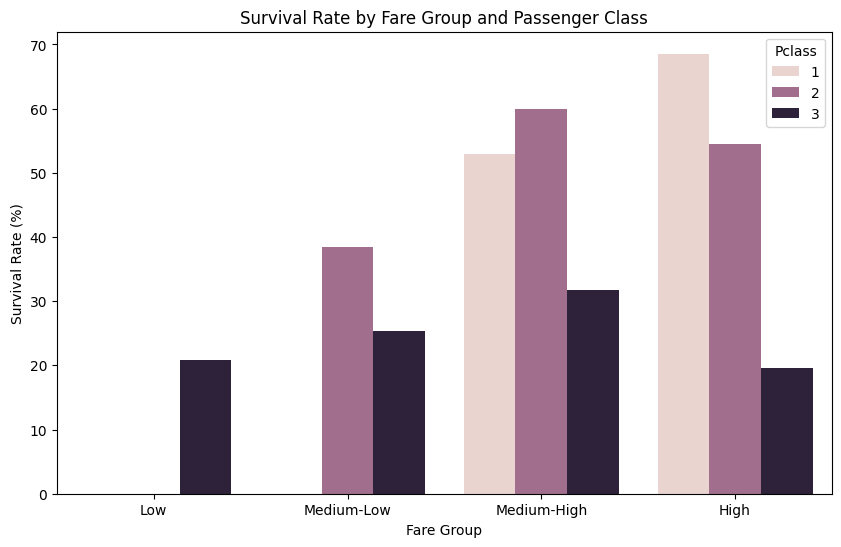

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=faregroup_class,
    x='FareGroup',
    y='Survived',
    hue='Pclass'
)

plt.title('Survival Rate by Fare Group and Passenger Class')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate (%)')

plt.show()

In [ ]:
fare_multivariate = (
    dataframe
    .groupby(
        ['FareGroup', 'Pclass', 'Sex'],
        observed=True
    )['Survived']
    .agg(['count', 'mean'])
    .reset_index()
)

fare_multivariate['mean'] *= 100

fare_multivariate.rename(
    columns={
        'count': 'PassengerCount',
        'mean': 'SurvivalRate'
    },
    inplace=True
)

fare_multivariate

,FareGroup,Pclass,Sex,PassengerCount,SurvivalRate
0,Low,1,male,6,0.000000
1,Low,2,male,6,0.000000
2,Low,3,female,43,69.767442
3,Low,3,male,168,8.333333
4,Medium-Low,2,female,29,89.655172
5,Medium-Low,2,male,57,12.280702
6,Medium-Low,3,female,38,44.736842
7,Medium-Low,3,male,100,18.000000
8,Medium-High,1,female,8,87.500000
9,Medium-High,1,male,43,46.511628


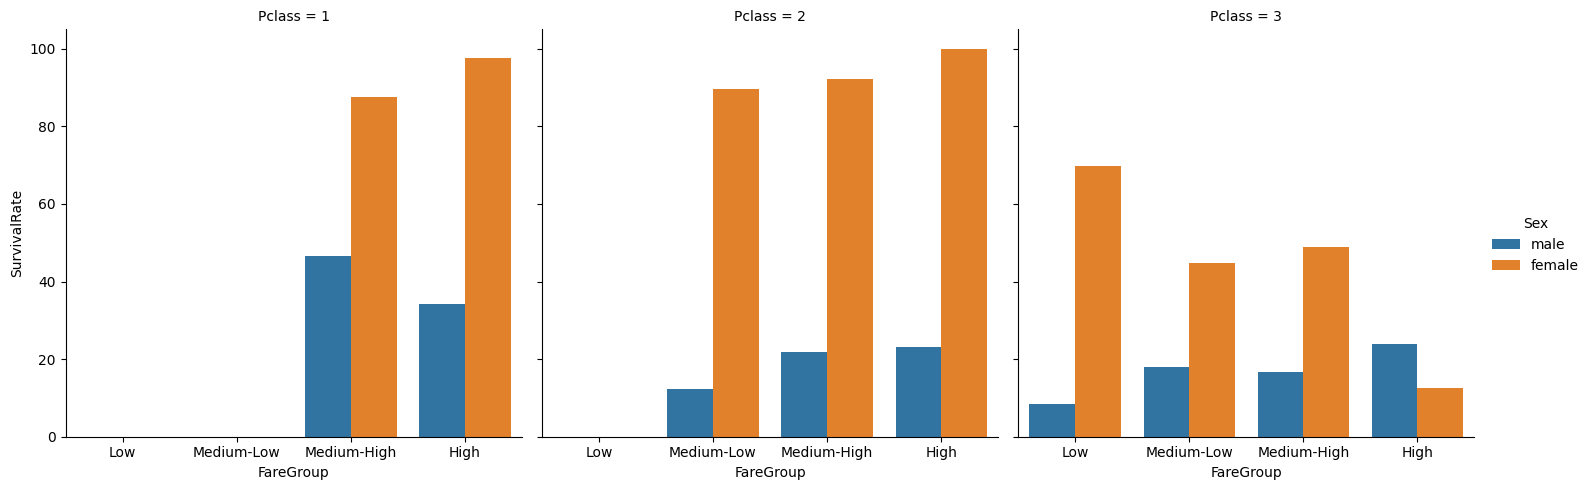

In [ ]:
sns.catplot(
    data=fare_multivariate,
    x='FareGroup',
    y='SurvivalRate',
    hue='Sex',
    col='Pclass',
    kind='bar',
    height=5,
    aspect=1
)

plt.show()

In [ ]:
dataframe.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,Deck,AgeGroup,TicketGroupSize,FarePerPerson,FareGroup
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Unknown,Young Adult,1,7.2500,Low
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,C,Adult,1,71.2833,High
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Unknown,Young Adult,1,7.9250,Medium-Low
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,C,Young Adult,2,26.5500,High
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Unknown,Young Adult,1,8.0500,Medium-Low


## Feature Engineering: Fare-Based Features

The original `Fare` variable was further investigated because multiple passengers could share the same ticket. First, `TicketGroupSize` was created to represent the number of passengers associated with each ticket.

Using `TicketGroupSize`, `FarePerPerson` was calculated as an approximate passenger-level representation of the ticket fare:

FarePerPerson = Fare / TicketGroupSize

In addition, `FareGroup` was created using quantile-based binning to divide passengers into four relative fare categories: Low, Medium-Low, Medium-High, and High.

These engineered features were analyzed against survival and other important variables such as `Pclass` and `Sex`. Their usefulness will ultimately be evaluated during model training rather than assuming that additional features automatically improve predictive performance.

In [ ]:
# separate features and target

X = dataframe.drop('Survived', axis=1)
y = dataframe['Survived']

In [ ]:
# check the features

X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,Deck,AgeGroup,TicketGroupSize,FarePerPerson,FareGroup
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Unknown,Young Adult,1,7.2500,Low
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,C,Adult,1,71.2833,High
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Unknown,Young Adult,1,7.9250,Medium-Low
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,C,Young Adult,2,26.5500,High
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Unknown,Young Adult,1,8.0500,Medium-Low


In [ ]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
dataframe.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Embarked,object


In [ ]:
numerical_features = [
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone',
    'TicketGroupSize',
    'FarePerPerson'
]

In [ ]:
# categorical_features = [
#     'Sex',
#     'Embarked',
#     'Title',
#     'Deck',
#     'FareGroup'


In [ ]:
categorical_features = [
    'Pclass',
    'Sex',
    'Embarked',
    'Title',
    'Deck',
    'FareGroup'
]

# Train/ Test split

In [ ]:
X = dataframe[
    numerical_features + categorical_features
]
y = dataframe['Survived']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# check the shapes

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)



print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 14)
Shape of y_train: (712,)
Shape of X_test: (179, 14)
Shape of y_test: (179,)


In [ ]:
print("Training survival distribution:")

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTesting survival distribution:")

print(
    y_test.value_counts(normalize=True) * 100
)

Training survival distribution:
Survived
0    61.657303
1    38.342697
Name: proportion, dtype: float64

Testing survival distribution:
Survived
0    61.452514
1    38.547486
Name: proportion, dtype: float64


# Preprocessing




In [ ]:
# numerical features preprocessing

numerical_imputer = SimpleImputer(
    strategy='median'
)

In [ ]:
numerical_scaler = StandardScaler()

In [ ]:
# create pipeline

numerical_pipeline = Pipeline(
    steps=[
        ('imputer', numerical_imputer),
        ('scaler', numerical_scaler)
    ]
)

In [ ]:
# test the numerical pipeline

X_train_numerical = numerical_pipeline.fit_transform(
    X_train[numerical_features]
)

X_train_numerical
#

array([[-0.08113533, -0.46508428, -0.46618317, ...,  0.80034555,
         3.82691799, -0.44865428],
       [-0.08113533, -0.46508428, -0.46618317, ...,  0.80034555,
        -0.57615059, -0.81994498],
       [-0.08113533, -0.46508428, -0.46618317, ...,  0.80034555,
        -0.57615059,  9.38279378],
       ...,
       [ 1.41700669,  0.47833454,  3.11571343, ..., -1.24946032,
         1.6253837 , -0.42459778],
       [ 1.34017889, -0.46508428, -0.46618317, ...,  0.80034555,
        -0.57615059,  0.95121048],
       [-0.08113533, -0.46508428, -0.46618317, ...,  0.80034555,
        -0.57615059,  0.40146223]])

In [ ]:
print(X_train_numerical.shape)

(712, 8)


In [ ]:
# Categorical Preprocessing


# create the categorical pipeline

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [ ]:
# test the categorical pipeline

X_train_categorical = categorical_pipeline.fit_transform(
    X_train[categorical_features]
)

X_train_categorical

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4272 stored elements and shape (712, 26)>

In [ ]:
print(X_train_categorical.shape)

(712, 26)


## preprocessing pipeline

In [ ]:
# create the preprocessor pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)

In [ ]:
# fit the preprocessor on training data

X_train_preprocessed = preprocessor.fit_transform(
    X_train
)

X_train_preprocessed

array([[-0.08113533, -0.46508428, -0.46618317, ...,  0.        ,
         0.        ,  0.        ],
       [-0.08113533, -0.46508428, -0.46618317, ...,  1.        ,
         0.        ,  0.        ],
       [-0.08113533, -0.46508428, -0.46618317, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.41700669,  0.47833454,  3.11571343, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.34017889, -0.46508428, -0.46618317, ...,  0.        ,
         0.        ,  0.        ],
       [-0.08113533, -0.46508428, -0.46618317, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
# transform the test data

X_test_preprocessed = preprocessor.transform(X_test)

X_test_preprocessed

array([[-0.42686041,  1.42175336, -0.46618317, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.10969551, -0.46508428,  0.72778236, ...,  0.        ,
         1.        ,  0.        ],
       [-0.58051601, -0.46508428, -0.46618317, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.11954923, -0.46508428, -0.46618317, ...,  0.        ,
         0.        ,  1.        ],
       [-0.50368821, -0.46508428, -0.46618317, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.11093416,  0.47833454,  0.72778236, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
# check the processoed data

print('Training shape:', X_train_preprocessed.shape)
print('Testing shape:', X_test_preprocessed.shape)

Training shape: (712, 34)
Testing shape: (179, 34)


In [ ]:
print("Training missing values:",
      np.isnan(X_train_preprocessed).sum())

print("Testing missing values:",
      np.isnan(X_test_preprocessed).sum())

Training missing values: 0
Testing missing values: 0


# 5. Machine Learning Modeling

## Target and Features

Target:

`Survived`

Features will include selected demographic, socioeconomic,
and engineered variables.

The `PassengerId` identifier will be excluded because it does
not represent meaningful passenger characteristics.

# Build ML pipeline

In [ ]:
# create the complete pipeline

model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]
)

# Test the pipeline

In [ ]:
model_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('classifier', LogisticRegression())])

# Make Predictions

In [ ]:
y_pred = model_pipeline.predict(X_test)

y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

# Prediction Probabilities

In [ ]:
y_pred_proba = model_pipeline.predict_proba(X_test)

y_pred_proba

array([[0.94272127, 0.05727873],
       [0.94057717, 0.05942283],
       [0.88167157, 0.11832843],
       [0.97808775, 0.02191225],
       [0.27017301, 0.72982699],
       [0.33193439, 0.66806561],
       [0.31728122, 0.68271878],
       [0.52480895, 0.47519105],
       [0.69309803, 0.30690197],
       [0.87172535, 0.12827465],
       [0.87488413, 0.12511587],
       [0.92747029, 0.07252971],
       [0.40125318, 0.59874682],
       [0.80744383, 0.19255617],
       [0.70272553, 0.29727447],
       [0.86196737, 0.13803263],
       [0.78032031, 0.21967969],
       [0.91604824, 0.08395176],
       [0.90589824, 0.09410176],
       [0.30345434, 0.69654566],
       [0.91604824, 0.08395176],
       [0.33778892, 0.66221108],
       [0.91970033, 0.08029967],
       [0.40740284, 0.59259716],
       [0.93448142, 0.06551858],
       [0.02085649, 0.97914351],
       [0.70679548, 0.29320452],
       [0.74278441, 0.25721559],
       [0.90372943, 0.09627057],
       [0.82870774, 0.17129226],
       [0.

In [ ]:
y_pred_probability = model_pipeline.predict_proba(

    X_test

)[:, 1]

y_pred_probability

array([0.05727873, 0.05942283, 0.11832843, 0.02191225, 0.72982699,
       0.66806561, 0.68271878, 0.47519105, 0.30690197, 0.12827465,
       0.12511587, 0.07252971, 0.59874682, 0.19255617, 0.29727447,
       0.13803263, 0.21967969, 0.08395176, 0.09410176, 0.69654566,
       0.08395176, 0.66221108, 0.08029967, 0.59259716, 0.06551858,
       0.97914351, 0.29320452, 0.25721559, 0.09627057, 0.17129226,
       0.07125973, 0.96104178, 0.53218947, 0.18818853, 0.58444865,
       0.4752105 , 0.60120855, 0.11278471, 0.12511587, 0.67026573,
       0.21606833, 0.94701084, 0.08611208, 0.80190972, 0.77122825,
       0.10464584, 0.08314326, 0.53818211, 0.62891926, 0.84031793,
       0.91250338, 0.586831  , 0.68927571, 0.15031487, 0.81686546,
       0.09037481, 0.08001702, 0.57296374, 0.58494773, 0.19836808,
       0.79924662, 0.67111307, 0.09647848, 0.13526898, 0.34751627,
       0.53186541, 0.92778066, 0.0727123 , 0.41016572, 0.16983933,
       0.88945467, 0.09811645, 0.53928869, 0.95924594, 0.13328

# Xheck accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Accuracy:", accuracy)

Accuracy: 0.8379888268156425


# Classification report

In [ ]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



# ROC - AUC

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(

    y_test,

    y_pred_probability

)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8625823451910408


# Baseline Model

In [ ]:
from sklearn.dummy import DummyClassifier

In [ ]:
# create the baseline pipeline

baseline_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DummyClassifier(strategy='most_frequent'))
    ]
)

In [ ]:
# train hte baseline

baseline_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

In [ ]:
# make predictions

y_pred_baseline = baseline_pipeline.predict(X_test)

y_pred_baseline

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [ ]:
# calculate accuracy

accuracy_baseline = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Accuracy:", accuracy_baseline)

Accuracy: 0.6145251396648045


In [ ]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred
)

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

print("Logistic Regression Accuracy:", logistic_accuracy)

Baseline Accuracy: 0.6145251396648045
Logistic Regression Accuracy: 0.8379888268156425


In [ ]:
# create a comparision table

model_comparison = pd.DataFrame({

    'Model': [
        'Dummy Classifier',
        'Logistic Regression'
    ],

    'Accuracy': [
        baseline_accuracy,
        logistic_accuracy
    ]

})

model_comparison

,Model,Accuracy
0,Dummy Classifier,0.614525
1,Logistic Regression,0.837989


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# create the decision tree pipeline

# # decision_tree_pipeline = Pipeline(
#     steps=[
#         ('preprocessor', preprocessor),
#         ('classifier', DecisionTreeClassifier())
#     ]
# )

In [ ]:
decision_tree_pipeline = Pipeline(

    steps=[

        (
            'preprocessor',
            preprocessor
        ),

        (
            'model',
            DecisionTreeClassifier(
                random_state=42
            )
        )

    ]

)

In [ ]:
# train the model

decision_tree_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
# make predictions

y_pred_decision_tree = decision_tree_pipeline.predict(X_test)

y_pred_decision_tree

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1])

In [ ]:
# calculate accuracy

accuracy_decision_tree = accuracy_score(
    y_test,
    y_pred_decision_tree
)

print("Accuracy:", accuracy_decision_tree)

Accuracy: 0.776536312849162


In [ ]:
# calculate ROC_AUC

roc_auc_decision_tree = roc_auc_score(
    y_test,
    y_pred_decision_tree
)

print("ROC-AUC:", roc_auc_decision_tree)

ROC-AUC: 0.756060606060606


In [ ]:
decision_tree_probability = (

    decision_tree_pipeline
    .predict_proba(X_test)[:, 1]

)

In [ ]:
decision_tree_roc_auc = roc_auc_score(

    y_test,

    decision_tree_probability

)

print(
    "Decision Tree ROC-AUC:",
    decision_tree_roc_auc
)

Decision Tree ROC-AUC: 0.745125164690382


In [ ]:
model_comparison = pd.DataFrame({

    'Model': [

        'Dummy Classifier',
        'Logistic Regression',
        'Decision Tree'

    ],

    'Accuracy': [

        baseline_accuracy,
        logistic_accuracy,
        accuracy_decision_tree

    ],

    'ROC-AUC': [

        np.nan,
        roc_auc,
        decision_tree_roc_auc

    ]

})

model_comparison

,Model,Accuracy,ROC-AUC
0,Dummy Classifier,0.614525,NaN
1,Logistic Regression,0.837989,0.862582
2,Decision Tree,0.776536,0.745125


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# create the random forest pipeline

random_forest_pipeline = Pipeline(

    steps=[

        (
            'preprocessor',
            preprocessor
        ),

        (
            'model',
            RandomForestClassifier(
                random_state=42
            )
        )

    ]

)


In [ ]:
# train the model

random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
# make predictions

y_pred_random_forest = random_forest_pipeline.predict(X_test)

y_pred_random_forest

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [ ]:
# calculate accuracy

accuracy_random_forest = accuracy_score(
    y_test,
    y_pred_random_forest
)

print("Accuracy:", accuracy_random_forest)

Accuracy: 0.770949720670391


In [ ]:
# calculate the ROC_AUC

random_forest_probability = (

    random_forest_pipeline
    .predict_proba(X_test)[:, 1]

)

In [ ]:
random_forest_roc_auc = roc_auc_score(

    y_test,

    random_forest_probability

)

print(
    "Random Forest ROC-AUC:",
    random_forest_roc_auc
)

Random Forest ROC-AUC: 0.8130434782608696


In [ ]:
model_comparison = pd.DataFrame({

    'Model': [

        'Dummy Classifier',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'

    ],

    'Accuracy': [

        baseline_accuracy,
        logistic_accuracy,
        accuracy_decision_tree,
        accuracy_random_forest

    ],

    'ROC-AUC': [

        np.nan,
        roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc

    ]

})

model_comparison

,Model,Accuracy,ROC-AUC
0,Dummy Classifier,0.614525,NaN
1,Logistic Regression,0.837989,0.862582
2,Decision Tree,0.776536,0.745125
3,Random Forest,0.770950,0.813043


# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# creaate the pipeline

gradient_boosting_pipeline = Pipeline(

    steps=[

        (
            'preprocessor',
            preprocessor
        ),

        (
            'model',
            GradientBoostingClassifier(
                random_state=42
            )
        )

    ]

)

In [ ]:
# train the model

gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [ ]:
# make predictions

y_pred_gradient_boosting = gradient_boosting_pipeline.predict(X_test)

y_pred_gradient_boosting

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [ ]:
# calculate accuracy

accuracy_gradient_boosting = accuracy_score(
    y_test,
    y_pred_gradient_boosting
)

print("Accuracy:", accuracy_gradient_boosting)

Accuracy: 0.7988826815642458


In [ ]:
# calculate the ROC_AUC

gradient_boosting_probability = (

    gradient_boosting_pipeline
    .predict_proba(X_test)[:, 1]

)

In [ ]:
gradient_boosting_roc_auc = roc_auc_score(

    y_test,

    gradient_boosting_probability

)

print(
    "Gradient Boosting ROC-AUC:",
    gradient_boosting_roc_auc
)

Gradient Boosting ROC-AUC: 0.846179183135705


In [ ]:
# campare the model

model_comparison = pd.DataFrame({

    'Model': [

        'Dummy Classifier',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'

    ],

    'Accuracy': [

        baseline_accuracy,
        logistic_accuracy,
        accuracy_decision_tree,
        accuracy_random_forest,
        accuracy_gradient_boosting

    ],

    'ROC-AUC': [

        np.nan,
        roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        gradient_boosting_roc_auc

    ]

})

model_comparison

,Model,Accuracy,ROC-AUC
0,Dummy Classifier,0.614525,NaN
1,Logistic Regression,0.837989,0.862582
2,Decision Tree,0.776536,0.745125
3,Random Forest,0.770950,0.813043
4,Gradient Boosting,0.798883,0.846179


# Model Comparision

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
# logistic regression

logistic_metrics = {

    'Model': 'Logistic Regression',

    'Accuracy': accuracy_score(
        y_test,
        y_pred
    ),

    'Precision': precision_score(
        y_test,
        y_pred
    ),

    'Recall': recall_score(
        y_test,
        y_pred
    ),

    'F1': f1_score(
        y_test,
        y_pred
    ),

    'ROC-AUC': roc_auc_score(
        y_test,
        y_pred_probability
    )

}
model_comparison = pd.DataFrame([logistic_metrics])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.80303,0.768116,0.785185,0.862582


In [ ]:
# Decision Tree

decision_tree_metrics = {

    'Model': 'Decision Tree',

    'Accuracy': accuracy_score(
        y_test,
        y_pred_decision_tree
    ),

    'Precision': precision_score(
        y_test,
        y_pred_decision_tree
    ),

    'Recall': recall_score(
        y_test,
        y_pred_decision_tree
    ),

    'F1': f1_score(
        y_test,
        y_pred_decision_tree
    ),

    'ROC-AUC': roc_auc_score(
        y_test,
        decision_tree_probability
    )

}

model_comparison = pd.DataFrame([logistic_metrics])

model_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([decision_tree_metrics])
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125


In [ ]:
# Random Forest

random_forest_metrics = {

    'Model': 'Random Forest',

    'Accuracy': accuracy_score(
        y_test,
        y_pred_random_forest
    ),

    'Precision': precision_score(
        y_test,
        y_pred_random_forest
    ),

    'Recall': recall_score(
        y_test,
        y_pred_random_forest
    ),

    'F1': f1_score(
        y_test,
        y_pred_random_forest
    ),

    'ROC-AUC': roc_auc_score(
        y_test,
        random_forest_probability
    )

}

model_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([random_forest_metrics]),
        pd.DataFrame([decision_tree_metrics])
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
2,Random Forest,0.770950,0.718750,0.666667,0.691729,0.813043
3,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125


In [ ]:
# Gradient Boosting

gradient_boosting_metrics = {

    'Model': 'Gradient Boosting',

    'Accuracy': accuracy_score(
        y_test,
        y_pred_gradient_boosting
    ),

    'Precision': precision_score(
        y_test,
        y_pred_gradient_boosting
    ),

    'Recall': recall_score(
        y_test,
        y_pred_gradient_boosting
    ),

    'F1': f1_score(
        y_test,
        y_pred_gradient_boosting
    ),

    'ROC-AUC': roc_auc_score(
        y_test,
        gradient_boosting_probability
    )

}

model_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([gradient_boosting_metrics])
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
2,Random Forest,0.770950,0.718750,0.666667,0.691729,0.813043
3,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
4,Gradient Boosting,0.798883,0.770492,0.681159,0.723077,0.846179


# Sort by ROC_AUC

In [ ]:
model_comparison.sort_values(

    by='ROC-AUC',

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
4,Gradient Boosting,0.798883,0.770492,0.681159,0.723077,0.846179
2,Random Forest,0.770950,0.718750,0.666667,0.691729,0.813043
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
3,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125


In [ ]:
model_comparison.sort_values(

    by='F1',

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
4,Gradient Boosting,0.798883,0.770492,0.681159,0.723077,0.846179
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
3,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
2,Random Forest,0.770950,0.718750,0.666667,0.691729,0.813043


# VIsualize model performance

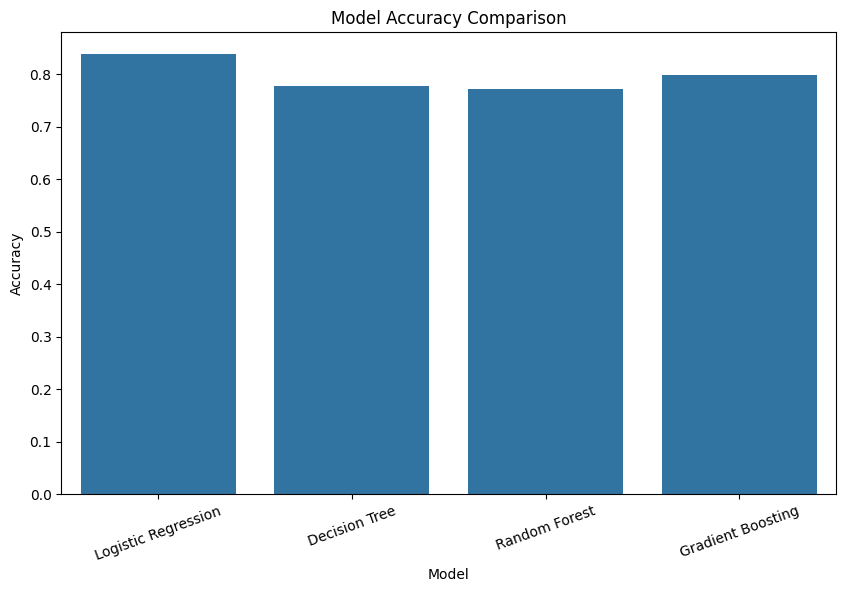

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(

    data=model_comparison,

    x='Model',

    y='Accuracy'

)

plt.xticks(rotation=20)

plt.title('Model Accuracy Comparison')

plt.xlabel('Model')

plt.ylabel('Accuracy')

plt.show()

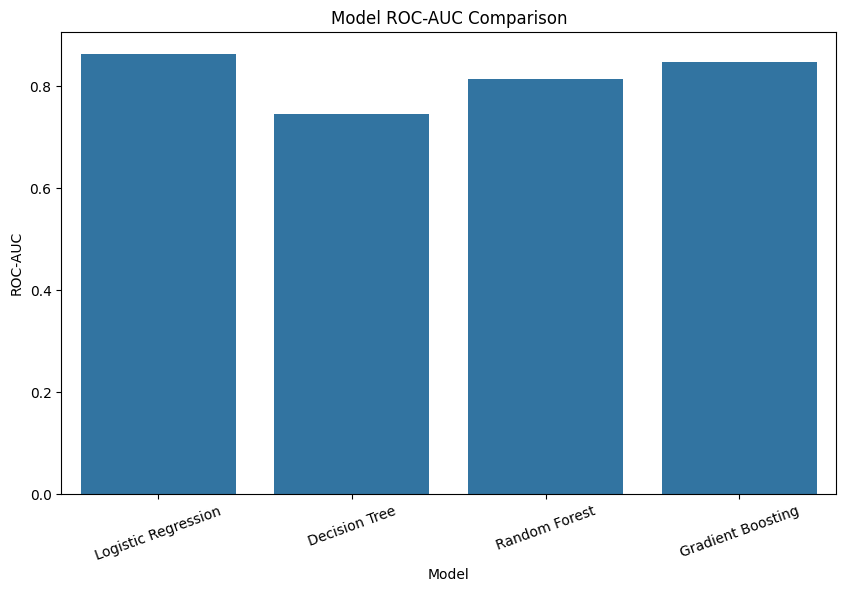

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(

    data=model_comparison,

    x='Model',

    y='ROC-AUC'

)

plt.xticks(rotation=20)

plt.title('Model ROC-AUC Comparison')

plt.xlabel('Model')

plt.ylabel('ROC-AUC')

plt.show()

# 🧠 How to interpret the metrics
Accuracy

Out of all passengers, how many did the model classify correctly?

Precision

When the model predicts Survived, how often is it correct?

Recall

Of the passengers who actually survived, how many did the model successfully identify?

F1-score

Balances:

Precision + Recall
ROC-AUC

Measures how well the model distinguishes:

Survived = 1
       vs
Not Survived = 0

A higher value is generally better.

# Cross Validation

Does the model consistently perform well on different subsets of the training data?

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
# cross validate logistic regression


logistic_cv_scores = cross_val_score(

    model_pipeline,

    X_train,

    y_train,

    cv=5,

    scoring='accuracy'

)

In [ ]:
print("Logistic Regression Cross-Validation Scores:", logistic_cv_scores)

Logistic Regression Cross-Validation Scores: [0.79020979 0.8041958  0.85211268 0.83802817 0.82394366]


In [ ]:
print("Mean Accuracy:", logistic_cv_scores.mean())

Mean Accuracy: 0.8216980202895694


In [ ]:
# calculate the standard deviation


print("Standard Deviation:", logistic_cv_scores.std())

Standard Deviation: 0.02233653577030641


In [ ]:
# cross-validate all models

models = {

    'Logistic Regression':
        model_pipeline,

    'Decision Tree':
        decision_tree_pipeline,

    'Random Forest':
        random_forest_pipeline,

    'Gradient Boosting':
        gradient_boosting_pipeline

}

In [ ]:
cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(

        model,

        X_train,

        y_train,

        cv=5,

        scoring='accuracy'

    )

    cv_results.append({

        'Model': model_name,

        'Mean CV Accuracy': scores.mean(),

        'CV Std': scores.std()

    })

In [ ]:
# create the cv result table


cv_comparison = pd.DataFrame(

    cv_results

)

cv_comparison.sort_values(

    by='Mean CV Accuracy',

    ascending=False

)

,Model,Mean CV Accuracy,CV Std
3,Gradient Boosting,0.823116,0.024252
0,Logistic Regression,0.821698,0.022337
2,Random Forest,0.796444,0.030729
1,Decision Tree,0.750084,0.031482


In [ ]:
# try different metrics also

f1_scores = cross_val_score(

    random_forest_pipeline,

    X_train,

    y_train,

    cv=5,

    scoring='f1'

)

print("F1 Scores:", f1_scores)

print("Mean F1:", f1_scores.mean())

F1 Scores: [0.7037037  0.65384615 0.78181818 0.75438596 0.76635514]
Mean F1: 0.7320218288934471


In [ ]:
roc_auc_scores = cross_val_score(

    random_forest_pipeline,

    X_train,

    y_train,

    cv=5,

    scoring='roc_auc'

)

print("ROC-AUC Scores:", roc_auc_scores)

print("Mean ROC-AUC:", roc_auc_scores.mean())

ROC-AUC Scores: [0.83977273 0.81756198 0.88725183 0.89457071 0.86879209]
Mean ROC-AUC: 0.861589866797547


# Hyperparameters Tunning

A hyperparameter is a setting that we choose before training the model.

"Can we make our model perform better by choosing better settings?"

In [ ]:
models = {

    'Logistic Regression':
        model_pipeline,

    'Decision Tree':
        decision_tree_pipeline,

    'Random Forest':
        random_forest_pipeline,

    'Gradient Boosting':
        gradient_boosting_pipeline

}

## Logistic Regression

In [ ]:
logistic_param_grid = {

    'classifier__C': [

        0.01,
        0.1,
        1,
        10,
        100

    ],

    'classifier__solver': [

        'liblinear',
        'lbfgs'

    ]

}

In [ ]:
# tune logistic regression


from sklearn.model_selection import GridSearchCV

logistic_grid_search = GridSearchCV(

    estimator=model_pipeline,

    param_grid=logistic_param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1

)

In [ ]:
logistic_grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'TicketGroupSize',
                                                                          'FarePerPerson']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'Deck',
                                                                          'FareGroup'])])),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc', verbose=1)

In [ ]:
print(

    "Best Logistic Regression Parameters:"

)

print(

    logistic_grid_search.best_params_

)

Best Logistic Regression Parameters:
{'classifier__C': 0.1, 'classifier__solver': 'liblinear'}


In [ ]:
print(

    "Best Logistic Regression CV ROC-AUC:",

    logistic_grid_search.best_score_

)

Best Logistic Regression CV ROC-AUC: 0.863525695829771


## Decision Tree

In [ ]:
decision_tree_param_grid = {

    'model__max_depth': [

        None,
        3,
        5,
        10,
        15

    ],

    'model__min_samples_split': [

        2,
        5,
        10

    ],

    'model__min_samples_leaf': [

        1,
        2,
        4

    ],

    'model__max_features': [

        'sqrt',
        'log2',
        None

    ]

}

In [ ]:
decision_tree_grid_search = GridSearchCV(

    estimator=decision_tree_pipeline,

    param_grid=decision_tree_param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1

)

In [ ]:
decision_tree_grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'TicketGroupSize',
                                                                          'FarePerPerson']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy=...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'Deck',
                                                                          'FareGroup'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 3, 5, 10, 15],
                         'model__max_features': ['sqrt', 'log2', None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='roc_auc', verbose=1)

In [ ]:
print(

    "Best Decision Tree Parameters:"

)

print(

    decision_tree_grid_search.best_params_

)

Best Decision Tree Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}


In [ ]:
print(

    "Best Decision Tree CV ROC-AUC:",

    decision_tree_grid_search.best_score_

)

Best Decision Tree CV ROC-AUC: 0.8643412178208416


## Random Forest

In [ ]:
random_forest_param_grid = {

    'model__n_estimators': [

        100,
        200

    ],

    'model__max_depth': [

        None,
        5,
        10

    ],

    'model__min_samples_split': [

        2,
        5

    ],

    'model__min_samples_leaf': [

        1,
        2

    ],

    'model__max_features': [

        'sqrt',
        'log2'

    ]

}

In [ ]:
random_forest_grid_search = GridSearchCV(

    estimator=random_forest_pipeline,

    param_grid=random_forest_param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1

)

In [ ]:
random_forest_grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'TicketGroupSize',
                                                                          'FarePerPerson']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy=...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'Deck',
                                                                          'FareGroup'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
print(

    "Best Random Forest Parameters:"

)

print(

    random_forest_grid_search.best_params_

)

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
print(

    "Best Random Forest CV ROC-AUC:",

    random_forest_grid_search.best_score_

)

Best Random Forest CV ROC-AUC: 0.8822914093917229


## Gradient Boosting

In [ ]:
gradient_boosting_param_grid = {

    'model__n_estimators': [

        100,
        200

    ],

    'model__learning_rate': [

        0.01,
        0.05,
        0.1

    ],

    'model__max_depth': [

        2,
        3,
        5

    ],

    'model__min_samples_split': [

        2,
        5

    ],

    'model__min_samples_leaf': [

        1,
        2

    ]

}

In [ ]:
gradient_boosting_grid_search = GridSearchCV(

    estimator=gradient_boosting_pipeline,

    param_grid=gradient_boosting_param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=1

)

In [ ]:
gradient_boosting_grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'FamilySize',
                                                                          'IsAlone',
                                                                          'TicketGroupSize',
                                                                          'FarePerPerson']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy=...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'Deck',
                                                                          'FareGroup'])])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [2, 3, 5],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
print(

    "Best Gradient Boosting Parameters:"

)

print(

    gradient_boosting_grid_search.best_params_

)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [ ]:
print(

    "Best Gradient Boosting CV ROC-AUC:",

    gradient_boosting_grid_search.best_score_

)

Best Gradient Boosting CV ROC-AUC: 0.8922001361578165


## Tuned Model Comparison

In [ ]:
tuned_models = {

    'Logistic Regression':
        logistic_grid_search,

    'Decision Tree':
        decision_tree_grid_search,

    'Random Forest':
        random_forest_grid_search,

    'Gradient Boosting':
        gradient_boosting_grid_search

}

In [ ]:
tuned_results = []

for model_name, grid_search in tuned_models.items():

    tuned_results.append({

        'Model':
            model_name,

        'Best CV ROC-AUC':
            grid_search.best_score_,

        'Best Parameters':
            grid_search.best_params_

    })

tuned_comparison = pd.DataFrame(

    tuned_results

)

tuned_comparison = tuned_comparison.sort_values(

    by='Best CV ROC-AUC',

    ascending=False

)

tuned_comparison

,Model,Best CV ROC-AUC,Best Parameters
3,Gradient Boosting,0.892200,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,Random Forest,0.882291,"{'model__max_depth': 10, 'model__max_features'..."
1,Decision Tree,0.864341,"{'model__max_depth': 5, 'model__max_features':..."
0,Logistic Regression,0.863526,"{'classifier__C': 0.1, 'classifier__solver': '..."


## Best estimator from each search

In [ ]:
best_logistic_model = (

    logistic_grid_search.best_estimator_

)

best_decision_tree_model = (

    decision_tree_grid_search.best_estimator_

)

best_random_forest_model = (

    random_forest_grid_search.best_estimator_

)

best_gradient_boosting_model = (

    gradient_boosting_grid_search.best_estimator_

)

## Evaluate all tuned models on test data

In [ ]:
tuned_predictions = {

    'Logistic Regression':
        best_logistic_model.predict(X_test),

    'Decision Tree':
        best_decision_tree_model.predict(X_test),

    'Random Forest':
        best_random_forest_model.predict(X_test),

    'Gradient Boosting':
        best_gradient_boosting_model.predict(X_test)

}

In [ ]:
tuned_probabilities = {

    'Logistic Regression':
        best_logistic_model.predict_proba(
            X_test
        )[:, 1],

    'Decision Tree':
        best_decision_tree_model.predict_proba(
            X_test
        )[:, 1],

    'Random Forest':
        best_random_forest_model.predict_proba(
            X_test
        )[:, 1],

    'Gradient Boosting':
        best_gradient_boosting_model.predict_proba(
            X_test
        )[:, 1]

}

### Final Tuned Comparison

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = []

for model_name in tuned_predictions:

    y_prediction = (

        tuned_predictions[model_name]

    )

    y_probability = (

        tuned_probabilities[model_name]

    )

    final_results.append({

        'Model':
            model_name,

        'Accuracy':
            accuracy_score(
                y_test,
                y_prediction
            ),

        'Precision':
            precision_score(
                y_test,
                y_prediction
            ),

        'Recall':
            recall_score(
                y_test,
                y_prediction
            ),

        'F1-Score':
            f1_score(
                y_test,
                y_prediction
            ),

        'ROC-AUC':
            roc_auc_score(
                y_test,
                y_probability
            )

    })

final_model_comparison = pd.DataFrame(

    final_results

)

final_model_comparison.sort_values(

    by='ROC-AUC',

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.821229,0.803279,0.710145,0.753846,0.864163
2,Random Forest,0.787709,0.754098,0.666667,0.707692,0.835837
1,Decision Tree,0.782123,0.682927,0.811594,0.741722,0.835573
3,Gradient Boosting,0.815642,0.772727,0.739130,0.755556,0.828722


#### Decision Process

                    4 Models
                       ↓
             Cross-Validation
                       ↓
             Hyperparameter Tuning
                       ↓
             ┌─────────┴─────────┐
             ↓         ↓         ↓
          Logistic   Tree       Forest
             ↓         ↓         ↓
             └─────────┬─────────┘
                       ↓
                 Compare CV
                       ↓
             Evaluate on Test Set
                       ↓
        ┌──────────────┴──────────────┐
        ↓              ↓              ↓
    Accuracy        F1-score       ROC-AUC
        │              │              │
        └──────────────┼──────────────┘
                       ↓
                Model Selection

                    PRE-TUNING
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
 Logistic          Decision         Random
 Regression          Tree            Forest
       │               │               │
       └───────────────┼───────────────┘
                       ↓
                Gradient Boosting
                       │
                       ↓
                Current comparison
                       │
                       ▼
              HYPERPARAMETER TUNING
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
 Logistic          Decision         Random
 Regression          Tree            Forest
       │               │               │
       └───────────────┼───────────────┘
                       ↓
                Gradient Boosting
                       │
                       ▼
               Tuned comparison
                       │
                       ▼
             Select final candidate
                       │
                       ▼
             Final test evaluation

In [ ]:
pre_tuning_results = model_comparison.copy()

pre_tuning_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185,0.862582
1,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
2,Random Forest,0.770950,0.718750,0.666667,0.691729,0.813043
3,Decision Tree,0.776536,0.730159,0.666667,0.696970,0.745125
4,Gradient Boosting,0.798883,0.770492,0.681159,0.723077,0.846179


In [ ]:
after_tuning_result = final_model_comparison.copy()

after_tuning_result
#

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.821229,0.803279,0.710145,0.753846,0.864163
1,Decision Tree,0.782123,0.682927,0.811594,0.741722,0.835573
2,Random Forest,0.787709,0.754098,0.666667,0.707692,0.835837
3,Gradient Boosting,0.815642,0.772727,0.739130,0.755556,0.828722


Hyperparameter tuning searches for parameters that perform well according to the metric and cross-validation data used during the search.

The resulting model can sometimes perform worse on a particular unseen test split.

In [ ]:
print(
    "Logistic Regression:",
    logistic_grid_search.best_score_
)

print(
    "Decision Tree:",
    decision_tree_grid_search.best_score_
)

print(
    "Random Forest:",
    random_forest_grid_search.best_score_
)

print(
    "Gradient Boosting:",
    gradient_boosting_grid_search.best_score_
)

Logistic Regression: 0.863525695829771
Decision Tree: 0.8643412178208416
Random Forest: 0.8822914093917229
Gradient Boosting: 0.8922001361578165


# Error Analysis

Now we move from “Which model performs best?” to “Where does the model make mistakes?”

## LOgistic Regression

In [ ]:
logistic_test_predictions = best_logistic_model.predict(
    X_test
)

logistic_test_predictions

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix


logistic_cm = confusion_matrix(
    y_test,
    logistic_test_predictions
)

logistic_cm


array([[98, 12],
       [20, 49]])

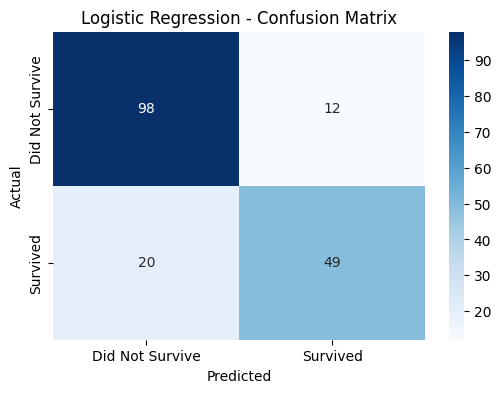

In [ ]:
# visualize it


plt.figure(figsize=(6, 4))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')

plt.show()

In [ ]:
tn, fp, fn, tp = logistic_cm.ravel()

In [ ]:
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 98
False Positives: 12
False Negatives: 20
True Positives: 49


True Negative (TN)

Model predicted the passenger did not survive, and they actually did not survive.

False Positive (FP)

Model predicted the passenger survived, but they actually died.

False Negative (FN)

Model predicted the passenger did not survive, but they actually survived.

True Positive (TP)

Model predicted the passenger survived, and they actually survive

Recall = 71.01%

This means the model successfully identifies about 71% of the passengers who actually survived.

So we should pay particular attention to the False Negatives.

In other words:

Which passengers actually survived but our model predicted would die?

### Tables of mistakes

In [ ]:
error_analysis = X_test.copy()

In [ ]:
error_analysis['Actual'] = y_test

In [ ]:
error_analysis['Predicted'] = (
    logistic_test_predictions
)

In [ ]:
# identify inconcorrect predictions


errors = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
]

In [ ]:
errors.head(10)

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted
553,22.0,0,0,7.2250,1,1,1,7.225000,3,male,C,Mr,Unknown,Low,1,0
712,48.0,1,0,52.0000,2,0,2,26.000000,1,male,S,Mr,C,High,1,0
455,29.0,0,0,7.8958,1,1,1,7.895800,3,male,C,Mr,Unknown,Low,1,0
65,NaN,1,1,15.2458,3,0,2,7.622900,3,male,C,Master,Unknown,Medium-High,1,0
489,9.0,1,1,15.9000,3,0,2,7.950000,3,male,S,Master,Unknown,Medium-High,1,0
869,4.0,1,1,11.1333,3,0,3,3.711100,3,male,S,Master,Unknown,Medium-Low,1,0
165,9.0,0,2,20.5250,3,0,3,6.841667,3,male,S,Master,Unknown,Medium-High,1,0
297,2.0,1,2,151.5500,4,0,4,37.887500,1,female,S,Miss,C,High,0,1
40,40.0,1,0,9.4750,2,0,1,9.475000,3,female,S,Mrs,Unknown,Medium-Low,0,1
564,NaN,0,0,8.0500,1,1,1,8.050000,3,female,S,Miss,Unknown,Medium-Low,0,1


In [ ]:
# check how many mistakes were made


print(
    "Total incorrect predictions:",
    len(errors)
)

Total incorrect predictions: 32


#### separatte false positive and false negatives

#### False Positives

Passengers predicted to survive but actually died:

In [ ]:
false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

false_positives.head()

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted
297,2.0,1,2,151.5500,4,0,4,37.8875,1,female,S,Miss,C,High,0,1
40,40.0,1,0,9.4750,2,0,1,9.4750,3,female,S,Mrs,Unknown,Medium-Low,0,1
564,NaN,0,0,8.0500,1,1,1,8.0500,3,female,S,Miss,Unknown,Medium-Low,0,1
502,NaN,0,0,7.6292,1,1,1,7.6292,3,female,Q,Miss,Unknown,Low,0,1
578,NaN,1,0,14.4583,2,0,1,14.4583,3,female,C,Mrs,Unknown,Medium-High,0,1


#### False Negatives

Passengers predicted not to survive but actually survived:

In [ ]:
false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

false_negatives.head()

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted
553,22.0,0,0,7.2250,1,1,1,7.2250,3,male,C,Mr,Unknown,Low,1,0
712,48.0,1,0,52.0000,2,0,2,26.0000,1,male,S,Mr,C,High,1,0
455,29.0,0,0,7.8958,1,1,1,7.8958,3,male,C,Mr,Unknown,Low,1,0
65,NaN,1,1,15.2458,3,0,2,7.6229,3,male,C,Master,Unknown,Medium-High,1,0
489,9.0,1,1,15.9000,3,0,2,7.9500,3,male,S,Master,Unknown,Medium-High,1,0


In [ ]:
# check their counts

print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)

False Positives: 12
False Negatives: 20


The model achieved 82.12% accuracy and 86.42% ROC-AUC. Error analysis showed that the model's mistakes were particularly associated with passengers whose characteristics made survival difficult to distinguish.

Then we can investigate exactly which characteristics are associated with those mistakes.

## Finding why the model makes *mistakes*

The key question is:

What characteristics do incorrectly predicted passengers have?

In [ ]:
error_analysis = X_test.copy()

error_analysis['Actual'] = y_test

error_analysis['Predicted'] = (
    logistic_test_predictions
)

In [ ]:
error_analysis['Correct'] = (
    error_analysis['Actual'] ==
    error_analysis['Predicted']
)

In [ ]:
error_analysis.head()

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct
565,24.0,2,0,24.1500,3,0,2,12.0750,3,male,S,Mr,Unknown,Medium-High,0,0,True
160,44.0,0,1,16.1000,2,0,1,16.1000,3,male,S,Mr,Unknown,Medium-High,0,0,True
553,22.0,0,0,7.2250,1,1,1,7.2250,3,male,C,Mr,Unknown,Low,1,0,False
860,41.0,2,0,14.1083,3,0,1,14.1083,3,male,S,Mr,Unknown,Medium-Low,0,0,True
241,NaN,1,0,15.5000,2,0,2,7.7500,3,female,Q,Miss,Unknown,Medium-High,1,1,True


### Compare correct vs Incorrect Predictions

In [ ]:
error_analysis['Correct'].value_counts()

,count
Correct,
True,147
False,32


In [ ]:
error_analysis['Correct'].value_counts(
    normalize=True
) * 100

,proportion
Correct,
True,82.122905
False,17.877095


### Analyze error by sex

In [ ]:
sex_error_analysis = (
    error_analysis
    .groupby('Sex')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

sex_error_analysis

,count,sum,mean
Sex,,,
female,61,50,0.819672
male,118,97,0.822034


count = number of passengers

sum = number correctly predicted

mean = proportion correctly predicted

In [ ]:
sex_error_analysis['Accuracy'] = (
    sex_error_analysis['mean'] * 100
)

sex_error_analysis

,count,sum,mean,Accuracy
Sex,,,,
female,61,50,0.819672,81.967213
male,118,97,0.822034,82.203390


hy are we doing this?

We want to answer:

Does Logistic Regression perform equally well for male and female passengers?

If one group has substantially lower accuracy, that is an important findin

### analyze errors by passenger class

In [ ]:
pclass_error_analysis = (
    error_analysis
    .groupby('Pclass')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

pclass_error_analysis['Accuracy'] = (
    pclass_error_analysis['mean'] * 100
)

pclass_error_analysis

,count,sum,mean,Accuracy
Pclass,,,,
1,45,35,0.777778,77.777778
2,34,31,0.911765,91.176471
3,100,81,0.810000,81.000000


Does the model make more mistakes for 1st, 2nd, or 3rd class passengers

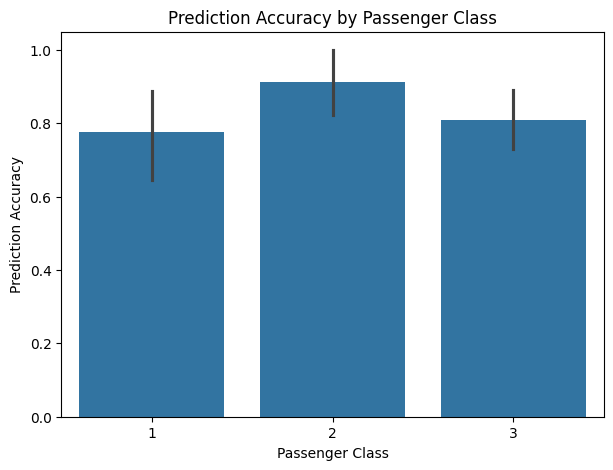

In [ ]:
# visualize it


plt.figure(figsize=(7, 5))

sns.barplot(
    data=error_analysis,
    x='Pclass',
    y='Correct'
)

plt.xlabel('Passenger Class')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy by Passenger Class'
)

plt.show()

# analyze age

In [ ]:
error_analysis['AgeGroup'] = pd.cut(
    error_analysis['Age'],
    bins=[
        0,
        12,
        18,
        35,
        60,
        100
    ],
    labels=[
        'Child',
        'Teenager',
        'Young Adult',
        'Adult',
        'Senior'
    ]
)

In [ ]:
age_error_analysis = (
    error_analysis
    .groupby(
        'AgeGroup',
        observed=False
    )['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

age_error_analysis['Accuracy'] = (
    age_error_analysis['mean'] * 100
)

age_error_analysis

,count,sum,mean,Accuracy
AgeGroup,,,,
Child,14,10,0.714286,71.428571
Teenager,17,16,0.941176,94.117647
Young Adult,74,60,0.810811,81.081081
Adult,28,24,0.857143,85.714286
Senior,6,5,0.833333,83.333333


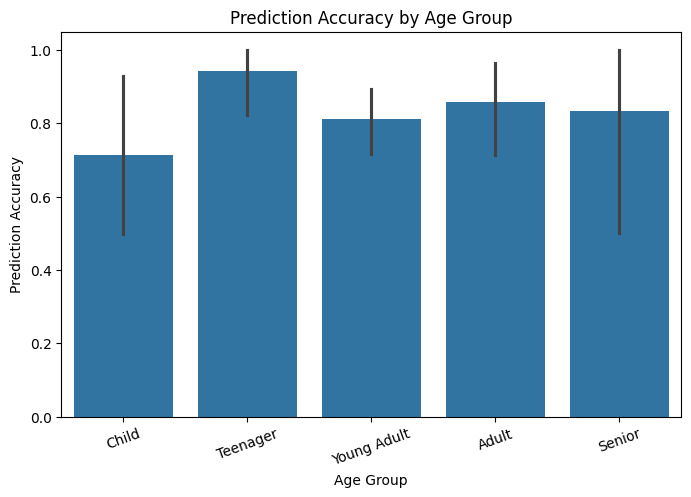

In [ ]:
# visualize age-groups

plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_analysis,
    x='AgeGroup',
    y='Correct'
)

plt.xlabel('Age Group')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy by Age Group'
)

plt.xticks(rotation=20)

plt.show()

Which age groups are hardest for the model to classify correctly?

### analyze Fimalysize

In [ ]:
family_error_analysis = (
    error_analysis
    .groupby('FamilySize')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

family_error_analysis['Accuracy'] = (
    family_error_analysis['mean'] * 100
)

family_error_analysis

,count,sum,mean,Accuracy
FamilySize,,,,
1,103,85,0.825243,82.524272
2,32,28,0.875000,87.500000
3,25,16,0.640000,64.000000
4,7,6,0.857143,85.714286
5,1,1,1.000000,100.000000
6,6,6,1.000000,100.000000
7,1,1,1.000000,100.000000
8,2,2,1.000000,100.000000
11,2,2,1.000000,100.000000


In [ ]:
# analyze the false negativs specificallly


false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

In [ ]:
false_negatives

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct,AgeGroup
553,22.0,0,0,7.2250,1,1,1,7.225000,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
712,48.0,1,0,52.0000,2,0,2,26.000000,1,male,S,Mr,C,High,1,0,False,Adult
455,29.0,0,0,7.8958,1,1,1,7.895800,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
65,NaN,1,1,15.2458,3,0,2,7.622900,3,male,C,Master,Unknown,Medium-High,1,0,False,NaN
489,9.0,1,1,15.9000,3,0,2,7.950000,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
869,4.0,1,1,11.1333,3,0,3,3.711100,3,male,S,Master,Unknown,Medium-Low,1,0,False,Child
165,9.0,0,2,20.5250,3,0,3,6.841667,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
17,NaN,0,0,13.0000,1,1,1,13.000000,2,male,S,Mr,Unknown,Medium-Low,1,0,False,NaN
701,35.0,0,0,26.2875,1,1,1,26.287500,1,male,S,Mr,E,Medium-High,1,0,False,Young Adult
447,34.0,0,0,26.5500,1,1,1,26.550000,1,male,S,Mr,Unknown,Medium-High,1,0,False,Young Adult


hat do these incorrectly classified survivors have in common?

In [ ]:
false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

In [ ]:
false_positives

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct,AgeGroup
297,2.0,1,2,151.5500,4,0,4,37.8875,1,female,S,Miss,C,High,0,1,False,Child
40,40.0,1,0,9.4750,2,0,1,9.4750,3,female,S,Mrs,Unknown,Medium-Low,0,1,False,Adult
564,NaN,0,0,8.0500,1,1,1,8.0500,3,female,S,Miss,Unknown,Medium-Low,0,1,False,NaN
502,NaN,0,0,7.6292,1,1,1,7.6292,3,female,Q,Miss,Unknown,Low,0,1,False,NaN
578,NaN,1,0,14.4583,2,0,1,14.4583,3,female,C,Mrs,Unknown,Medium-High,0,1,False,NaN
38,18.0,2,0,18.0000,3,0,2,9.0000,3,female,S,Miss,Unknown,Medium-High,0,1,False,Teenager
593,NaN,0,2,7.7500,3,0,1,7.7500,3,female,Q,Miss,Unknown,Low,0,1,False,NaN
501,21.0,0,0,7.7500,1,1,1,7.7500,3,female,Q,Miss,Unknown,Low,0,1,False,Young Adult
245,44.0,2,0,90.0000,3,0,2,45.0000,1,male,Q,Rare,C,High,0,1,False,Adult
799,30.0,1,1,24.1500,3,0,3,8.0500,3,female,S,Mrs,Unknown,Medium-High,0,1,False,Young Adult


In [ ]:
# Compate FN and FP


print(
    "False Negatives:",
    len(false_negatives)
)

print(
    "False Positives:",
    len(false_positives)
)

False Negatives: 20
False Positives: 12


In [ ]:
# summay where the mode struggles


error_summary = pd.DataFrame({
    'Total Passengers':
        [len(error_analysis)],

    'Correct Predictions':
        [error_analysis['Correct'].sum()],

    'Incorrect Predictions':
        [
            (~error_analysis['Correct']).sum()
        ],

    'False Positives':
        [len(false_positives)],

    'False Negatives':
        [len(false_negatives)]
})

error_summary

,Total Passengers,Correct Predictions,Incorrect Predictions,False Positives,False Negatives
0,179,147,32,12,20




Confusion Matrix
       ↓
TN / FP / FN / TP
       ↓
Incorrect Predictions
       ↓
Analyze Sex
       ↓
Analyze Pclass
       ↓
Analyze Age
       ↓
Analyze FamilySize
       ↓
Analyze False Positives
       ↓
Analyze False Negatives

## analze engineered features

Did these features help explain the passengers the model struggled to classify?



### analyze Title

In [ ]:
title_error_analysis = (
    error_analysis
    .groupby('Title')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

title_error_analysis['Accuracy'] = (
    title_error_analysis['mean'] * 100
)

title_error_analysis.sort_values(
    by='Accuracy'
)

,count,sum,mean,Accuracy
Title,,,,
Master,9,5,0.555556,55.555556
Rare,5,4,0.800000,80.000000
Miss,41,33,0.804878,80.487805
Mrs,19,16,0.842105,84.210526
Mr,105,89,0.847619,84.761905


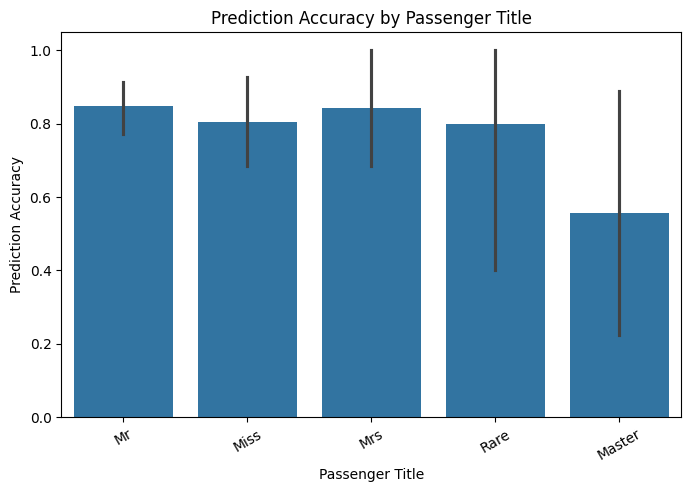

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_analysis,
    x='Title',
    y='Correct'
)

plt.xlabel('Passenger Title')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy by Passenger Title'
)

plt.xticks(rotation=30)

plt.show()

### analyze Deck

In [ ]:
deck_error_analysis = (
    error_analysis
    .groupby('Deck')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

deck_error_analysis['Accuracy'] = (
    deck_error_analysis['mean'] * 100
)

deck_error_analysis.sort_values(
    by='Accuracy'
)

,count,sum,mean,Accuracy
Deck,,,,
A,1,0,0.000000,0.000000
E,3,2,0.666667,66.666667
C,18,14,0.777778,77.777778
Unknown,135,111,0.822222,82.222222
B,13,11,0.846154,84.615385
D,7,7,1.000000,100.000000
F,2,2,1.000000,100.000000


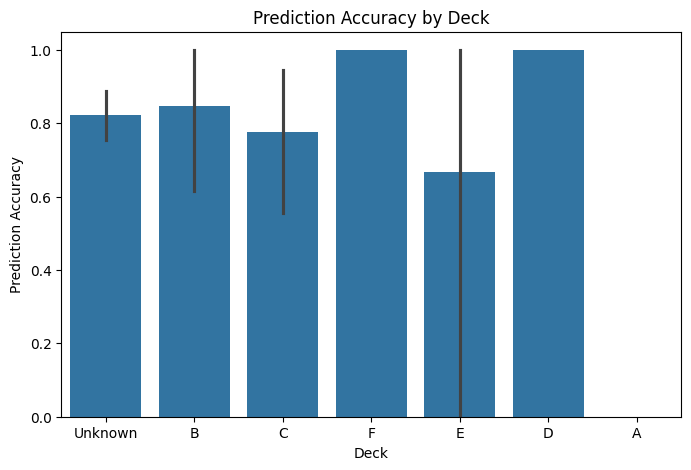

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_analysis,
    x='Deck',
    y='Correct'
)

plt.xlabel('Deck')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy by Deck'
)

plt.show()

### analyze FareGroup

In [ ]:
fare_group_error_analysis = (
    error_analysis
    .groupby('FareGroup', observed=False)['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

fare_group_error_analysis['Accuracy'] = (
    fare_group_error_analysis['mean'] * 100
)

fare_group_error_analysis

,count,sum,mean,Accuracy
FareGroup,,,,
Low,43,35,0.813953,81.395349
Medium-Low,43,35,0.813953,81.395349
Medium-High,47,38,0.808511,80.851064
High,46,39,0.847826,84.782609


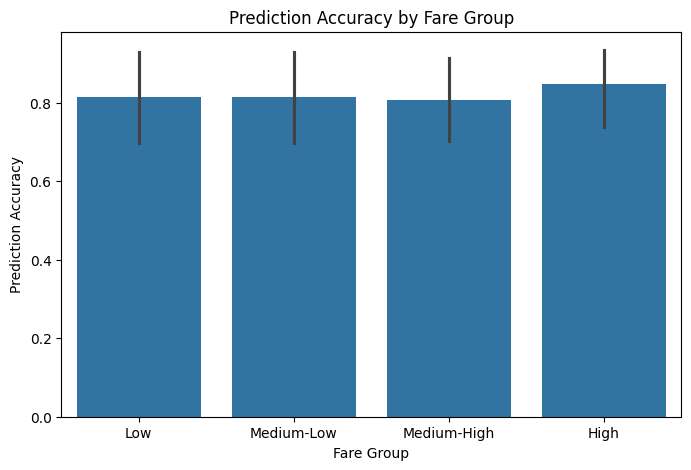

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_analysis,
    x='FareGroup',
    y='Correct'
)

plt.xlabel('Fare Group')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy by Fare Group'
)

plt.show()

### analyze TicketGroupSize

In [ ]:
ticket_group_error_analysis = (
    error_analysis
    .groupby('TicketGroupSize')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

ticket_group_error_analysis['Accuracy'] = (
    ticket_group_error_analysis['mean'] * 100
)

ticket_group_error_analysis

,count,sum,mean,Accuracy
TicketGroupSize,,,,
1,108,87,0.805556,80.555556
2,39,33,0.846154,84.615385
3,13,10,0.769231,76.923077
4,10,8,0.800000,80.000000
5,1,1,1.000000,100.000000
6,4,4,1.000000,100.000000
7,4,4,1.000000,100.000000


### analyze IsAlone

In [ ]:
alone_error_analysis = (
    error_analysis
    .groupby('IsAlone')['Correct']
    .agg(
        ['count', 'sum', 'mean']
    )
)

alone_error_analysis['Accuracy'] = (
    alone_error_analysis['mean'] * 100
)

alone_error_analysis

,count,sum,mean,Accuracy
IsAlone,,,,
0,76,62,0.815789,81.578947
1,103,85,0.825243,82.524272


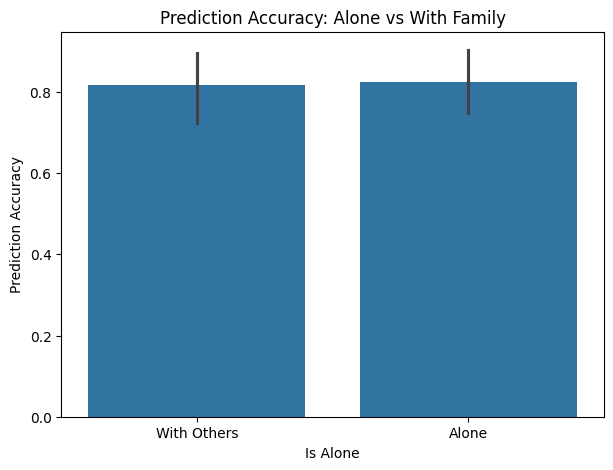

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=error_analysis,
    x='IsAlone',
    y='Correct'
)

plt.xlabel('Is Alone')
plt.ylabel('Prediction Accuracy')
plt.title(
    'Prediction Accuracy: Alone vs With Family'
)

plt.xticks(
    [0, 1],
    ['With Others', 'Alone']
)

plt.show()

### analyze FarePerson

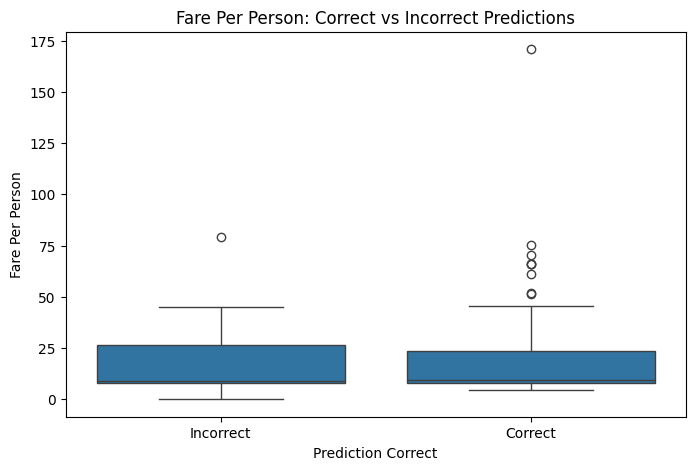

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=error_analysis,
    x='Correct',
    y='FarePerPerson'
)

plt.xlabel('Prediction Correct')
plt.ylabel('Fare Per Person')
plt.title(
    'Fare Per Person: Correct vs Incorrect Predictions'
)

plt.xticks(
    [0, 1],
    ['Incorrect', 'Correct']
)

plt.show()

Are incorrectly classified passengers concentrated around certain fare-per-person values?

### Most difficult engineered groups


In [ ]:
engineered_errors = error_analysis[
    error_analysis['Correct'] == False
]

In [ ]:
# chect titles


engineered_errors['Title'].value_counts()


,count
Title,
Mr,16
Miss,8
Master,4
Mrs,3
Rare,1


In [ ]:
# check Deck


engineered_errors['Deck'].value_counts()

,count
Deck,
Unknown,24
C,4
B,2
E,1
A,1


In [ ]:
# check faregroups

engineered_errors['FareGroup'].value_counts()

,count
FareGroup,
Medium-High,9
Low,8
Medium-Low,8
High,7


In [ ]:
# check alone status

engineered_errors['IsAlone'].value_counts()


,count
IsAlone,
1,18
0,14


### Compact summary



In [ ]:
error_profile = {
    'Title': engineered_errors['Title'].value_counts(),
    'Deck': engineered_errors['Deck'].value_counts(),
    'FareGroup': engineered_errors['FareGroup'].value_counts(),
    'IsAlone': engineered_errors['IsAlone'].value_counts()
}

error_profile

{'Title': Title
 Mr        16
 Miss       8
 Master     4
 Mrs        3
 Rare       1
 Name: count, dtype: int64,
 'Deck': Deck
 Unknown    24
 C           4
 B           2
 E           1
 A           1
 Name: count, dtype: int64,
 'FareGroup': FareGroup
 Medium-High    9
 Low            8
 Medium-Low     8
 High           7
 Name: count, dtype: int64,
 'IsAlone': IsAlone
 1    18
 0    14
 Name: count, dtype: int64}

## calculate actual error rates

In [ ]:
title_error_analysis['Error Rate'] = (
    100 -
    title_error_analysis['Accuracy']
)

title_error_analysis.sort_values(
    by='Error Rate',
    ascending=False
)

,count,sum,mean,Accuracy,Error Rate
Title,,,,,
Master,9,5,0.555556,55.555556,44.444444
Rare,5,4,0.800000,80.000000,20.000000
Miss,41,33,0.804878,80.487805,19.512195
Mrs,19,16,0.842105,84.210526,15.789474
Mr,105,89,0.847619,84.761905,15.238095


In [ ]:
deck_error_analysis['Error Rate'] = (
    100 -
    deck_error_analysis['Accuracy']
)

deck_error_analysis.sort_values(
    by='Error Rate',
    ascending=False
)

,count,sum,mean,Accuracy,Error Rate
Deck,,,,,
A,1,0,0.000000,0.000000,100.000000
E,3,2,0.666667,66.666667,33.333333
C,18,14,0.777778,77.777778,22.222222
Unknown,135,111,0.822222,82.222222,17.777778
B,13,11,0.846154,84.615385,15.384615
D,7,7,1.000000,100.000000,0.000000
F,2,2,1.000000,100.000000,0.000000


In [ ]:
fare_group_error_analysis['Error Rate'] = (
    100 -
    fare_group_error_analysis['Accuracy']
)

fare_group_error_analysis.sort_values(
    by='Error Rate',
    ascending=False
)

,count,sum,mean,Accuracy,Error Rate
FareGroup,,,,,
Medium-High,47,38,0.808511,80.851064,19.148936
Low,43,35,0.813953,81.395349,18.604651
Medium-Low,43,35,0.813953,81.395349,18.604651
High,46,39,0.847826,84.782609,15.217391


In [ ]:
alone_error_rate = (
    error_analysis
    .groupby('IsAlone')['Correct']
    .agg(
        Total='count',
        Correct='sum'
    )
)

alone_error_rate['Errors'] = (
    alone_error_rate['Total'] -
    alone_error_rate['Correct']
)

alone_error_rate['Error Rate'] = (
    alone_error_rate['Errors'] /
    alone_error_rate['Total']
) * 100

alone_error_rate

,Total,Correct,Errors,Error Rate
IsAlone,,,,
0,76,62,14,18.421053
1,103,85,18,17.475728


                    MODEL ERRORS
                         │
          ┌──────────────┴──────────────┐
          ↓                             ↓
    False Positives              False Negatives
          │                             │
          └──────────────┬──────────────┘
                         ↓
                 Passenger Groups
                         │
       ┌─────────┬───────┼───────┬─────────┐
       ↓         ↓       ↓       ↓         ↓
      Sex      Pclass   Age     Title     Deck
                                  │
                         ┌────────┴────────┐
                         ↓                 ↓
                    FareGroup          IsAlone

In [ ]:
false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

false_negatives

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct,AgeGroup
553,22.0,0,0,7.2250,1,1,1,7.225000,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
712,48.0,1,0,52.0000,2,0,2,26.000000,1,male,S,Mr,C,High,1,0,False,Adult
455,29.0,0,0,7.8958,1,1,1,7.895800,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
65,NaN,1,1,15.2458,3,0,2,7.622900,3,male,C,Master,Unknown,Medium-High,1,0,False,NaN
489,9.0,1,1,15.9000,3,0,2,7.950000,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
869,4.0,1,1,11.1333,3,0,3,3.711100,3,male,S,Master,Unknown,Medium-Low,1,0,False,Child
165,9.0,0,2,20.5250,3,0,3,6.841667,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
17,NaN,0,0,13.0000,1,1,1,13.000000,2,male,S,Mr,Unknown,Medium-Low,1,0,False,NaN
701,35.0,0,0,26.2875,1,1,1,26.287500,1,male,S,Mr,E,Medium-High,1,0,False,Young Adult
447,34.0,0,0,26.5500,1,1,1,26.550000,1,male,S,Mr,Unknown,Medium-High,1,0,False,Young Adult


In [ ]:
print(
    "Number of False Negatives:",
    len(false_negatives)
)

Number of False Negatives: 20


In [ ]:
false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

print(
    "Number of False Positives:",
    len(false_positives)
)

Number of False Positives: 12


In [ ]:
false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

print("False Negatives:", len(false_negatives))

false_negatives

False Negatives: 20


,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct,AgeGroup
553,22.0,0,0,7.2250,1,1,1,7.225000,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
712,48.0,1,0,52.0000,2,0,2,26.000000,1,male,S,Mr,C,High,1,0,False,Adult
455,29.0,0,0,7.8958,1,1,1,7.895800,3,male,C,Mr,Unknown,Low,1,0,False,Young Adult
65,NaN,1,1,15.2458,3,0,2,7.622900,3,male,C,Master,Unknown,Medium-High,1,0,False,NaN
489,9.0,1,1,15.9000,3,0,2,7.950000,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
869,4.0,1,1,11.1333,3,0,3,3.711100,3,male,S,Master,Unknown,Medium-Low,1,0,False,Child
165,9.0,0,2,20.5250,3,0,3,6.841667,3,male,S,Master,Unknown,Medium-High,1,0,False,Child
17,NaN,0,0,13.0000,1,1,1,13.000000,2,male,S,Mr,Unknown,Medium-Low,1,0,False,NaN
701,35.0,0,0,26.2875,1,1,1,26.287500,1,male,S,Mr,E,Medium-High,1,0,False,Young Adult
447,34.0,0,0,26.5500,1,1,1,26.550000,1,male,S,Mr,Unknown,Medium-High,1,0,False,Young Adult


In [ ]:
false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

print("False Positives:", len(false_positives))

false_positives

False Positives: 12


,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup,Actual,Predicted,Correct,AgeGroup
297,2.0,1,2,151.5500,4,0,4,37.8875,1,female,S,Miss,C,High,0,1,False,Child
40,40.0,1,0,9.4750,2,0,1,9.4750,3,female,S,Mrs,Unknown,Medium-Low,0,1,False,Adult
564,NaN,0,0,8.0500,1,1,1,8.0500,3,female,S,Miss,Unknown,Medium-Low,0,1,False,NaN
502,NaN,0,0,7.6292,1,1,1,7.6292,3,female,Q,Miss,Unknown,Low,0,1,False,NaN
578,NaN,1,0,14.4583,2,0,1,14.4583,3,female,C,Mrs,Unknown,Medium-High,0,1,False,NaN
38,18.0,2,0,18.0000,3,0,2,9.0000,3,female,S,Miss,Unknown,Medium-High,0,1,False,Teenager
593,NaN,0,2,7.7500,3,0,1,7.7500,3,female,Q,Miss,Unknown,Low,0,1,False,NaN
501,21.0,0,0,7.7500,1,1,1,7.7500,3,female,Q,Miss,Unknown,Low,0,1,False,Young Adult
245,44.0,2,0,90.0000,3,0,2,45.0000,1,male,Q,Rare,C,High,0,1,False,Adult
799,30.0,1,1,24.1500,3,0,3,8.0500,3,female,S,Mrs,Unknown,Medium-High,0,1,False,Young Adult


In [ ]:
analysis_features = [
    'Sex',
    'Pclass',
    'Age',
    'Fare',
    'FamilySize',
    'Title',
    'Deck',
    'IsAlone',
    'TicketGroupSize'
]

In [ ]:
false_negatives[analysis_features]

,Sex,Pclass,Age,Fare,FamilySize,Title,Deck,IsAlone,TicketGroupSize
553,male,3,22.0,7.2250,1,Mr,Unknown,1,1
712,male,1,48.0,52.0000,2,Mr,C,0,2
455,male,3,29.0,7.8958,1,Mr,Unknown,1,1
65,male,3,NaN,15.2458,3,Master,Unknown,0,2
489,male,3,9.0,15.9000,3,Master,Unknown,0,2
869,male,3,4.0,11.1333,3,Master,Unknown,0,3
165,male,3,9.0,20.5250,3,Master,Unknown,0,3
17,male,2,NaN,13.0000,1,Mr,Unknown,1,1
701,male,1,35.0,26.2875,1,Mr,E,1,1
447,male,1,34.0,26.5500,1,Mr,Unknown,1,1


In [ ]:
false_positives[analysis_features]

,Sex,Pclass,Age,Fare,FamilySize,Title,Deck,IsAlone,TicketGroupSize
297,female,1,2.0,151.5500,4,Miss,C,0,4
40,female,3,40.0,9.4750,2,Mrs,Unknown,0,1
564,female,3,NaN,8.0500,1,Miss,Unknown,1,1
502,female,3,NaN,7.6292,1,Miss,Unknown,1,1
578,female,3,NaN,14.4583,2,Mrs,Unknown,0,1
38,female,3,18.0,18.0000,3,Miss,Unknown,0,2
593,female,3,NaN,7.7500,3,Miss,Unknown,0,1
501,female,3,21.0,7.7500,1,Miss,Unknown,1,1
245,male,1,44.0,90.0000,3,Rare,C,0,2
799,female,3,30.0,24.1500,3,Mrs,Unknown,0,3


In [ ]:
print("False Negatives:")
print(false_negatives[analysis_features].describe(include='all'))

print("\nFalse Positives:")
print(false_positives[analysis_features].describe(include='all'))

False Negatives:
         Sex     Pclass        Age       Fare  FamilySize Title     Deck  \
count     20  20.000000  16.000000  20.000000    20.00000    20       20   
unique     1        NaN        NaN        NaN         NaN     2        5   
top     male        NaN        NaN        NaN         NaN    Mr  Unknown   
freq      20        NaN        NaN        NaN         NaN    16       14   
mean     NaN   2.100000  29.812500  23.342285     1.60000   NaN      NaN   
std      NaN   0.967906  16.265377  20.228409     0.88258   NaN      NaN   
min      NaN   1.000000   4.000000   0.000000     1.00000   NaN      NaN   
25%      NaN   1.000000  24.250000   8.058325     1.00000   NaN      NaN   
50%      NaN   2.500000  27.500000  15.572900     1.00000   NaN      NaN   
75%      NaN   3.000000  34.250000  31.750000     2.25000   NaN      NaN   
max      NaN   3.000000  62.000000  79.200000     3.00000   NaN      NaN   

         IsAlone  TicketGroupSize  
count   20.00000        20.000000 

In [ ]:
for col in ['Sex', 'Pclass', 'Title', 'Deck', 'IsAlone']:
    print(f"\n--- {col} ---")
    print("False Negatives:")
    print(false_negatives[col].value_counts())

    print("False Positives:")
    print(false_positives[col].value_counts())


--- Sex ---
False Negatives:
Sex
male    20
Name: count, dtype: int64
False Positives:
Sex
female    11
male       1
Name: count, dtype: int64

--- Pclass ---
False Negatives:
Pclass
3    10
1     8
2     2
Name: count, dtype: int64
False Positives:
Pclass
3    9
1    2
2    1
Name: count, dtype: int64

--- Title ---
False Negatives:
Title
Mr        16
Master     4
Name: count, dtype: int64
False Positives:
Title
Miss    8
Mrs     3
Rare    1
Name: count, dtype: int64

--- Deck ---
False Negatives:
Deck
Unknown    14
C           2
B           2
E           1
A           1
Name: count, dtype: int64
False Positives:
Deck
Unknown    10
C           2
Name: count, dtype: int64

--- IsAlone ---
False Negatives:
IsAlone
1    13
0     7
Name: count, dtype: int64
False Positives:
IsAlone
0    7
1    5
Name: count, dtype: int64


                         MODEL ERRORS
                              │
              ┌───────────────┴───────────────┐
              ↓                               ↓
       FALSE NEGATIVES                 FALSE POSITIVES
       Actual = 1                      Actual = 0
       Predicted = 0                   Predicted = 1
              │                               │
              ↓                               ↓
       Mostly MALE                    Mostly FEMALE
       Mostly Pclass 3                Mostly Pclass 3
       Mostly Mr/Master               Mostly Miss/Mrs
       Many IsAlone=1                 More balanced IsAlone

In [ ]:
false_negatives[
    [
        'Sex',
        'Pclass',
        'Age',
        'FamilySize',
        'IsAlone',
        'TicketGroupSize',
        'FarePerPerson',
        'Title',
        'Deck',
        'FareGroup',
        'Actual',
        'Predicted'
    ]
]

,Sex,Pclass,Age,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Title,Deck,FareGroup,Actual,Predicted
553,male,3,22.0,1,1,1,7.225000,Mr,Unknown,Low,1,0
712,male,1,48.0,2,0,2,26.000000,Mr,C,High,1,0
455,male,3,29.0,1,1,1,7.895800,Mr,Unknown,Low,1,0
65,male,3,NaN,3,0,2,7.622900,Master,Unknown,Medium-High,1,0
489,male,3,9.0,3,0,2,7.950000,Master,Unknown,Medium-High,1,0
869,male,3,4.0,3,0,3,3.711100,Master,Unknown,Medium-Low,1,0
165,male,3,9.0,3,0,3,6.841667,Master,Unknown,Medium-High,1,0
17,male,2,NaN,1,1,1,13.000000,Mr,Unknown,Medium-Low,1,0
701,male,1,35.0,1,1,1,26.287500,Mr,E,Medium-High,1,0
447,male,1,34.0,1,1,1,26.550000,Mr,Unknown,Medium-High,1,0


In [ ]:
false_positives[
    [
        'Sex',
        'Pclass',
        'Age',
        'FamilySize',
        'IsAlone',
        'TicketGroupSize',
        'FarePerPerson',
        'Title',
        'Deck',
        'FareGroup',
        'Actual',
        'Predicted'
    ]
]

,Sex,Pclass,Age,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Title,Deck,FareGroup,Actual,Predicted
297,female,1,2.0,4,0,4,37.8875,Miss,C,High,0,1
40,female,3,40.0,2,0,1,9.4750,Mrs,Unknown,Medium-Low,0,1
564,female,3,NaN,1,1,1,8.0500,Miss,Unknown,Medium-Low,0,1
502,female,3,NaN,1,1,1,7.6292,Miss,Unknown,Low,0,1
578,female,3,NaN,2,0,1,14.4583,Mrs,Unknown,Medium-High,0,1
38,female,3,18.0,3,0,2,9.0000,Miss,Unknown,Medium-High,0,1
593,female,3,NaN,3,0,1,7.7500,Miss,Unknown,Low,0,1
501,female,3,21.0,1,1,1,7.7500,Miss,Unknown,Low,0,1
245,male,1,44.0,3,0,2,45.0000,Rare,C,High,0,1
799,female,3,30.0,3,0,3,8.0500,Mrs,Unknown,Medium-High,0,1


In [ ]:
logistic_probabilities = (
    best_logistic_model.predict_proba(X_test)[:, 1]
)

In [ ]:
error_analysis['SurvivalProbability'] = (
    logistic_probabilities
)

In [ ]:
false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

false_negatives[
    [
        'SurvivalProbability',
        'Sex',
        'Pclass',
        'Age',
        'FamilySize',
        'Title',
        'Deck'
    ]
].sort_values(
    by='SurvivalProbability',
    ascending=False
)

,SurvivalProbability,Sex,Pclass,Age,FamilySize,Title,Deck
165,0.436701,male,3,9.0,3,Master,Unknown
701,0.427923,male,1,35.0,1,Mr,E
489,0.412905,male,3,9.0,3,Master,Unknown
55,0.411994,male,1,NaN,1,Mr,C
23,0.409175,male,1,28.0,1,Mr,A
690,0.391352,male,1,31.0,2,Mr,B
65,0.366068,male,3,NaN,3,Master,Unknown
869,0.355732,male,3,4.0,3,Master,Unknown
712,0.289447,male,1,48.0,2,Mr,C
607,0.281909,male,1,27.0,1,Mr,Unknown


In [ ]:
error_analysis['DistanceFromThreshold'] = (
    abs(
        error_analysis['SurvivalProbability'] - 0.5
    )
)

In [ ]:
borderline_errors = error_analysis[
    error_analysis['Correct'] == False
].sort_values(
    by='DistanceFromThreshold'
)

borderline_errors[
    [
        'SurvivalProbability',
        'Actual',
        'Predicted',
        'Sex',
        'Pclass',
        'Age',
        'FamilySize',
        'Title',
        'Deck'
    ]
].head(10)

,SurvivalProbability,Actual,Predicted,Sex,Pclass,Age,FamilySize,Title,Deck
40,0.529244,0,1,female,3,40.0,2,Mrs,Unknown
245,0.530977,0,1,male,1,44.0,3,Rare,C
593,0.554312,0,1,female,3,NaN,3,Miss,Unknown
564,0.560349,0,1,female,3,NaN,1,Miss,Unknown
165,0.436701,1,0,male,3,9.0,3,Master,Unknown
701,0.427923,1,0,male,1,35.0,1,Mr,E
38,0.575511,0,1,female,3,18.0,3,Miss,Unknown
489,0.412905,1,0,male,3,9.0,3,Master,Unknown
55,0.411994,1,0,male,1,NaN,1,Mr,C
293,0.589167,0,1,female,3,24.0,1,Miss,Unknown


## Main Findings From Your Error Analysis
Finding 1 — Sex is the strongest error pattern

All 20 false negatives were male, while 11 of 12 false positives were female.

This strongly suggests the model has learned the historical survival advantage associated with female passengers.

Finding 2 — Third class is difficult

Pclass 3 accounts for:

10/20 false negatives
9/12 false positives

So the model struggles considerably with third-class passengers.

Finding 3 — Title reinforces Sex

The FN/FP pattern for Title closely mirrors Sex.

This suggests strong information overlap between the two features.

We'll investigate this later rather than assuming one should be removed.

Finding 4 — Missing cabin information is common among errors

Most FN and FP passengers have:

Deck = Unknown

But because Unknown is such a large population, this does not automatically mean Deck=Unknown causes errors.

Finding 5 — IsAlone isn't a major error driver

Although 65% of false negatives were alone passengers, the overall error rates for IsAlone=0 and IsAlone=1 were almost identical.

So we shouldn't overstate its importanceMain Findings From Your Error Analysis
Finding 1 — Sex is the strongest error pattern

All 20 false negatives were male, while 11 of 12 false positives were female.

This strongly suggests the model has learned the historical survival advantage associated with female passengers.

Finding 2 — Third class is difficult

Pclass 3 accounts for:

10/20 false negatives
9/12 false positives

So the model struggles considerably with third-class passengers.

Finding 3 — Title reinforces Sex

The FN/FP pattern for Title closely mirrors Sex.

This suggests strong information overlap between the two features.

We'll investigate this later rather than assuming one should be removed.

Finding 4 — Missing cabin information is common among errors

Most FN and FP passengers have:

Deck = Unknown

But because Unknown is such a large population, this does not automatically mean Deck=Unknown causes errors.

Finding 5 — IsAlone isn't a major error driver

Although 65% of false negatives were alone passengers, the overall error rates for IsAlone=0 and IsAlone=1 were almost identical.

So we shouldn't overstate its importance

# Model Interpretation

What is actually driving my model's predictions?"

For your Logistic Regression model, we'll analyze:

Model coefficients

Positive vs negative coefficients

Coefficient magnitude

Feature importance after encoding

Which features increase/decrease

survival probability

Whether engineered features actually

contribute useful information

Sex vs Title redundancy

Potentially removing weak/redundant features

"Can I explain and validate what my model is doing?"

"Can I improve the model?"

##bLogistic Model

In [ ]:
logistic_model = (
    best_logistic_model
    .named_steps['classifier']
)

logistic_model

LogisticRegression(C=0.1, solver='liblinear')

In [ ]:
feature_names = (
    best_logistic_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

feature_names

array(['numerical__Age', 'numerical__SibSp', 'numerical__Parch',
       'numerical__Fare', 'numerical__FamilySize', 'numerical__IsAlone',
       'numerical__TicketGroupSize', 'numerical__FarePerPerson',
       'categorical__Pclass_1', 'categorical__Pclass_2',
       'categorical__Pclass_3', 'categorical__Sex_female',
       'categorical__Sex_male', 'categorical__Embarked_C',
       'categorical__Embarked_Q', 'categorical__Embarked_S',
       'categorical__Title_Master', 'categorical__Title_Miss',
       'categorical__Title_Mr', 'categorical__Title_Mrs',
       'categorical__Title_Rare', 'categorical__Deck_A',
       'categorical__Deck_B', 'categorical__Deck_C',
       'categorical__Deck_D', 'categorical__Deck_E',
       'categorical__Deck_F', 'categorical__Deck_G',
       'categorical__Deck_T', 'categorical__Deck_Unknown',
       'categorical__FareGroup_High', 'categorical__FareGroup_Low',
       'categorical__FareGroup_Medium-High',
       'categorical__FareGroup_Medium-Low'], dtype=o

In [ ]:
# get the coefficients


coefficients = (
    logistic_model
    .coef_[0]
)


In [ ]:
coefficient_analysis = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coefficient_analysis['AbsCoefficient'] = (
    coefficient_analysis['Coefficient'].abs()
)

coefficient_analysis = coefficient_analysis.sort_values(
    by='AbsCoefficient',
    ascending=False
)

coefficient_analysis

,Feature,Coefficient,AbsCoefficient
18,categorical__Title_Mr,-0.879475,0.879475
11,categorical__Sex_female,0.743555,0.743555
12,categorical__Sex_male,-0.518008,0.518008
29,categorical__Deck_Unknown,-0.493233,0.493233
19,categorical__Title_Mrs,0.489620,0.489620
16,categorical__Title_Master,0.462246,0.462246
8,categorical__Pclass_1,0.422091,0.422091
10,categorical__Pclass_3,-0.391098,0.391098
25,categorical__Deck_E,0.363762,0.363762
0,numerical__Age,-0.338962,0.338962


In [ ]:
coefficient_analysis = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [ ]:
coefficient_analysis

,Feature,Coefficient
0,numerical__Age,-0.338962
1,numerical__SibSp,-0.268240
2,numerical__Parch,-0.103725
3,numerical__Fare,0.256278
4,numerical__FamilySize,-0.233765
5,numerical__IsAlone,-0.145059
6,numerical__TicketGroupSize,-0.083610
7,numerical__FarePerPerson,-0.095444
8,categorical__Pclass_1,0.422091
9,categorical__Pclass_2,0.194554


In [ ]:
# sorting coefficients


coefficient_analysis = (
    coefficient_analysis
    .sort_values(
        by='Coefficient',
        ascending=False
    )
)

coefficient_analysis

,Feature,Coefficient
11,categorical__Sex_female,0.743555
19,categorical__Title_Mrs,0.489620
16,categorical__Title_Master,0.462246
8,categorical__Pclass_1,0.422091
25,categorical__Deck_E,0.363762
30,categorical__FareGroup_High,0.318859
24,categorical__Deck_D,0.307662
3,numerical__Fare,0.256278
32,categorical__FareGroup_Medium-High,0.224791
14,categorical__Embarked_Q,0.224465


In [ ]:
# find the strongest positive features

top_positive_features = (
    coefficient_analysis
    .head(10)
)

top_positive_features

,Feature,Coefficient
11,categorical__Sex_female,0.743555
19,categorical__Title_Mrs,0.489620
16,categorical__Title_Master,0.462246
8,categorical__Pclass_1,0.422091
25,categorical__Deck_E,0.363762
30,categorical__FareGroup_High,0.318859
24,categorical__Deck_D,0.307662
3,numerical__Fare,0.256278
32,categorical__FareGroup_Medium-High,0.224791
14,categorical__Embarked_Q,0.224465


In [ ]:
# strongest negative features

top_negative_features = (
    coefficient_analysis
    .tail(10)
    .sort_values(
        by='Coefficient'
    )
)

top_negative_features

,Feature,Coefficient
18,categorical__Title_Mr,-0.879475
12,categorical__Sex_male,-0.518008
29,categorical__Deck_Unknown,-0.493233
10,categorical__Pclass_3,-0.391098
0,numerical__Age,-0.338962
1,numerical__SibSp,-0.268240
31,categorical__FareGroup_Low,-0.238899
4,numerical__FamilySize,-0.233765
15,categorical__Embarked_S,-0.155819
5,numerical__IsAlone,-0.145059


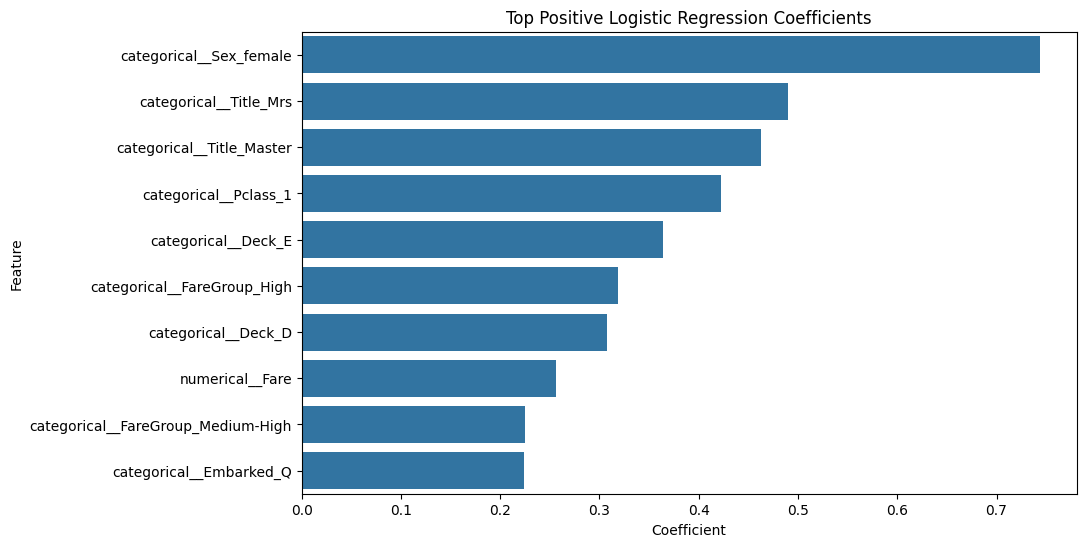

In [ ]:
# visualize the coefficients

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive_features,
    x='Coefficient',
    y='Feature'
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title(
    'Top Positive Logistic Regression Coefficients'
)

plt.show()

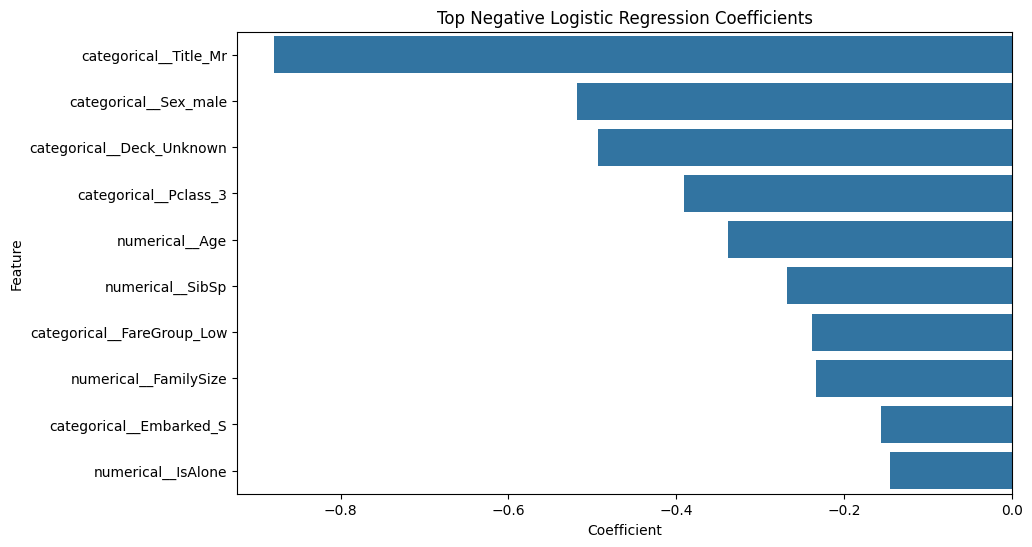

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative_features,
    x='Coefficient',
    y='Feature'
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title(
    'Top Negative Logistic Regression Coefficients'
)

plt.show()

In [ ]:
coefficient_analysis['OddsRatio'] = (
    np.exp(
        coefficient_analysis['Coefficient']
    )
)

In [ ]:
coefficient_analysis

,Feature,Coefficient,OddsRatio
11,categorical__Sex_female,0.743555,2.103399
19,categorical__Title_Mrs,0.489620,1.631696
16,categorical__Title_Master,0.462246,1.587635
8,categorical__Pclass_1,0.422091,1.525148
25,categorical__Deck_E,0.363762,1.438732
30,categorical__FareGroup_High,0.318859,1.375557
24,categorical__Deck_D,0.307662,1.360241
3,numerical__Fare,0.256278,1.292111
32,categorical__FareGroup_Medium-High,0.224791,1.252061
14,categorical__Embarked_Q,0.224465,1.251653


In [ ]:
coefficient_analysis['AbsoluteCoefficient'] = (
    coefficient_analysis['Coefficient'].abs()
)

In [ ]:
coefficient_importance = (
    coefficient_analysis
    .sort_values(
        by='AbsoluteCoefficient',
        ascending=False
    )
)

coefficient_importance.head(15)

,Feature,Coefficient,OddsRatio,AbsoluteCoefficient
18,categorical__Title_Mr,-0.879475,0.415001,0.879475
11,categorical__Sex_female,0.743555,2.103399,0.743555
12,categorical__Sex_male,-0.518008,0.595706,0.518008
29,categorical__Deck_Unknown,-0.493233,0.610649,0.493233
19,categorical__Title_Mrs,0.489620,1.631696,0.489620
16,categorical__Title_Master,0.462246,1.587635,0.462246
8,categorical__Pclass_1,0.422091,1.525148,0.422091
10,categorical__Pclass_3,-0.391098,0.676314,0.391098
25,categorical__Deck_E,0.363762,1.438732,0.363762
0,numerical__Age,-0.338962,0.712509,0.338962


In [ ]:
feature_names = best_logistic_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_logistic_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['AbsCoefficient'] = (
    coef_df['Coefficient'].abs()
)

coef_df = coef_df.sort_values(
    'AbsCoefficient',
    ascending=False
)

coef_df

,Feature,Coefficient,AbsCoefficient
18,categorical__Title_Mr,-0.879475,0.879475
11,categorical__Sex_female,0.743555,0.743555
12,categorical__Sex_male,-0.518008,0.518008
29,categorical__Deck_Unknown,-0.493233,0.493233
19,categorical__Title_Mrs,0.489620,0.489620
16,categorical__Title_Master,0.462246,0.462246
8,categorical__Pclass_1,0.422091,0.422091
10,categorical__Pclass_3,-0.391098,0.391098
25,categorical__Deck_E,0.363762,0.363762
0,numerical__Age,-0.338962,0.338962


## Random Foresst


In [ ]:
random_forest_model = (
    best_random_forest_model
    .named_steps['model']
)

In [ ]:
feature_names = (
    best_random_forest_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [ ]:
random_forest_importance = (
    random_forest_model
    .feature_importances_
)

In [ ]:
random_forest_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': random_forest_importance
})

In [ ]:
random_forest_feature_importance = (
    random_forest_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [ ]:
random_forest_feature_importance.head(15)

,Feature,Importance
18,categorical__Title_Mr,0.120259
12,categorical__Sex_male,0.112386
11,categorical__Sex_female,0.110835
7,numerical__FarePerPerson,0.093960
3,numerical__Fare,0.082358
0,numerical__Age,0.071783
10,categorical__Pclass_3,0.040404
17,categorical__Title_Miss,0.040215
4,numerical__FamilySize,0.038977
19,categorical__Title_Mrs,0.036448


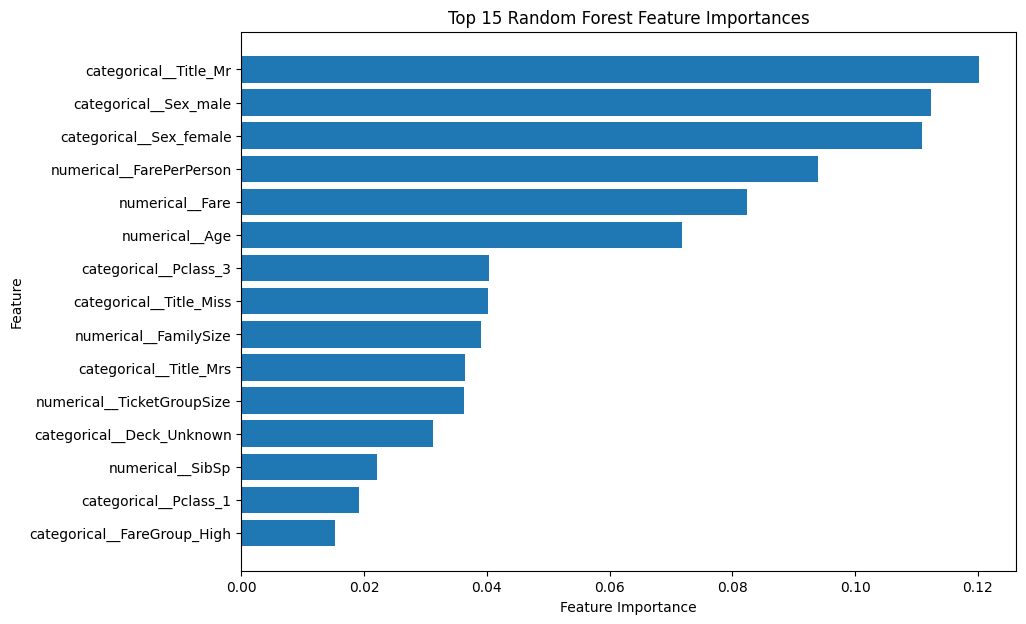

In [ ]:
top_rf_features = (
    random_forest_feature_importance
    .head(15)
    .sort_values(
        by='Importance'
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features['Feature'],
    top_rf_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Top 15 Random Forest Feature Importances'
)

plt.show()

### Aggreate the importance by original feature

In [ ]:
def get_original_feature(feature):

    if feature.startswith('numerical__'):
        return feature.replace(
            'numerical__',
            ''
        )

    if feature.startswith('categorical__'):
        feature = feature.replace(
            'categorical__',
            ''
        )

        for original_feature in categorical_features:

            if feature.startswith(
                original_feature + '_'
            ):
                return original_feature

        return feature

    return feature

In [ ]:
random_forest_feature_importance[
    'OriginalFeature'
] = (
    random_forest_feature_importance['Feature']
    .apply(get_original_feature)
)

In [ ]:
grouped_rf_importance = (
    random_forest_feature_importance
    .groupby('OriginalFeature')['Importance']
    .sum()
    .sort_values(
        ascending=False
    )
)

In [ ]:
grouped_rf_importance

,Importance
OriginalFeature,
Sex,0.223221
Title,0.212538
FarePerPerson,0.093960
Fare,0.082358
Age,0.071783
Pclass,0.070805
Deck,0.053954
FareGroup,0.040576
FamilySize,0.038977


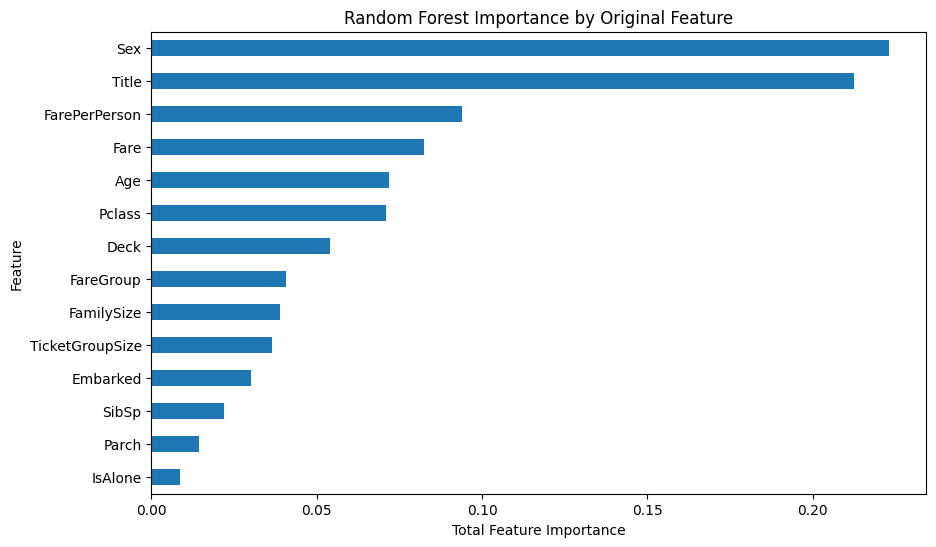

In [ ]:
plt.figure(figsize=(10, 6))

grouped_rf_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel('Total Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Random Forest Importance by Original Feature'
)

plt.show()

## Gradient Boosting

In [ ]:
gradient_boosting_model = (
    best_gradient_boosting_model
    .named_steps['model']
)

In [ ]:
feature_names = (
    best_gradient_boosting_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [ ]:
gradient_boosting_importance = (
    gradient_boosting_model
    .feature_importances_
)

In [ ]:
gradient_boosting_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gradient_boosting_importance
})

In [ ]:
gradient_boosting_feature_importance = (
    gradient_boosting_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [ ]:
gradient_boosting_feature_importance.head(15)

,Feature,Importance
18,categorical__Title_Mr,0.277266
12,categorical__Sex_male,0.118191
0,numerical__Age,0.090384
7,numerical__FarePerPerson,0.087108
11,categorical__Sex_female,0.086919
10,categorical__Pclass_3,0.086021
3,numerical__Fare,0.066545
29,categorical__Deck_Unknown,0.049010
6,numerical__TicketGroupSize,0.048681
4,numerical__FamilySize,0.043359


In [ ]:
def get_original_feature(feature):

    if feature.startswith('numerical__'):
        return feature.replace(
            'numerical__',
            ''
        )

    if feature.startswith('categorical__'):

        feature = feature.replace(
            'categorical__',
            ''
        )

        for original_feature in categorical_features:

            if feature.startswith(
                original_feature + '_'
            ):
                return original_feature

        return feature

    return feature

In [ ]:
gradient_boosting_feature_importance[
    'OriginalFeature'
] = (
    gradient_boosting_feature_importance['Feature']
    .apply(get_original_feature)
)

In [ ]:
grouped_gradient_boosting_importance = (
    gradient_boosting_feature_importance
    .groupby('OriginalFeature')['Importance']
    .sum()
    .sort_values(
        ascending=False
    )
)

In [ ]:
grouped_gradient_boosting_importance

,Importance
OriginalFeature,
Title,0.294074
Sex,0.205109
Age,0.090384
FarePerPerson,0.087108
Pclass,0.086021
Fare,0.066545
Deck,0.061067
TicketGroupSize,0.048681
FamilySize,0.043359


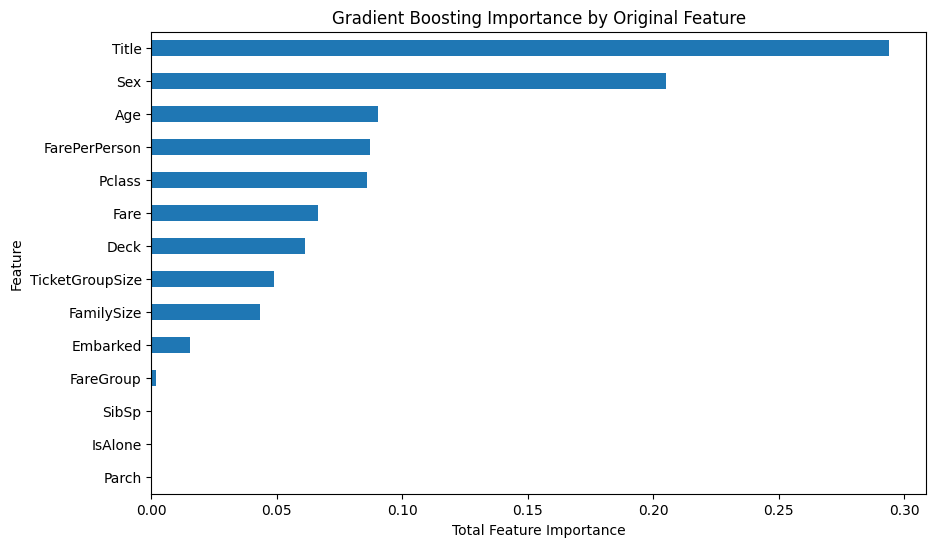

In [ ]:
plt.figure(figsize=(10, 6))

grouped_gradient_boosting_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel('Total Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Gradient Boosting Importance by Original Feature'
)

plt.show()

In [ ]:
final_model_comparison = (
    final_model_comparison
    .sort_values(
        by='ROC-AUC',
        ascending=False
    )
)

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.821229,0.803279,0.710145,0.753846,0.864163
2,Random Forest,0.787709,0.754098,0.666667,0.707692,0.835837
1,Decision Tree,0.782123,0.682927,0.811594,0.741722,0.835573
3,Gradient Boosting,0.815642,0.772727,0.739130,0.755556,0.828722


In [ ]:
cv_scores = {
    'Logistic Regression': 0.863525695829771,
    'Decision Tree': 0.8643412178208416,
    'Random Forest': 0.8822914093917229,
    'Gradient Boosting': 0.892200136157816
}

In [ ]:
stability_results = []

for model_name, cv_score in cv_scores.items():

    test_score = final_model_comparison.loc[
        final_model_comparison['Model'] == model_name,
        'ROC-AUC'
    ].iloc[0]

    stability_results.append({
        'Model': model_name,
        'CV_ROC_AUC': cv_score,
        'Test_ROC_AUC': test_score,
        'CV_Test_Difference':
            cv_score - test_score
    })

stability_comparison = pd.DataFrame(
    stability_results
)

stability_comparison.sort_values(
    by='CV_Test_Difference'
)

,Model,CV_ROC_AUC,Test_ROC_AUC,CV_Test_Difference
0,Logistic Regression,0.863526,0.864163,-0.000638
1,Decision Tree,0.864341,0.835573,0.028768
2,Random Forest,0.882291,0.835837,0.046455
3,Gradient Boosting,0.892200,0.828722,0.063478


🏆 Logistic Regression is currently the strongest final-model candidate.

Why?

1. Best test ROC-AUC
0.8642
2. Best test accuracy
0.8212

Actually, Gradient Boosting is close at 0.8156, but Logistic is still higher.

3. Highest test precision
0.8033
4. Very strong F1
0.7538
5. Extremely stable CV → test performance
0.8635 → 0.8642
6. Easier to interpret

We already interpreted its coefficients and odds ratios.

7. Simpler model

For a Titanic portfolio project, there is little benefit in choosing a considerably more complex model if it doesn't demonstrate better generalization

## Repeat Cross validation

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [ ]:
repeated_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
tuned_models = {
    'Logistic Regression':
        best_logistic_model,

    'Decision Tree':
        best_decision_tree_model,

    'Random Forest':
        best_random_forest_model,

    'Gradient Boosting':
        best_gradient_boosting_model
}

In [ ]:
repeated_cv_results = []

for model_name, model in tuned_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    repeated_cv_results.append({
        'Model': model_name,
        'Mean ROC-AUC': scores.mean(),
        'Std ROC-AUC': scores.std(),
        'Minimum ROC-AUC': scores.min(),
        'Maximum ROC-AUC': scores.max()
    })

repeated_cv_comparison = pd.DataFrame(
    repeated_cv_results
)

repeated_cv_comparison.sort_values(
    by='Mean ROC-AUC',
    ascending=False
)

,Model,Mean ROC-AUC,Std ROC-AUC,Minimum ROC-AUC,Maximum ROC-AUC
3,Gradient Boosting,0.898894,0.016770,0.873244,0.918495
2,Random Forest,0.891666,0.029671,0.854132,0.939603
0,Logistic Regression,0.865401,0.021945,0.842698,0.898537
1,Decision Tree,0.849163,0.017748,0.821074,0.873145


"Which model performs consistently well across different samples of the training data?"

In [ ]:
final_model_summary = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'Random Forest',
        'Logistic Regression',
        'Decision Tree'
    ],

    'Repeated CV ROC-AUC': [
        0.898894,
        0.891666,
        0.865401,
        0.849163
    ],

    'Test ROC-AUC': [
        0.828722,
        0.835837,
        0.864163,
        0.835573
    ],

    'Test Accuracy': [
        0.815642,
        0.787709,
        0.821229,
        0.782123
    ],

    'Test F1': [
        0.755556,
        0.707692,
        0.753846,
        0.741722
    ]
})

final_model_summary

,Model,Repeated CV ROC-AUC,Test ROC-AUC,Test Accuracy,Test F1
0,Gradient Boosting,0.898894,0.828722,0.815642,0.755556
1,Random Forest,0.891666,0.835837,0.787709,0.707692
2,Logistic Regression,0.865401,0.864163,0.821229,0.753846
3,Decision Tree,0.849163,0.835573,0.782123,0.741722


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold



In [ ]:
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score
)

In [ ]:
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

In [ ]:
true_repeated_cv_results = []

for model_name, model in tuned_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    true_repeated_cv_results.append({
        'Model': model_name,
        'Mean ROC-AUC': scores.mean(),
        'Std ROC-AUC': scores.std(),
        'Minimum ROC-AUC': scores.min(),
        'Maximum ROC-AUC': scores.max()
    })

true_repeated_cv_comparison = pd.DataFrame(
    true_repeated_cv_results
)

true_repeated_cv_comparison = (
    true_repeated_cv_comparison
    .sort_values(
        by='Mean ROC-AUC',
        ascending=False
    )
)

true_repeated_cv_comparison

,Model,Mean ROC-AUC,Std ROC-AUC,Minimum ROC-AUC,Maximum ROC-AUC
3,Gradient Boosting,0.896035,0.027782,0.823760,0.957748
2,Random Forest,0.887847,0.033757,0.793698,0.957645
0,Logistic Regression,0.864970,0.033202,0.775930,0.918245
1,Decision Tree,0.856063,0.032500,0.777996,0.930617


In [ ]:
final_model_summary.sort_values(
    by='Repeated CV ROC-AUC',
    ascending=False
)

,Model,Repeated CV ROC-AUC,Test ROC-AUC,Test Accuracy,Test F1
0,Gradient Boosting,0.898894,0.828722,0.815642,0.755556
1,Random Forest,0.891666,0.835837,0.787709,0.707692
2,Logistic Regression,0.865401,0.864163,0.821229,0.753846
3,Decision Tree,0.849163,0.835573,0.782123,0.741722


"I compared four models, used stratified cross-validation, tuned their hyperparameters, performed error analysis, interpreted the models, and selected the final model based on generalization, stability, and interpretability."



Logistic Regression was used as the interpretable baseline, while Gradient Boosting was selected as the final predictive model based on repeated cross-validation performance.

| Role            | Model                 | Reason                                   |
| --------------- | --------------------- | ---------------------------------------- |
| Baseline        | Logistic Regression   | Simple and interpretable                 |
| Alternative     | Decision Tree         | Non-linear model                         |
| Alternative     | Random Forest         | Ensemble model                           |
| Alternative     | Gradient Boosting     | Strong non-linear ensemble               |
| **Final model** | **Gradient Boosting** | **Highest repeated-CV ROC-AUC (0.8960)** |


🏆 Gradient Boosting is your final model.

Not because it has the highest score on one particular dataset split, but because it demonstrated the best average ROC-AUC across 5-fold × 10-repeat cross-validation.

# Final Model Selection and Saving

In [ ]:
# create the final model


final_model = best_gradient_boosting_model

In [ ]:
# fit the final model

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'Deck',
                                                   'FareGroup'])])),
                ('model',
                 GradientBoostingClassifier(max_depth=2, min_samples_split=5,
                                            n_estimators=200,
                                            random_state=42))])

## Final Model Selection

Logistic Regression was used as the interpretable baseline,
while Gradient Boosting was selected as the final predictive
model based on repeated cross-validation performance.

Gradient Boosting achieved the highest mean ROC-AUC across
5 folds repeated 10 times, with a mean ROC-AUC of approximately
0.896.

In [ ]:
# make final predictions

final_predictions = final_model.predict(
    X_test
)

In [ ]:
final_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

In [ ]:
print("Final Gradient Boosting Model")
print("-----------------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

Final Gradient Boosting Model
-----------------------------
Accuracy : 0.8156424581005587
Precision: 0.7727272727272727
Recall   : 0.7391304347826086
F1 Score : 0.7555555555555555
ROC-AUC  : 0.8287220026350461


## Save the complete pipeline

In [ ]:
pip install joblib

In [ ]:
import joblib


joblib.dump(
    final_model,
    'titanic_gradient_boosting_pipeline.pkl'
)

['titanic_gradient_boosting_pipeline.pkl']

In [ ]:
import os

os.path.exists(
    'titanic_gradient_boosting_pipeline.pkl'
)

True

In [ ]:
os.path.getsize(
    'titanic_gradient_boosting_pipeline.pkl'
)

157835

### load the saved pipeline

In [ ]:
# reload and verify

loaded_model = joblib.load(
    'titanic_gradient_boosting_pipeline.pkl'
)

## Create metadata file and save it

In [ ]:
# create the metadata

metadata = {
    'ticket_group_sizes': ticket_group_sizes,
    'fare_group_bins': fare_group_bins
}

In [ ]:
# save  it


joblib.dump(
    metadata,
    'titanic_metadata.pkl'
)

['titanic_metadata.pkl']

### make predictions using the loaded model

In [ ]:
loaded_predictions = loaded_model.predict(
    X_test
)

In [ ]:
loaded_probabilities = loaded_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
(final_predictions == loaded_predictions).all()

np.True_

### Compare predictions

In [ ]:
predictions_match = (
    final_predictions ==
    loaded_predictions
).all()

print(
    "Predictions match:",
    predictions_match
)

Predictions match: True


In [ ]:
probabilities_match = (
    final_probabilities ==
    loaded_probabilities
).all()

print(
    "Probabilities match:",
    probabilities_match
)

Probabilities match: True


In [ ]:
import numpy as np

probabilities_match = np.allclose(
    final_probabilities,
    loaded_probabilities
)

print(
    "Probabilities match:",
    probabilities_match
)

Probabilities match: True


In [ ]:
# check model type



print(
    type(loaded_model)
)

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
print(
    loaded_model
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone', 'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
       

In [ ]:
import numpy as np

loaded_model = joblib.load(
    'titanic_gradient_boosting_pipeline.pkl'
)

loaded_predictions = loaded_model.predict(
    X_test
)

loaded_probabilities = loaded_model.predict_proba(
    X_test
)[:, 1]

predictions_match = (
    final_predictions ==
    loaded_predictions
).all()

probabilities_match = np.allclose(
    final_probabilities,
    loaded_probabilities
)

print(
    "Predictions match:",
    predictions_match
)

print(
    "Probabilities match:",
    probabilities_match
)

Predictions match: True
Probabilities match: True


# Project Architecture

                 TITANIC ML PROJECT

EDA
 │
 ├── Data Cleaning
 ├── Feature Engineering
 ├── Preprocessing
 │
 ▼
Model Development
 │
 ├── Logistic Regression
 ├── Decision Tree
 ├── Random Forest
 └── Gradient Boosting 🏆
          │
          ▼
Hyperparameter Tuning
          │
          ▼
Error Analysis
          │
          ▼
Model Interpretation
          │
          ▼
Repeated Cross-Validation
          │
          ▼
🏆 Final Model Selection
          │
          ▼
Final Pipeline
          │
          ▼
Save .pkl
          │
          ▼
Reload & Verify
          │
          ▼
New Passenger Prediction
          │
          ▼
Streamlit Application
          │
          ▼
Deployment
          │
          ▼
GitHub README
          │
          ▼
Portfolio + Resume

## Prediction system

In [ ]:
import pandas as pd

def predict_passenger(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    title,
    deck,
    ticket_group_size
):

    family_size = sibsp + parch + 1

    is_alone = int(
        family_size == 1
    )

    fare_per_person = (
        fare / ticket_group_size
    )

    passenger = pd.DataFrame({
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'TicketGroupSize': [ticket_group_size],
        'FarePerPerson': [fare_per_person],
        'Pclass': [pclass],
        'Sex': [sex],
        'Embarked': [embarked],
        'Title': [title],
        'Deck': [deck],
        'FareGroup': [None]
    })

    passenger['FareGroup'] = pd.cut(
        passenger['FarePerPerson'],
        bins=[
            -float('inf'),
            dataframe['FarePerPerson'].quantile(0.25),
            dataframe['FarePerPerson'].quantile(0.50),
            dataframe['FarePerPerson'].quantile(0.75),
            float('inf')
        ],
        labels=[
            'Low',
            'Medium-Low',
            'Medium-High',
            'High'
        ]
    )

    prediction = loaded_model.predict(
        passenger
    )[0]

    probability = loaded_model.predict_proba(
        passenger
    )[0, 1]

    return prediction, probability

In [ ]:
prediction, probability = predict_passenger(
    pclass=3,
    sex='male',
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked='S',
    title='Mr',
    deck='Unknown',
    ticket_group_size=1
)

In [ ]:
print(
    "Prediction:",
    "Survived" if prediction == 1
    else "Did Not Survive"
)

print(
    "Survival Probability:",
    f"{probability:.2%}"
)

Prediction: Did Not Survive
Survival Probability: 6.97%


In [ ]:
prediction, probability = predict_passenger(
    pclass=1,
    sex='female',
    age=30,
    sibsp=0,
    parch=0,
    fare=100,
    embarked='S',
    title='Mrs',
    deck='B',
    ticket_group_size=1
)

In [ ]:
print(
    "Prediction:",
    "Survived" if prediction == 1
    else "Did Not Survive"
)

print(
    "Survival Probability:",
    f"{probability:.2%}"
)

Prediction: Survived
Survival Probability: 98.69%


## BUild proper new passenger prediction pipeline

In [ ]:
def create_passenger_features(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    name,
    cabin,
    ticket
):

    family_size = (
        sibsp +
        parch +
        1
    )

    is_alone = int(
        family_size == 1
    )

    title = name.split(',')[1].split('.')[0].strip()

    title = title.replace(
        'Mlle',
        'Miss'
    )

    title = title.replace(
        'Ms',
        'Miss'
    )

    title = title.replace(
        'Mme',
        'Mrs'
    )

    rare_titles = [
        'Lady',
        'Countess',
        'Capt',
        'Col',
        'Don',
        'Dr',
        'Major',
        'Rev',
        'Sir',
        'Jonkheer',
        'Dona'
    ]

    if title in rare_titles:
        title = 'Rare'

    if cabin is None:
        deck = 'Unknown'
    else:
        deck = cabin[0]

    if ticket is None or ticket == '':
        ticket_group_size = 1
    else:
        ticket_group_size = (
            dataframe['Ticket']
            .value_counts()
            .get(
                ticket,
                1
            )
        )

    fare_per_person = (
        fare /
        ticket_group_size
    )

    passenger = pd.DataFrame({
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'TicketGroupSize': [ticket_group_size],
        'FarePerPerson': [fare_per_person],
        'Pclass': [pclass],
        'Sex': [sex],
        'Embarked': [embarked],
        'Title': [title],
        'Deck': [deck]
    })

    return passenger

In [ ]:
def assign_fare_group(
    fare_per_person
):

    q1 = dataframe[
        'FarePerPerson'
    ].quantile(0.25)

    q2 = dataframe[
        'FarePerPerson'
    ].quantile(0.50)

    q3 = dataframe[
        'FarePerPerson'
    ].quantile(0.75)

    if fare_per_person <= q1:
        return 'Low'

    elif fare_per_person <= q2:
        return 'Medium-Low'

    elif fare_per_person <= q3:
        return 'Medium-High'

    else:
        return 'High'

In [ ]:
def create_passenger_features(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    name,
    cabin,
    ticket
):

    family_size = (
        sibsp +
        parch +
        1
    )

    is_alone = int(
        family_size == 1
    )

    title = name.split(',')[1].split('.')[0].strip()

    title = title.replace(
        'Mlle',
        'Miss'
    )

    title = title.replace(
        'Ms',
        'Miss'
    )

    title = title.replace(
        'Mme',
        'Mrs'
    )

    rare_titles = [
        'Lady',
        'Countess',
        'Capt',
        'Col',
        'Don',
        'Dr',
        'Major',
        'Rev',
        'Sir',
        'Jonkheer',
        'Dona'
    ]

    if title in rare_titles:
        title = 'Rare'

    deck = (
        cabin[0]
        if cabin
        else 'Unknown'
    )

    ticket_group_size = (
        dataframe['Ticket']
        .value_counts()
        .get(
            ticket,
            1
        )
    )

    fare_per_person = (
        fare /
        ticket_group_size
    )

    fare_group = assign_fare_group(
        fare_per_person
    )

    passenger = pd.DataFrame({
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'TicketGroupSize': [ticket_group_size],
        'FarePerPerson': [fare_per_person],
        'Pclass': [pclass],
        'Sex': [sex],
        'Embarked': [embarked],
        'Title': [title],
        'Deck': [deck],
        'FareGroup': [fare_group]
    })

    return passenger

In [ ]:
new_passenger = create_passenger_features(
    pclass=3,
    sex='male',
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked='S',
    name='Smith, Mr. John',
    cabin=None,
    ticket='A/5 21171'
)

In [ ]:
new_passenger

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup
0,25,0,0,7.25,1,1,1,7.25,3,male,S,Mr,Unknown,Low


In [ ]:
# connect to your saved model


def predict_titanic_survival(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    name,
    cabin,
    ticket
):

    passenger = create_passenger_features(
        pclass=pclass,
        sex=sex,
        age=age,
        sibsp=sibsp,
        parch=parch,
        fare=fare,
        embarked=embarked,
        name=name,
        cabin=cabin,
        ticket=ticket
    )

    prediction = loaded_model.predict(
        passenger
    )[0]

    probability = loaded_model.predict_proba(
        passenger
    )[0, 1]

    return prediction, probability

In [ ]:
# test the complete system


prediction, probability = predict_titanic_survival(
    pclass=3,
    sex='male',
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked='S',
    name='Smith, Mr. John',
    cabin=None,
    ticket='A/5 21171'
)

In [ ]:
print(
    "Prediction:",
    "Survived"
    if prediction == 1
    else "Did Not Survive"
)

print(
    "Survival Probability:",
    f"{probability:.2%}"
)

Prediction: Did Not Survive
Survival Probability: 6.97%


In [ ]:
fare_group_bins = [
    -float('inf'),
    dataframe['FarePerPerson'].quantile(0.25),
    dataframe['FarePerPerson'].quantile(0.50),
    dataframe['FarePerPerson'].quantile(0.75),
    float('inf')
]

fare_group_labels = [
    'Low',
    'Medium-Low',
    'Medium-High',
    'High'
]

In [ ]:
print(
    "FareGroup bins:",
    fare_group_bins
)

FareGroup bins: [-inf, np.float64(7.7625), np.float64(8.85), np.float64(24.288200000000003), inf]


In [ ]:
# create a standalone faregroup function


def assign_fare_group(
    fare_per_person
):

    if fare_per_person <= fare_group_bins[1]:

        return 'Low'

    elif fare_per_person <= fare_group_bins[2]:

        return 'Medium-Low'

    elif fare_per_person <= fare_group_bins[3]:

        return 'Medium-High'

    else:

        return 'High'

In [ ]:
# handling ticket- group handling


ticket_group_sizes = (
    dataframe['Ticket']
    .value_counts()
    .to_dict()
)

In [ ]:
ticket_group_sizes.get(
    '347082',
    1
)

7

In [ ]:
# for an unknown ticket

ticket_group_sizes.get(
    'NEW_TICKET',
    1
)

1

In [ ]:
def create_passenger_features(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    name,
    cabin,
    ticket
):

    family_size = (
        sibsp +
        parch +
        1
    )

    is_alone = int(
        family_size == 1
    )

    title = (
        name
        .split(',')[1]
        .split('.')[0]
        .strip()
    )

    title_mapping = {
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs'
    }

    title = title_mapping.get(
        title,
        title
    )

    rare_titles = [
        'Lady',
        'Countess',
        'Capt',
        'Col',
        'Don',
        'Dr',
        'Major',
        'Rev',
        'Sir',
        'Jonkheer',
        'Dona'
    ]

    if title in rare_titles:

        title = 'Rare'

    deck = (
        cabin[0]
        if cabin
        else 'Unknown'
    )

    ticket_group_size = (
        ticket_group_sizes.get(
            ticket,
            1
        )
    )

    fare_per_person = (
        fare /
        ticket_group_size
    )

    fare_group = assign_fare_group(
        fare_per_person
    )

    passenger = pd.DataFrame({

        'Age': [age],

        'SibSp': [sibsp],

        'Parch': [parch],

        'Fare': [fare],

        'FamilySize': [
            family_size
        ],

        'IsAlone': [
            is_alone
        ],

        'TicketGroupSize': [
            ticket_group_size
        ],

        'FarePerPerson': [
            fare_per_person
        ],

        'Pclass': [pclass],

        'Sex': [sex],

        'Embarked': [embarked],

        'Title': [title],

        'Deck': [deck],

        'FareGroup': [
            fare_group
        ]
    })

    return passenger

In [ ]:
new_passenger = create_passenger_features(
    pclass=3,
    sex='male',
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked='S',
    name='Smith, Mr. John',
    cabin=None,
    ticket='A/5 21171'
)

In [ ]:
new_passenger

,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Pclass,Sex,Embarked,Title,Deck,FareGroup
0,25,0,0,7.25,1,1,1,7.25,3,male,S,Mr,Unknown,Low


In [ ]:
# connect it to the saved model


def predict_titanic_survival(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    name,
    cabin,
    ticket
):

    passenger = create_passenger_features(
        pclass=pclass,
        sex=sex,
        age=age,
        sibsp=sibsp,
        parch=parch,
        fare=fare,
        embarked=embarked,
        name=name,
        cabin=cabin,
        ticket=ticket
    )

    prediction = loaded_model.predict(
        passenger
    )[0]

    probability = loaded_model.predict_proba(
        passenger
    )[0, 1]

    return prediction, probability

In [ ]:
prediction, probability = predict_titanic_survival(
    pclass=3,
    sex='male',
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked='S',
    name='Smith, Mr. John',
    cabin=None,
    ticket='A/5 21171'
)

In [ ]:
print(
    "Prediction:",
    "Survived"
    if prediction == 1
    else "Did Not Survive"
)

print(
    "Survival Probability:",
    f"{probability:.2%}"
)

Prediction: Did Not Survive
Survival Probability: 6.97%


In [ ]:
prediction, probability = predict_titanic_survival(
    pclass=1,
    sex='female',
    age=30,
    sibsp=0,
    parch=0,
    fare=100,
    embarked='S',
    name='Johnson, Mrs. Anna',
    cabin='B20',
    ticket='NEW123'
)

In [ ]:
print(
    "Prediction:",
    "Survived"
    if prediction == 1
    else "Did Not Survive"
)

print(
    "Survival Probability:",
    f"{probability:.2%}"
)

Prediction: Survived
Survival Probability: 98.69%


                 USER
                  │
                  ▼
           Streamlit Inputs
                  │
                  ▼
           Input Validation
                  │
          ┌───────┴───────┐
          │               │
       Invalid           Valid
          │               │
          ▼               ▼
     Show Errors     Feature Engineering
                          │
                          ▼
                    Preprocessing
                          │
                          ▼
                 Gradient Boosting
                          │
                          ▼
                    Prediction
                          │
                          ▼
                Survival Probability

# Limitation

## Limitations

- The dataset is relatively small.
- The model is trained only on historical Titanic data.
- Some cabin information is missing.
- Ticket-based features depend on information available
  in the training dataset.
- FareGroup was created using FarePerPerson quantiles.
- The current prediction application is intended for
  educational and demonstration purposes.
- The model should not be interpreted as a real-world
  survival predictor.